In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

!ls "/content/drive/MyDrive/Colab Notebooks"

N-Caltech101-full-split.zip  Synthetic_DVS-full-split.zip  Untitled0.ipynb


In [ ]:
from google.colab import files
import zipfile
import os

# 2. Zakładamy, że plik wgrywa się o dokładnej nazwie:
zip_path = "/content/drive/MyDrive/Colab Notebooks/Synthetic_DVS-full-split.zip"

# 3. Tworzymy folder, w którym rozpakujemy ZIP
extract_dir = "/content/Synthetic_DVS-full-split"
os.makedirs(extract_dir, exist_ok=True)

# 4. Rozpakowujemy ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [ ]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 5.7 MB/s eta 0:00:00


In [ ]:
ls /content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/

test/  train/


Kod dla danych syntetycznych

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py

In [ ]:
def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240,
                 clip_value=5.0, augment=False): # Dodano augment do init
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W
        self.clip_value = clip_value
        self.augment = augment # Zapisujemy augment

        self.samples = []
        for cls in classes:
            # Upewnij się, że katalog klasy istnieje
            class_dir = self.root_dir / cls
            if not class_dir.exists():
                print(f"Ostrzeżenie: Katalog klasy {class_dir} nie istnieje. Pomijam.")
                continue
            for f in class_dir.glob("*.h5"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_h5_events(path)

        if len(t) == 0:
            # Zwróć tensor zer o odpowiednim kształcie i etykietę
            return torch.zeros((2, self.H, self.W, self.T)), torch.tensor(label, dtype=torch.long)

        # Augmentacja: Horyzontalny Flip (tylko jeśli augment jest True)
        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        t = (t - t.min()) / (t.max() - t.min() + 1e-9) # Normalizacja czasu
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

NameError: name 'Dataset' is not defined

In [ ]:
class SimpleSNN(nn.Module):
    def __init__(self, num_classes=101, T=10):
        super().__init__()
        self.T = T

        beta = 0.95
        spike_grad = surrogate.fast_sigmoid()

        # Block 1
        self.conv1 = nn.Conv2d(2, 16, 3, padding=1)
        self.lif1  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.conv2 = nn.Conv2d(16, 16, 3, padding=1)
        self.lif2  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool1 = nn.AvgPool2d(2)

        # Block 2
        self.conv3 = nn.Conv2d(16, 32, 3, padding=1)
        self.lif3  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.conv4 = nn.Conv2d(32, 32, 3, padding=1)
        self.lif4  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool2 = nn.AvgPool2d(2)

        # Block 3
        self.conv5 = nn.Conv2d(32, 64, 3, padding=1)
        self.lif5  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.conv6 = nn.Conv2d(64, 64, 3, padding=1)
        self.lif6  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool3 = nn.AvgPool2d(2)

        # Block 4 (extra depth)
        self.conv7 = nn.Conv2d(64, 128, 3, padding=1)
        self.lif7  = snn.Leaky(beta=beta, spike_grad=spike_grad)

        # Flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x, _ = self.lif1(self.conv1(dummy), self.lif1.init_leaky())
            x, _ = self.lif2(self.conv2(x), self.lif2.init_leaky())
            x = self.pool1(x)

            x, _ = self.lif3(self.conv3(x), self.lif3.init_leaky())
            x, _ = self.lif4(self.conv4(x), self.lif4.init_leaky())
            x = self.pool2(x)

            x, _ = self.lif5(self.conv5(x), self.lif5.init_leaky())
            x, _ = self.lif6(self.conv6(x), self.lif6.init_leaky())
            x = self.pool3(x)

            x, _ = self.lif7(self.conv7(x), self.lif7.init_leaky())
            self.flat_dim = x.numel()

        self.fc = nn.Linear(self.flat_dim, num_classes)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        mem5 = self.lif5.init_leaky()
        mem6 = self.lif6.init_leaky()
        mem7 = self.lif7.init_leaky()

        out_sum = 0

        for t in range(self.T):
            xt = x[..., t]

            spk, mem1 = self.lif1(self.conv1(xt), mem1)
            spk, mem2 = self.lif2(self.conv2(spk), mem2)
            spk = self.pool1(spk)

            spk, mem3 = self.lif3(self.conv3(spk), mem3)
            spk, mem4 = self.lif4(self.conv4(spk), mem4)
            spk = self.pool2(spk)

            spk, mem5 = self.lif5(self.conv5(spk), mem5)
            spk, mem6 = self.lif6(self.conv6(spk), mem6)
            spk = self.pool3(spk)

            spk, mem7 = self.lif7(self.conv7(spk), mem7)

            out_sum += self.fc(spk.flatten(1))

            if t % 5 == 0:
                mem1 = mem1.detach()
                mem2 = mem2.detach()
                mem3 = mem3.detach()
                mem4 = mem4.detach()
                mem5 = mem5.detach()
                mem6 = mem6.detach()
                mem7 = mem7.detach()

        return out_sum / self.T


NameError: name 'nn' is not defined

In [ ]:
def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []
    spike_rates = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out  = model(x)
            #sum_spk = spk.sum(dim=0)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            rate_per_sample_class = out
            spike_rates.append(rate_per_sample_class.cpu())

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    # Sprawdzamy czy k=5 jest mniejsze lub równe liczbie klas, aby uniknąć błędu
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    spike_rates = torch.cat(spike_rates) # Concatenujemy tensory z częstościami

    return (
        val_loss,
        val_acc,
        top1,
        top5,
        all_labels,
        all_probs,
        spike_rates
    )

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
TRAIN_ROOT = "/content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/train"
TEST_ROOT  = "/content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/test"
SAVE_DIR   = Path("/content/results")
SAVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"


CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)
print(f"Liczba klas: {NUM_CLASSES}")
print(f"Wykryte klasy: {CLASSES}")

train_ds = EventDatasetH5(TRAIN_ROOT, CLASSES, augment=True)
test_ds  = EventDatasetH5(TEST_ROOT, CLASSES, augment=False)

labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1 / counts[l] for l in labels]

sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler, num_workers = 2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=64, num_workers = 2, pin_memory=True)

model = SimpleSNN(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler(
    enabled=(device.type == "cuda")
)

criterion = nn.CrossEntropyLoss()

cuda
Liczba klas: 101
Wykryte klasy: ['BACKGROUND_Google', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion

In [ ]:
EPOCHS = 10

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}
best_val_acc = 0.0
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1 # Wznawiamy od następnej epoki

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch - 1 if start_epoch > 0 else 0}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top-1:     {last_top1*100:.2f}%")
    print(f"Top-5:     {last_top5*100:.2f}%")

    print(f"➡️ Wznawiam od epoki {start_epoch}")
else:
    print("🆕 Brak checkpointu – start od zera")

print(f"Dane: Trening ({len(train_ds)}), Test ({len(test_ds)})")
print(f"Rozpoczynam trening. Wyniki w: {SAVE_DIR.absolute()}")

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)


        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            spk = model(x)
            #sum_spk = spk.sum(dim=0)
            loss = criterion(spk, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = spk.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    (
        val_loss,
        val_acc,
        top1,
        top5,
        labels,
        probs,
        spike_rates
    ) = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )

    history["epoch"].append(epoch+1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)
    avg_spike_rate = spike_rates.mean().item()
    history["spike_rate"].append(avg_spike_rate)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.3f}%, "
        f"Val Acc={val_acc*100:.3f}%, "
        f"Top1={top1*100:.3f}%, "
        f"Top5={top5*100:.3f}%"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )


🆕 Brak checkpointu – start od zera
Dane: Trening (6932), Test (1777)
Rozpoczynam trening. Wyniki w: /content/results


Epoch 1: 100%|██████████| 109/109 [17:24<00:00,  9.58s/it]


Epoch 1: Train Acc=1.111%, Val Acc=0.675%, Top1=0.675%, Top5=3.827%


Epoch 2: 100%|██████████| 109/109 [17:27<00:00,  9.61s/it]


Epoch 2: Train Acc=1.096%, Val Acc=1.407%, Top1=1.407%, Top5=3.714%


...

Epoch 3: Train Acc=1.068%, Val Acc=1.407%, Top1=1.407%, Top5=3.995%


Epoch 4: 100%|██████████| 109/109 [17:42<00:00,  9.75s/it]


Epoch 4: Train Acc=0.866%, Val Acc=0.675%, Top1=0.675%, Top5=3.883%


Epoch 5:   0%|          | 0/109 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
pd.DataFrame(history).to_csv(
    SAVE_DIR / "training_history.csv",
    index=False
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig(SAVE_DIR / "learning_curves.png", dpi=300)
plt.close()

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    cbar=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"N-Caltech101 | Top-1 Acc = {history['top1'][-1]*100:.2f}%")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(SAVE_DIR / "confusion_matrix.png", dpi=300)
plt.close()

NameError: name 'preds' is not defined

In [ ]:
preds = np.argmax(probs, axis=1)
report = classification_report(
    labels,
    preds,
    target_names=CLASSES,
    digits=2
)

header = (
    f"Eksperyment: {experiment_time}\n"
    f"Zbiór: Trening={n_train}, Test={n_test}\n"
    f"{'-'*30}\n"
)

with open(SAVE_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(header)
    f.write(report)


Kod dla sieci ze zwykłymi danymi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
import zipfile
import os

# 2. Zakładamy, że plik wgrywa się o dokładnej nazwie:
zip_path = "/content/drive/MyDrive/N-Caltech101-full-split.zip"

# 3. Tworzymy folder, w którym rozpakujemy ZIP
extract_dir = "/content/N-Caltech101-full-split"
os.makedirs(extract_dir, exist_ok=True)

# 4. Rozpakowujemy ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [ ]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 6.7 MB/s eta 0:00:00


In [ ]:
ls /content/N-Caltech101-full-split/

N-Caltech101-full-split/


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py

In [ ]:
def load_bin_events(path):
  raw = np.fromfile(path, dtype=np.uint8)
  raw = raw[:len(raw) // 5 * 5]
  x = raw[0::5].astype(np.int32)
  y = raw[1::5].astype(np.int32)
  p = (raw[2::5] >> 7) & 1
  p = np.where(p == 1, 1, -1)

  t_high = (raw[2::5] & 0x7F).astype(np.uint32)
  t_mid  = raw[3::5].astype(np.uint32)
  t_low  = raw[4::5].astype(np.uint32)
  t = (t_high << 16) | (t_mid << 8) | t_low

  return x, y, t.astype(np.float32), p

class EventDatasetBIN(Dataset):
  def __init__(self, root_dir, classes, T=15, H=180, W=240, clip_value=5.0, augment=False):
    self.root_dir = Path(root_dir)
    self.classes = classes
    self.class_to_idx = {c: i for i, c in enumerate(classes)}
    self.T, self.H, self.W = T, H, W
    self.clip_value = clip_value
    self.augment = augment

    self.samples = []
    for cls in classes:
        for f in (self.root_dir / cls).glob("*.bin"):
            self.samples.append((f, self.class_to_idx[cls]))

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
      path, label = self.samples[idx]
      x, y, t, p = load_bin_events(path)

      if self.augment and np.random.rand() > 0.5:
          x = (self.W - 1) - x

      t = (t - t.min()) / (t.max() - t.min() + 1e-9)
      voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
      time_bins = (t * (self.T - 1)).astype(np.int32)

      for xi, yi, pi, bi in zip(x, y, p, time_bins):
          if 0 <= xi < self.W and 0 <= yi < self.H:
              ch = 0 if pi > 0 else 1
              voxels[ch, yi, xi, bi] += 1.0

      voxels = np.clip(voxels, 0.0, self.clip_value)
      voxels /= self.clip_value

      return torch.from_numpy(voxels), torch.tensor(label)

In [ ]:
class SimpleSNN(nn.Module): # Zmieniono nazwę klasy
    def __init__(self, num_classes=101, T=15):
        super().__init__()
        self.T = T
        spike_grad = surrogate.fast_sigmoid()

        self.beta = 0.9

        # Zmniejszone liczby filtrów w warstwach konwolucyjnych
        self.conv1 = nn.Conv2d(2, 8, 3, padding=1) # Zmieniono z 16 na 8
        self.bn1   = nn.BatchNorm2d(8) # Dostosuj BatchNorm
        self.lif1  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0)
        self.dropout1 = nn.Dropout2d(p=0.2) # Nadal p=0.4

        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(8, 16, 3, padding=1) # Zmieniono z 16 na 8, z 32 na 16
        self.bn2   = nn.BatchNorm2d(16) # Dostosuj BatchNorm
        self.lif2  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0)
        self.dropout2 = nn.Dropout2d(p=0.2) # Nadal p=0.4
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(16, 32, 3, padding=1) # Zmieniono z 32 na 16, z 64 na 32
        self.bn3   = nn.BatchNorm2d(32) # Dostosuj BatchNorm
        self.lif3  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0)
        self.dropout3 = nn.Dropout2d(p=0.2) # Nadal p=0.4

        self.conv4 = nn.Conv2d(32, 64, 3, padding=1) # Zmieniono z 64 na 32, z 128 na 64
        self.bn4   = nn.BatchNorm2d(64) # Dostosuj BatchNorm
        self.lif4  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0)
        self.dropout4 = nn.Dropout2d(p=0.2) # Nadal p=0.4

        self.conv5 = nn.Conv2d(64, 64, 3, padding=1) # Zmieniono z 128 na 64, z 128 na 64
        self.bn5   = nn.BatchNorm2d(64) # Dostosuj BatchNorm
        self.lif5  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0)
        # Opcjonalnie: self.dropout5 = nn.Dropout2d(p=0.4) dla ostatniej warstwy

        # Flatten + FC - trzeba też dostosować dummy input dla płaskiej warstwy
        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x_test = dummy
            x_test = self.bn1(self.conv1(x_test))
            x_test, _ = self.lif1(x_test, self.lif1.init_leaky())
            x_test = self.dropout1(x_test)
            x_test = self.pool1(x_test)

            x_test = self.bn2(self.conv2(x_test))
            x_test, _ = self.lif2(x_test, self.lif2.init_leaky())
            x_test = self.dropout2(x_test)
            x_test = self.pool2(x_test)

            x_test = self.bn3(self.conv3(x_test))
            x_test, _ = self.lif3(x_test, self.lif3.init_leaky())
            x_test = self.dropout3(x_test)

            x_test = self.bn4(self.conv4(x_test))
            x_test, _ = self.lif4(x_test, self.lif4.init_leaky())
            x_test = self.dropout4(x_test)

            x_test = self.bn5(self.conv5(x_test))
            x_test, _ = self.lif5(x_test, self.lif5.init_leaky())

            self.flat_dim = x_test.numel() # Automatycznie przeliczone

        self.fc = nn.Linear(self.flat_dim, num_classes)

    def forward(self, x):
        mems = [self.lif1.init_leaky(), self.lif2.init_leaky(), self.lif3.init_leaky(),
                self.lif4.init_leaky(), self.lif5.init_leaky()]

        spike_sums = [0.0] * 5 # Suma spikowań dla każdej warstwy

        # Liczba neuronów w każdej warstwie (dla obliczenia częstości spikowania na neuron)
        # WAŻNE: PRZELICZONE DLA NOWEJ ARCHITEKTURY
        num_neurons_lif1 = 8 * 180 * 240
        num_neurons_lif2 = 16 * 90 * 120
        num_neurons_lif3 = 32 * 45 * 60
        num_neurons_lif4 = 64 * 45 * 60
        num_neurons_lif5 = 64 * 45 * 60
        neurons_per_layer = [num_neurons_lif1, num_neurons_lif2, num_neurons_lif3, num_neurons_lif4, num_neurons_lif5]

        out_sum = 0

        for t in range(self.T):
            xt = x[..., t]

            # Warstwa 1
            cur1 = self.bn1(self.conv1(xt))
            spk1, mems[0] = self.lif1(cur1, mems[0])
            spike_sums[0] += spk1.sum().item() # Suma przed dropoutem
            spk1_dropped = self.dropout1(spk1) # Zastosuj dropout na spikach
            out1 = self.pool1(spk1_dropped) # Pooling na spikach po dropoutcie

            # Warstwa 2
            cur2 = self.bn2(self.conv2(out1))
            spk2, mems[1] = self.lif2(cur2, mems[1])
            spike_sums[1] += spk2.sum().item()
            spk2_dropped = self.dropout2(spk2) # Zastosuj dropout na spikach
            out2 = self.pool2(spk2_dropped)

            # Warstwy 3, 4, 5
            cur3 = self.bn3(self.conv3(out2))
            spk3, mems[2] = self.lif3(cur3, mems[2])
            spike_sums[2] += spk3.sum().item()
            spk3_dropped = self.dropout3(spk3) # Zastosuj dropout na spikach

            cur4 = self.bn4(self.conv4(spk3_dropped)) # Wejście do kolejnej warstwy to spiki po dropoutcie
            spk4, mems[3] = self.lif4(cur4, mems[3])
            spike_sums[3] += spk4.sum().item()
            spk4_dropped = self.dropout4(spk4) # Zastosuj dropout na spikach

            cur5 = self.bn5(self.conv5(spk4_dropped)) # Wejście do kolejnej warstwy to spiki po dropoutcie
            spk5, mems[4] = self.lif5(cur5, mems[4])
            # Jeśli dropout5 istnieje, zastosuj go tutaj: spk5_dropped = self.dropout5(spk5)
            spike_sums[4] += spk5.sum().item()

            # Wyjście
            out_sum += self.fc(spk5.flatten(1)) # Wyjście z spk5 (nie z spk5_dropped jeśli ostatnia warstwa bez dropoutu)

            if t % 5 == 0:
                mems = [m.detach() for m in mems]

        avg_firing_rates = [s / (self.T * x.size(0) * neurons_per_layer[i]) for i, s in enumerate(spike_sums)]

        return out_sum / self.T, avg_firing_rates

In [ ]:
def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []
    spike_rates_output_layer = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out, _ = model(x)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            rate_per_sample_class = out
            spike_rates_output_layer.append(rate_per_sample_class.cpu())

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    spike_rates_output_layer = torch.cat(spike_rates_output_layer)

    return (
        val_loss,
        val_acc,
        top1,
        top5,
        all_labels,
        all_probs,
        spike_rates_output_layer
    )


In [ ]:
# Usunąć scheduler po zakończeniu operacji na 5 warstwowej sieci

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

TRAIN_ROOT = "/content/N-Caltech101-full-split/N-Caltech101-full-split/train"
TEST_ROOT  = "/content/N-Caltech101-full-split/N-Caltech101-full-split/test"
SAVE_DIR   = Path("/content/results")
SAVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)
print(NUM_CLASSES)
train_ds = EventDatasetBIN(TRAIN_ROOT, CLASSES, augment=True)
test_ds  = EventDatasetBIN(TEST_ROOT, CLASSES)
labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1 / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler, num_workers = 2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=16, num_workers = 2, pin_memory=True)

# Inicjalizacja modelu bez globalnego parametru threshold
model = SimpleSNN(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scaler = torch.amp.GradScaler(
  enabled=(device.type == "cuda")
  )

criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

cuda
101


In [ ]:
EPOCHS = 20

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}
best_val_acc = 0.0
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch if start_epoch > 0 else 0}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top-1:     {last_top1*100:.2f}%")
    print(f"Top-5:     {last_top5*100:.2f}%")

    print(f"➡️ Wznawiam od epoki {start_epoch}")
else:
    print("🆕 Brak checkpointu – start od zera")

print(f"Dane: Trening ({len(train_ds)}), Test ({len(test_ds)})")
print(f"Rozpoczynam trening. Wyniki w: {SAVE_DIR.absolute()}")

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    _batch_idx_ = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            spk_out, spike_sums_per_layer = model(x)
            loss = criterion(spk_out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = spk_out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        if _batch_idx_ == 0:
            print(f"\nDEBUG (Epoka {epoch+1}, Partia {_batch_idx_}): Średnia liczba spikowań na krok czasowy i warstwę LIF:")
            for i, avg_spikes in enumerate(spike_sums_per_layer):
                print(f"  LIF{i+1}: {avg_spikes:.4f}")
        _batch_idx_ += 1


    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    (
        val_loss,
        val_acc,
        top1,
        top5,
        labels,
        probs,
        spike_rates_output_layer
    ) = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )
    scheduler.step(val_acc)

    history["epoch"].append(epoch+1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)

    avg_spike_rate_output_layer = spike_rates_output_layer.mean().item()
    history["spike_rate"].append(avg_spike_rate_output_layer)


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.3f}%, "
        f"Val Acc={val_acc*100:.3f}%, "
        f"Top1={top1*100:.3f}%, "
        f"Top5={top5*100:.3f}%, "
        f"Avg Spike Rate (output)={avg_spike_rate_output_layer:.4f}"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )

🔁 Wczytuję checkpoint...
🔁 Wczytano checkpoint z epoki 12
Train Acc: 95.93%
Val Acc:   43.89%
Top-1:     43.89%
Top-5:     60.66%
➡️ Wznawiam od epoki 12
Dane: Trening (6932), Test (1777)
Rozpoczynam trening. Wyniki w: /content/results


Epoch 13:   0%|          | 1/434 [00:04<35:22,  4.90s/it]


DEBUG (Epoka 13, Partia 0): Średnia liczba spikowań na krok czasowy i warstwę LIF:
  LIF1: 0.0172
  LIF2: 0.0164
  LIF3: 0.0350
  LIF4: 0.0482
  LIF5: 0.0582


Epoch 13: 100%|██████████| 434/434 [18:20<00:00,  2.54s/it]


Epoch 13: Train Acc=95.384%, Val Acc=44.119%, Top1=44.119%, Top5=62.127%, Avg Spike Rate (output)=-31.6745


...

Epoch 14: Train Acc=95.658%, Val Acc=44.007%, Top1=44.007%, Top5=60.945%, Avg Spike Rate (output)=-25.7306


Epoch 15:   0%|          | 1/434 [00:06<45:09,  6.26s/it]


DEBUG (Epoka 15, Partia 0): Średnia liczba spikowań na krok czasowy i warstwę LIF:
  LIF1: 0.0121
  LIF2: 0.0115
  LIF3: 0.0292
  LIF4: 0.0444
  LIF5: 0.0573


Epoch 15:   7%|▋         | 32/434 [01:27<18:19,  2.74s/it]


KeyboardInterrupt: 

In [ ]:
pd.DataFrame(history).to_csv(
    SAVE_DIR / "training_history.csv",
    index=False
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig(SAVE_DIR / "learning_curves.png", dpi=300)
plt.close()

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    cbar=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"N-Caltech101 | Top-1 Acc = {history['top1'][-1]*100:.2f}%")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(SAVE_DIR / "confusion_matrix.png", dpi=300)
plt.close()

In [ ]:
preds = np.argmax(probs, axis=1)
report = classification_report(
    labels,
    preds,
    target_names=CLASSES,
    digits=2
)

header = (
    f"Eksperyment: {experiment_time}\n"
    f"Zbiór: Trening={n_train}, Test={n_test}\n"
    f"{'-'*30}\n"
)

with open(SAVE_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(header)
    f.write(report)


✅ Checkpoint wczytany
Epoka: 10
Najlepsze Val Acc: 5.40%

📊 Ostatnie metryki:
Train Acc: 0.84%
Val Acc:   5.29%
Top-1:     0.68%
Top-5:     2.87%
Spike rate:0.0000


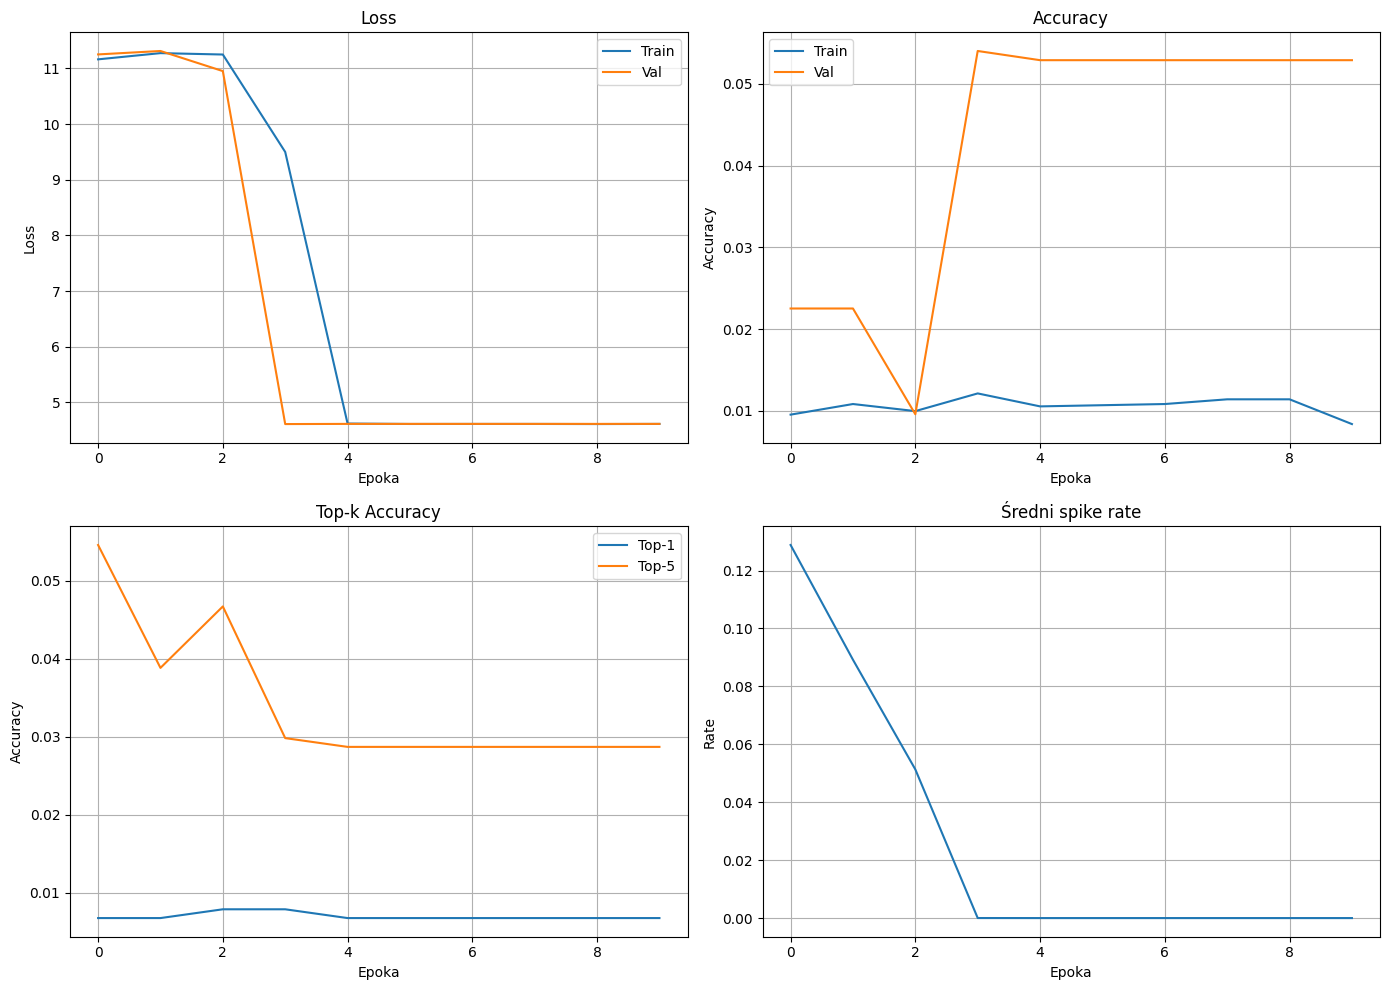

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# ŚCIEŻKI
# =========================
CHECKPOINT_PATH = Path("/content/results/checkpoint.pth")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# WCZYTANIE CHECKPOINTU
# =========================
assert CHECKPOINT_PATH.exists(), "❌ Nie znaleziono checkpointu"

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

history = checkpoint["history"]
last_epoch = checkpoint["epoch"] + 1
best_val_acc = checkpoint["best_val_acc"]

print("✅ Checkpoint wczytany")
print(f"Epoka: {last_epoch}")
print(f"Najlepsze Val Acc: {best_val_acc*100:.2f}%")

print("\n📊 Ostatnie metryki:")
print(f"Train Acc: {history['train_acc'][-1]*100:.2f}%")
print(f"Val Acc:   {history['val_acc'][-1]*100:.2f}%")
print(f"Top-1:     {history['top1'][-1]*100:.2f}%")
print(f"Top-5:     {history['top5'][-1]*100:.2f}%")
print(f"Spike rate:{history['spike_rate'][-1]:.4f}")

# =========================
# DATAFRAME
# =========================
df = pd.DataFrame(history)

# =========================
# WYKRESY
# =========================
plt.figure(figsize=(14,10))

# ---- LOSS ----
plt.subplot(2,2,1)
plt.plot(df["train_loss"], label="Train")
plt.plot(df["val_loss"], label="Val")
plt.title("Loss")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# ---- ACCURACY ----
plt.subplot(2,2,2)
plt.plot(df["train_acc"], label="Train")
plt.plot(df["val_acc"], label="Val")
plt.title("Accuracy")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# ---- TOP-1 / TOP-5 ----
plt.subplot(2,2,3)
plt.plot(df["top1"], label="Top-1")
plt.plot(df["top5"], label="Top-5")
plt.title("Top-k Accuracy")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# ---- SPIKE RATE ----
plt.subplot(2,2,4)
plt.plot(df["spike_rate"], label="Spike rate")
plt.title("Średni spike rate")
plt.xlabel("Epoka")
plt.ylabel("Rate")
plt.grid()

plt.tight_layout()
plt.show()


Modele do testu uczenia

In [ ]:
class SimpleSNN(nn.Module):
    def __init__(self, num_classes=5, T=10): # num_classes=5 domyślnie, ale zostanie nadpisane przez len(CLASSES)
        super().__init__()
        self.T = T
        beta = 0.9
        spike_grad = surrogate.fast_sigmoid()

        self.conv1 = nn.Conv2d(2, 16, 3, stride=2, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x = self.lif1(self.conv1(dummy))[0]
            x = self.lif2(self.conv2(x))[0]
            self.flat_dim = x.numel()

        self.fc = nn.Linear(self.flat_dim, num_classes)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem_out = self.lif_out.init_leaky()

        spk_rec = []
        for t in range(self.T):
            xt = x[..., t]

            spk1, mem1 = self.lif1(self.conv1(xt), mem1)
            spk2, mem2 = self.lif2(self.conv2(spk1), mem2)
            flat = spk2.flatten(1)
            spk_out, mem_out = self.lif_out(self.fc(flat), mem_out)
            spk_rec.append(spk_out)

        return torch.stack(spk_rec)

Poniższa sieć do innej nauki jak już.

In [ ]:
class SimpleSNN(nn.Module):
    def __init__(self, num_classes=101, T=10):
        super().__init__()
        self.T = T

        beta = 0.95
        spike_grad = surrogate.fast_sigmoid()

        self.conv1 = nn.Conv2d(2, 16, 3, padding=1)
        self.lif1  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool1 = nn.AvgPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.lif2  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool2 = nn.AvgPool2d(2)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.lif3  = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool3 = nn.AvgPool2d(2)

        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x, _ = self.lif1(self.conv1(dummy), self.lif1.init_leaky())
            x = self.pool1(x)
            x, _ = self.lif2(self.conv2(x), self.lif2.init_leaky())
            x = self.pool2(x)
            x, _ = self.lif3(self.conv3(x), self.lif3.init_leaky())
            x = self.pool3(x)
            self.flat_dim = x.numel()

        self.fc = nn.Linear(self.flat_dim, num_classes)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        out_sum = 0

        for t in range(self.T):
            xt = x[..., t]

            spk1, mem1 = self.lif1(self.conv1(xt), mem1)
            spk1 = self.pool1(spk1)

            spk2, mem2 = self.lif2(self.conv2(spk1), mem2)
            spk2 = self.pool2(spk2)

            spk3, mem3 = self.lif3(self.conv3(spk2), mem3)
            spk3 = self.pool3(spk3)

            flat = spk3.flatten(1)
            out_sum += self.fc(flat)

            # 🔥 truncated BPTT
            if t % 5 == 0:
                mem1 = mem1.detach()
                mem2 = mem2.detach()
                mem3 = mem3.detach()

        return out_sum / self.T


In [ ]:
class SimpleSNN(nn.Module): # Zmieniono nazwę klasy
    def __init__(self, num_classes=101, T=20): # T=20 jak w Twoim przykładzie
        super().__init__()
        self.T = T
        spike_grad = surrogate.fast_sigmoid()

        self.beta = 0.9 # Stałe beta
        self.dropout_p = 0.4 # Współczynnik dropoutu

        # Block 1
        self.conv1 = nn.Conv2d(2, 16, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.lif1  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0) # Wyższy próg dla wejścia
        self.dropout1 = nn.Dropout2d(p=self.dropout_p)

        self.conv2 = nn.Conv2d(16, 16, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(16)
        self.lif2  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=1.0) # Domyślny próg 1.0 z BN
        self.dropout2 = nn.Dropout2d(p=self.dropout_p)
        self.pool1 = nn.MaxPool2d(2) # Zmieniono na MaxPool2d

        # Block 2
        self.conv3 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(32)
        self.lif3  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=1.0)
        self.dropout3 = nn.Dropout2d(p=self.dropout_p)

        self.conv4 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(32)
        self.lif4  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=1.0)
        self.dropout4 = nn.Dropout2d(p=self.dropout_p)
        self.pool2 = nn.MaxPool2d(2) # Zmieniono na MaxPool2d

        # Block 3
        self.conv5 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn5   = nn.BatchNorm2d(64)
        self.lif5  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=1.0)
        self.dropout5 = nn.Dropout2d(p=self.dropout_p)

        self.conv6 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn6   = nn.BatchNorm2d(64)
        self.lif6  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=1.0)
        self.dropout6 = nn.Dropout2d(p=self.dropout_p)
        self.pool3 = nn.MaxPool2d(2) # Zmieniono na MaxPool2d

        # Block 4 (extra depth)
        self.conv7 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn7   = nn.BatchNorm2d(128)
        self.lif7  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=1.0)
        # Opcjonalnie: self.dropout7 = nn.Dropout2d(p=self.dropout_p) dla ostatniej warstwy LIF przed FC

        # Flatten + FC
        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x_test = dummy
            x_test = self.bn1(self.conv1(x_test))
            x_test, _ = self.lif1(x_test, self.lif1.init_leaky())
            x_test = self.dropout1(x_test)

            x_test = self.bn2(self.conv2(x_test))
            x_test, _ = self.lif2(x_test, self.lif2.init_leaky())
            x_test = self.dropout2(x_test)
            x_test = self.pool1(x_test)

            x_test = self.bn3(self.conv3(x_test))
            x_test, _ = self.lif3(x_test, self.lif3.init_leaky())
            x_test = self.dropout3(x_test)

            x_test = self.bn4(self.conv4(x_test))
            x_test, _ = self.lif4(x_test, self.lif4.init_leaky())
            x_test = self.dropout4(x_test)
            x_test = self.pool2(x_test)

            x_test = self.bn5(self.conv5(x_test))
            x_test, _ = self.lif5(x_test, self.lif5.init_leaky())
            x_test = self.dropout5(x_test)

            x_test = self.bn6(self.conv6(x_test))
            x_test, _ = self.lif6(x_test, self.lif6.init_leaky())
            x_test = self.dropout6(x_test)
            x_test = self.pool3(x_test)

            x_test = self.bn7(self.conv7(x_test))
            x_test, _ = self.lif7(x_test, self.lif7.init_leaky())
            # Jeśli dropout7 istnieje, zastosuj go tutaj: x_test = self.dropout7(x_test)

            self.flat_dim = x_test.numel()

        self.fc = nn.Linear(self.flat_dim, num_classes)

    def forward(self, x):
        mems = [self.lif1.init_leaky(), self.lif2.init_leaky(), self.lif3.init_leaky(),
                self.lif4.init_leaky(), self.lif5.init_leaky(), self.lif6.init_leaky(),
                self.lif7.init_leaky()]

        spike_sums = [0.0] * 7 # Suma spikowań dla każdej warstwy

        # Liczba neuronów w każdej warstwie (dla obliczenia częstości spikowania na neuron)
        # WAŻNE: PRZELICZONE DLA NOWEJ ARCHITEKTURY
        num_neurons_lif1 = 16 * 180 * 240
        num_neurons_lif2 = 16 * 180 * 240
        num_neurons_lif3 = 32 * 90 * 120
        num_neurons_lif4 = 32 * 90 * 120
        num_neurons_lif5 = 64 * 45 * 60
        num_neurons_lif6 = 64 * 45 * 60
        num_neurons_lif7 = 128 * 22 * 30 # Po MaxPool2d(2) na (45,60) -> (22,30)
        neurons_per_layer = [num_neurons_lif1, num_neurons_lif2, num_neurons_lif3,
                             num_neurons_lif4, num_neurons_lif5, num_neurons_lif6,
                             num_neurons_lif7]

        out_sum = 0

        for t in range(self.T):
            xt = x[..., t]

            # Block 1
            cur1 = self.bn1(self.conv1(xt))
            spk1, mems[0] = self.lif1(cur1, mems[0])
            spike_sums[0] += spk1.sum().item()
            spk1_dropped = self.dropout1(spk1)

            cur2 = self.bn2(self.conv2(spk1_dropped))
            spk2, mems[1] = self.lif2(cur2, mems[1])
            spike_sums[1] += spk2.sum().item()
            spk2_dropped = self.dropout2(spk2)
            out2 = self.pool1(spk2_dropped)

            # Block 2
            cur3 = self.bn3(self.conv3(out2))
            spk3, mems[2] = self.lif3(cur3, mems[2])
            spike_sums[2] += spk3.sum().item()
            spk3_dropped = self.dropout3(spk3)

            cur4 = self.bn4(self.conv4(spk3_dropped))
            spk4, mems[3] = self.lif4(cur4, mems[3])
            spike_sums[3] += spk4.sum().item()
            spk4_dropped = self.dropout4(spk4)
            out4 = self.pool2(spk4_dropped)

            # Block 3
            cur5 = self.bn5(self.conv5(out4))
            spk5, mems[4] = self.lif5(cur5, mems[4])
            spike_sums[4] += spk5.sum().item()
            spk5_dropped = self.dropout5(spk5)

            cur6 = self.bn6(self.conv6(spk5_dropped))
            spk6, mems[5] = self.lif6(cur6, mems[5])
            spike_sums[5] += spk6.sum().item()
            spk6_dropped = self.dropout6(spk6)
            out6 = self.pool3(spk6_dropped)

            # Block 4
            cur7 = self.bn7(self.conv7(out6))
            spk7, mems[6] = self.lif7(cur7, mems[6])
            spike_sums[6] += spk7.sum().item()
            # Ostatnia warstwa LIF przed FC zazwyczaj bez Dropoutu

            out_sum += self.fc(spk7.flatten(1)) # Sumujemy spiki z ostatniej warstwy LIF

            # Detach dla wszystkich memów
            if t % 5 == 0:
                mems = [m.detach() for m in mems]

        avg_firing_rates = [s / (self.T * x.size(0) * neurons_per_layer[i]) for i, s in enumerate(spike_sums)]

        return out_sum / self.T, avg_firing_rates


# Do zostawienia i wizualizacji

In [ ]:
class SimpleSNN(nn.Module): # Zmieniono nazwę klasy
    def __init__(self, num_classes=101, T=15):
        super().__init__()
        self.T = T
        spike_grad = surrogate.fast_sigmoid()

        self.beta = 0.9

        # Zmniejszone liczby filtrów w warstwach konwolucyjnych
        self.conv1 = nn.Conv2d(2, 8, 3, padding=1) # Zmieniono z 16 na 8
        self.bn1   = nn.BatchNorm2d(8) # Dostosuj BatchNorm
        self.lif1  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0)
        self.dropout1 = nn.Dropout2d(p=0.2) # Nadal p=0.4

        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(8, 16, 3, padding=1) # Zmieniono z 16 na 8, z 32 na 16
        self.bn2   = nn.BatchNorm2d(16) # Dostosuj BatchNorm
        self.lif2  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0)
        self.dropout2 = nn.Dropout2d(p=0.2) # Nadal p=0.4
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(16, 32, 3, padding=1) # Zmieniono z 32 na 16, z 64 na 32
        self.bn3   = nn.BatchNorm2d(32) # Dostosuj BatchNorm
        self.lif3  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0)
        self.dropout3 = nn.Dropout2d(p=0.2) # Nadal p=0.4

        self.conv4 = nn.Conv2d(32, 64, 3, padding=1) # Zmieniono z 64 na 32, z 128 na 64
        self.bn4   = nn.BatchNorm2d(64) # Dostosuj BatchNorm
        self.lif4  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0)
        self.dropout4 = nn.Dropout2d(p=0.2) # Nadal p=0.4

        self.conv5 = nn.Conv2d(64, 64, 3, padding=1) # Zmieniono z 128 na 64, z 128 na 64
        self.bn5   = nn.BatchNorm2d(64) # Dostosuj BatchNorm
        self.lif5  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0)
        # Opcjonalnie: self.dropout5 = nn.Dropout2d(p=0.4) dla ostatniej warstwy

        # Flatten + FC - trzeba też dostosować dummy input dla płaskiej warstwy
        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x_test = dummy
            x_test = self.bn1(self.conv1(x_test))
            x_test, _ = self.lif1(x_test, self.lif1.init_leaky())
            x_test = self.dropout1(x_test)
            x_test = self.pool1(x_test)

            x_test = self.bn2(self.conv2(x_test))
            x_test, _ = self.lif2(x_test, self.lif2.init_leaky())
            x_test = self.dropout2(x_test)
            x_test = self.pool2(x_test)

            x_test = self.bn3(self.conv3(x_test))
            x_test, _ = self.lif3(x_test, self.lif3.init_leaky())
            x_test = self.dropout3(x_test)

            x_test = self.bn4(self.conv4(x_test))
            x_test, _ = self.lif4(x_test, self.lif4.init_leaky())
            x_test = self.dropout4(x_test)

            x_test = self.bn5(self.conv5(x_test))
            x_test, _ = self.lif5(x_test, self.lif5.init_leaky())

            self.flat_dim = x_test.numel() # Automatycznie przeliczone

        self.fc = nn.Linear(self.flat_dim, num_classes)

    def forward(self, x):
        mems = [self.lif1.init_leaky(), self.lif2.init_leaky(), self.lif3.init_leaky(),
                self.lif4.init_leaky(), self.lif5.init_leaky()]

        spike_sums = [0.0] * 5 # Suma spikowań dla każdej warstwy

        # Liczba neuronów w każdej warstwie (dla obliczenia częstości spikowania na neuron)
        # WAŻNE: PRZELICZONE DLA NOWEJ ARCHITEKTURY
        num_neurons_lif1 = 8 * 180 * 240
        num_neurons_lif2 = 16 * 90 * 120
        num_neurons_lif3 = 32 * 45 * 60
        num_neurons_lif4 = 64 * 45 * 60
        num_neurons_lif5 = 64 * 45 * 60
        neurons_per_layer = [num_neurons_lif1, num_neurons_lif2, num_neurons_lif3, num_neurons_lif4, num_neurons_lif5]

        out_sum = 0

        for t in range(self.T):
            xt = x[..., t]

            # Warstwa 1
            cur1 = self.bn1(self.conv1(xt))
            spk1, mems[0] = self.lif1(cur1, mems[0])
            spike_sums[0] += spk1.sum().item() # Suma przed dropoutem
            spk1_dropped = self.dropout1(spk1) # Zastosuj dropout na spikach
            out1 = self.pool1(spk1_dropped) # Pooling na spikach po dropoutcie

            # Warstwa 2
            cur2 = self.bn2(self.conv2(out1))
            spk2, mems[1] = self.lif2(cur2, mems[1])
            spike_sums[1] += spk2.sum().item()
            spk2_dropped = self.dropout2(spk2) # Zastosuj dropout na spikach
            out2 = self.pool2(spk2_dropped)

            # Warstwy 3, 4, 5
            cur3 = self.bn3(self.conv3(out2))
            spk3, mems[2] = self.lif3(cur3, mems[2])
            spike_sums[2] += spk3.sum().item()
            spk3_dropped = self.dropout3(spk3) # Zastosuj dropout na spikach

            cur4 = self.bn4(self.conv4(spk3_dropped)) # Wejście do kolejnej warstwy to spiki po dropoutcie
            spk4, mems[3] = self.lif4(cur4, mems[3])
            spike_sums[3] += spk4.sum().item()
            spk4_dropped = self.dropout4(spk4) # Zastosuj dropout na spikach

            cur5 = self.bn5(self.conv5(spk4_dropped)) # Wejście do kolejnej warstwy to spiki po dropoutcie
            spk5, mems[4] = self.lif5(cur5, mems[4])
            # Jeśli dropout5 istnieje, zastosuj go tutaj: spk5_dropped = self.dropout5(spk5)
            spike_sums[4] += spk5.sum().item()

            # Wyjście
            out_sum += self.fc(spk5.flatten(1)) # Wyjście z spk5 (nie z spk5_dropped jeśli ostatnia warstwa bez dropoutu)

            if t % 5 == 0:
                mems = [m.detach() for m in mems]

        avg_firing_rates = [s / (self.T * x.size(0) * neurons_per_layer[i]) for i, s in enumerate(spike_sums)]

        return out_sum / self.T, avg_firing_rates

# VGGNet

In [ ]:
class SimpleSNN(nn.Module): # Zmieniono nazwę klasy
    def __init__(self, num_classes=101, T=10): # T=10 jak w Twoim przykładzie
        super().__init__()
        self.T = T

        self.beta = 0.95 # Zgodnie z Twoim przykładem
        spike_grad = surrogate.fast_sigmoid()
        self.dropout_p = 0.4 # Współczynnik dropoutu

        # ===== Block 1 =====
        self.conv1 = nn.Conv2d(2, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32) # Dodano BatchNorm
        self.lif1  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=2.0) # Wyższy próg dla wejścia
        self.dropout1 = nn.Dropout2d(p=self.dropout_p)

        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(32) # Dodano BatchNorm
        self.lif2  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=1.0) # Domyślny próg 1.0 z BN
        self.dropout2 = nn.Dropout2d(p=self.dropout_p)
        self.pool1 = nn.MaxPool2d(2) # Zmieniono na MaxPool2d

        # ===== Block 2 =====
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(64) # Dodano BatchNorm
        self.lif3  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=1.0)
        self.dropout3 = nn.Dropout2d(p=self.dropout_p)

        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(64) # Dodano BatchNorm
        self.lif4  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=1.0)
        self.dropout4 = nn.Dropout2d(p=self.dropout_p)
        self.pool2 = nn.MaxPool2d(2) # Zmieniono na MaxPool2d

        # ===== Block 3 =====
        self.conv5 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn5   = nn.BatchNorm2d(128) # Dodano BatchNorm
        self.lif5  = snn.Leaky(beta=self.beta, spike_grad=spike_grad, threshold=1.0)
        # Opcjonalnie: self.dropout5 = nn.Dropout2d(p=self.dropout_p) dla ostatniej warstwy LIF przed FC
        self.pool3 = nn.MaxPool2d(2) # Zmieniono na MaxPool2d

        # ===== FC =====
        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x_test = dummy
            x_test = self.bn1(self.conv1(x_test))
            x_test, _ = self.lif1(x_test, self.lif1.init_leaky())
            x_test = self.dropout1(x_test)

            x_test = self.bn2(self.conv2(x_test))
            x_test, _ = self.lif2(x_test, self.lif2.init_leaky())
            x_test = self.dropout2(x_test)
            x_test = self.pool1(x_test)

            x_test = self.bn3(self.conv3(x_test))
            x_test, _ = self.lif3(x_test, self.lif3.init_leaky())
            x_test = self.dropout3(x_test)

            x_test = self.bn4(self.conv4(x_test))
            x_test, _ = self.lif4(x_test, self.lif4.init_leaky())
            x_test = self.dropout4(x_test)
            x_test = self.pool2(x_test)

            x_test = self.bn5(self.conv5(x_test))
            x_test, _ = self.lif5(x_test, self.lif5.init_leaky())
            # Jeśli dropout5 istnieje, zastosuj go tutaj: x_test = self.dropout5(x_test)
            x_test = self.pool3(x_test)

            self.flat_dim = x_test.numel()

        self.fc = nn.Linear(self.flat_dim, num_classes)

    def forward(self, x):
        mems = [self.lif1.init_leaky(), self.lif2.init_leaky(), self.lif3.init_leaky(),
                self.lif4.init_leaky(), self.lif5.init_leaky()]

        spike_sums = [0.0] * 5 # Suma spikowań dla każdej warstwy

        # Liczba neuronów w każdej warstwie (dla obliczenia częstości spikowania na neuron)
        # WAŻNE: PRZELICZONE DLA NOWEJ ARCHITEKTURY
        num_neurons_lif1 = 32 * 180 * 240
        num_neurons_lif2 = 32 * 180 * 240
        num_neurons_lif3 = 64 * 90 * 120 # Po MaxPool2d(2) z (180,240) -> (90,120)
        num_neurons_lif4 = 64 * 90 * 120
        num_neurons_lif5 = 128 * 45 * 60 # Po MaxPool2d(2) z (90,120) -> (45,60)
        neurons_per_layer = [num_neurons_lif1, num_neurons_lif2, num_neurons_lif3,
                             num_neurons_lif4, num_neurons_lif5]

        out_sum = 0

        for t in range(self.T):
            xt = x[..., t]

            # Block 1
            cur1 = self.bn1(self.conv1(xt))
            spk1, mems[0] = self.lif1(cur1, mems[0])
            spike_sums[0] += spk1.sum().item()
            spk1_dropped = self.dropout1(spk1)

            cur2 = self.bn2(self.conv2(spk1_dropped))
            spk2, mems[1] = self.lif2(cur2, mems[1])
            spike_sums[1] += spk2.sum().item()
            spk2_dropped = self.dropout2(spk2)
            out2 = self.pool1(spk2_dropped)

            # Block 2
            cur3 = self.bn3(self.conv3(out2))
            spk3, mems[2] = self.lif3(cur3, mems[2])
            spike_sums[2] += spk3.sum().item()
            spk3_dropped = self.dropout3(spk3)

            cur4 = self.bn4(self.conv4(spk3_dropped))
            spk4, mems[3] = self.lif4(cur4, mems[3])
            spike_sums[3] += spk4.sum().item()
            spk4_dropped = self.dropout4(spk4)
            out4 = self.pool2(spk4_dropped)

            # Block 3
            cur5 = self.bn5(self.conv5(out4))
            spk5, mems[4] = self.lif5(cur5, mems[4])
            spike_sums[4] += spk5.sum().item()
            # Ostatnia warstwa LIF przed FC zazwyczaj bez Dropoutu
            out5 = self.pool3(spk5) # Pooling na spikach (bez dropoutu na ostatnim LIF)

            out_sum += self.fc(out5.flatten(1)) # Sumujemy wyjście z FC (na podstawie spików po poolingu)

            # Detach dla wszystkich memów
            if t % 5 == 0:
                mems = [m.detach() for m in mems]

        avg_firing_rates = [s / (self.T * x.size(0) * neurons_per_layer[i]) for i, s in enumerate(spike_sums)]

        return out_sum / self.T, avg_firing_rates

# Trening 5 klas na rzeczywistych

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
import zipfile
import os

# 2. Zakładamy, że plik wgrywa się o dokładnej nazwie:
zip_path = "/content/drive/MyDrive/N-Caltech101-5class-split.zip"

# 3. Tworzymy folder, w którym rozpakujemy ZIP
extract_dir = "/content/N-Caltech101-5class-split"
os.makedirs(extract_dir, exist_ok=True)

# 4. Rozpakowujemy ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

!pip install snntorch

KeyboardInterrupt: 

In [ ]:
ls /content/N-Caltech101-5class-split/N-Caltech101-5class-split/

test/  train/


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py

def load_bin_events(path):
  raw = np.fromfile(path, dtype=np.uint8)
  raw = raw[:len(raw) // 5 * 5]
  x = raw[0::5].astype(np.int32)
  y = raw[1::5].astype(np.int32)

  p = (raw[2::5] >> 7) & 1
  p = np.where(p == 1, 1, -1)

  t_high = (raw[2::5] & 0x7F).astype(np.uint32)
  t_mid  = raw[3::5].astype(np.uint32)
  t_low  = raw[4::5].astype(np.uint32)
  t = (t_high << 16) | (t_mid << 8) | t_low

  return x, y, t.astype(np.float32), p

class EventDatasetBIN(Dataset):
  def __init__(self, root_dir, classes, T=10, H=180, W=240, clip_value=5.0, augment=False):
    self.root_dir = Path(root_dir)
    self.classes = classes
    self.class_to_idx = {c: i for i, c in enumerate(classes)}
    self.T, self.H, self.W = T, H, W
    self.clip_value = clip_value
    self.augment = augment

    self.samples = []
    for cls in classes:
        for f in (self.root_dir / cls).glob("*.bin"):
            self.samples.append((f, self.class_to_idx[cls]))

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
      path, label = self.samples[idx]
      x, y, t, p = load_bin_events(path)

      if self.augment and np.random.rand() > 0.5:
          x = (self.W - 1) - x

      t = (t - t.min()) / (t.max() - t.min() + 1e-9)
      voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
      time_bins = (t * (self.T - 1)).astype(np.int32)

      for xi, yi, pi, bi in zip(x, y, p, time_bins):
          if 0 <= xi < self.W and 0 <= yi < self.H:
              ch = 0 if pi > 0 else 1
              voxels[ch, yi, xi, bi] += 1.0

      voxels = np.clip(voxels, 0.0, self.clip_value)
      voxels /= self.clip_value

      return torch.from_numpy(voxels), torch.tensor(label)

class SimpleSNN(nn.Module):
    def __init__(self, num_classes=5, T=10): # num_classes=5 domyślnie, ale zostanie nadpisane przez len(CLASSES)
        super().__init__()
        self.T = T
        beta = 0.9
        spike_grad = surrogate.fast_sigmoid()

        self.conv1 = nn.Conv2d(2, 16, 3, stride=2, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x = self.lif1(self.conv1(dummy))[0]
            x = self.lif2(self.conv2(x))[0]
            self.flat_dim = x.numel()

        self.fc = nn.Linear(self.flat_dim, num_classes)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem_out = self.lif_out.init_leaky()

        spk_rec = []
        for t in range(self.T):
            xt = x[..., t]

            spk1, mem1 = self.lif1(self.conv1(xt), mem1)
            spk2, mem2 = self.lif2(self.conv2(spk1), mem2)
            flat = spk2.flatten(1)
            spk_out, mem_out = self.lif_out(self.fc(flat), mem_out)
            spk_rec.append(spk_out)

        return torch.stack(spk_rec)

def evaluate(model, loader, device, criterion, classes):
  model.eval()
  total_loss = 0.0
  correct = 0
  total = 0

  all_labels = []
  all_probs = []
  spike_rates = []

  with torch.no_grad():
      for x, y in loader:
          x, y = x.to(device), y.to(device)

          spk = model(x)
          sum_spk = spk.sum(dim=0)

          loss = criterion(sum_spk, y)
          total_loss += loss.item()

          probs = F.softmax(sum_spk, dim=1)
          preds = probs.argmax(dim=1)

          correct += (preds == y).sum().item()
          total += y.size(0)

          rate = spk.mean(dim=(0, 2))

          all_labels.extend(y.cpu().numpy())
          all_probs.extend(probs.cpu().numpy())
          spike_rates.append(rate.cpu())

  val_loss = total_loss / len(loader)
  val_acc = correct / total

  all_probs = np.array(all_probs)
  all_labels = np.array(all_labels)

  top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
  top5 = top_k_accuracy_score(all_labels, all_probs, k=5)

  spike_rates = torch.cat(spike_rates)

  return (
      val_loss,
      val_acc,
      top1,
      top5,
      all_labels,
      all_probs,
      spike_rates
      )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

TRAIN_ROOT = "/content/N-Caltech101-5class-split/N-Caltech101-5class-split/train"
TEST_ROOT  = "/content/N-Caltech101-5class-split/N-Caltech101-5class-split/test"
SAVE_DIR   = Path("/content/results")
SAVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)
print(NUM_CLASSES)
train_ds = EventDatasetBIN(TRAIN_ROOT, CLASSES, augment=True)
test_ds  = EventDatasetBIN(TEST_ROOT, CLASSES)
labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)

class_counts = torch.tensor(
    [counts[i] for i in range(NUM_CLASSES)],
    dtype=torch.float32
)

class_weights = 1.0 / torch.sqrt(class_counts)
class_weights = class_weights / class_weights.mean()

weights = [1 / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler, num_workers = 2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=16, num_workers = 2, pin_memory=True)

model = SimpleSNN(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scaler = torch.amp.GradScaler(
  enabled=(device.type == "cuda")
  )

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

EPOCHS = 15

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}
best_val_acc = 0.0
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1 # Wznawiamy od następnej epoki

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch if start_epoch > 0 else 0}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top-1:     {last_top1*100:.2f}%")
    print(f"Top-5:     {last_top5*100:.2f}%")

    print(f"➡️ Wznawiam od epoki {start_epoch}")
else:
    print("🆕 Brak checkpointu – start od zera")

print(f"Dane: Trening ({len(train_ds)}), Test ({len(test_ds)})")
print(f"Rozpoczynam trening. Wyniki w: {SAVE_DIR.absolute()}")

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)


        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            spk = model(x)
            sum_spk = spk.sum(dim=0)
            loss = criterion(sum_spk, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = sum_spk.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    (
        val_loss,
        val_acc,
        top1,
        top5,
        labels,
        probs,
        spike_rates
    ) = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )

    history["epoch"].append(epoch+1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)
    avg_spike_rate = spike_rates.mean().item()
    history["spike_rate"].append(avg_spike_rate)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.3f}%, "
        f"Val Acc={val_acc*100:.3f}%, "
        f"Top1={top1*100:.3f}%, "
        f"Top5={top5*100:.3f}%"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )


cuda
5
🆕 Brak checkpointu – start od zera
Dane: Trening (853), Test (214)
Rozpoczynam trening. Wyniki w: /content/results


Epoch 1: 100%|██████████| 54/54 [02:28<00:00,  2.74s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (5) greater than or equal to 'n_classes' (5) will result in a perfect score and is therefore meaningless.
  warnings.warn(


Epoch 1: Train Acc=19.343%, Val Acc=5.140%, Top1=8.879%, Top5=100.000%


Epoch 2: 100%|██████████| 54/54 [02:30<00:00,  2.79s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (5) greater than or equal to 'n_classes' (5) will result in a perfect score and is therefore meaningless.
  warnings.warn(


Epoch 2: Train Acc=49.941%, Val Acc=79.907%, Top1=76.636%, Top5=100.000%


...

Epoch 14: 100%|██████████| 54/54 [02:20<00:00,  2.60s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (5) greater than or equal to 'n_classes' (5) will result in a perfect score and is therefore meaningless.
  warnings.warn(


Epoch 14: Train Acc=99.414%, Val Acc=87.850%, Top1=88.785%, Top5=100.000%


Epoch 15: 100%|██████████| 54/54 [02:23<00:00,  2.65s/it]


Epoch 15: Train Acc=99.297%, Val Acc=85.514%, Top1=87.850%, Top5=100.000%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (5) greater than or equal to 'n_classes' (5) will result in a perfect score and is therefore meaningless.
  warnings.warn(


# Trening 5 klas na syntetycznych

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from google.colab import files
import zipfile
import os

# 2. Zakładamy, że plik wgrywa się o dokładnej nazwie:
zip_path = "/content/drive/MyDrive/Synthetic_DVS-5class-split.zip"

# 3. Tworzymy folder, w którym rozpakujemy ZIP
extract_dir = "/content/Synthetic_DVS-5class-split"
os.makedirs(extract_dir, exist_ok=True)

# 4. Rozpakowujemy ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [ ]:
ls /content/Synthetic_DVS-5class-split/Synthetic_DVS-5class-split/

test/  train/


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py

def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240,
                 clip_value=5.0, augment=False): # Dodano augment do init
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W
        self.clip_value = clip_value
        self.augment = augment # Zapisujemy augment

        self.samples = []
        for cls in classes:
            # Upewnij się, że katalog klasy istnieje
            class_dir = self.root_dir / cls
            if not class_dir.exists():
                print(f"Ostrzeżenie: Katalog klasy {class_dir} nie istnieje. Pomijam.")
                continue
            for f in class_dir.glob("*.h5"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_h5_events(path)

        if len(t) == 0:
            # Zwróć tensor zer o odpowiednim kształcie i etykietę
            return torch.zeros((2, self.H, self.W, self.T)), torch.tensor(label, dtype=torch.long)

        # Augmentacja: Horyzontalny Flip (tylko jeśli augment jest True)
        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        t = (t - t.min()) / (t.max() - t.min() + 1e-9) # Normalizacja czasu
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

class SimpleSNN(nn.Module):
    def __init__(self, num_classes=5, T=10): # num_classes=5 domyślnie, ale zostanie nadpisane przez len(CLASSES)
        super().__init__()
        self.T = T
        beta = 0.9
        spike_grad = surrogate.fast_sigmoid()

        self.conv1 = nn.Conv2d(2, 16, 3, stride=2, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        with torch.no_grad():
            dummy = torch.zeros(1, 2, 180, 240)
            x = self.lif1(self.conv1(dummy))[0]
            x = self.lif2(self.conv2(x))[0]
            self.flat_dim = x.numel()

        self.fc = nn.Linear(self.flat_dim, num_classes)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem_out = self.lif_out.init_leaky()

        spk_rec = []
        for t in range(self.T):
            xt = x[..., t]

            spk1, mem1 = self.lif1(self.conv1(xt), mem1)
            spk2, mem2 = self.lif2(self.conv2(spk1), mem2)
            flat = spk2.flatten(1)
            spk_out, mem_out = self.lif_out(self.fc(flat), mem_out)
            spk_rec.append(spk_out)

        return torch.stack(spk_rec)

def evaluate(model, loader, device, criterion, classes):
  model.eval()
  total_loss = 0.0
  correct = 0
  total = 0

  all_labels = []
  all_probs = []
  spike_rates = []

  with torch.no_grad():
      for x, y in loader:
          x, y = x.to(device), y.to(device)

          spk = model(x)
          sum_spk = spk.sum(dim=0)

          loss = criterion(sum_spk, y)
          total_loss += loss.item()

          probs = F.softmax(sum_spk, dim=1)
          preds = probs.argmax(dim=1)

          correct += (preds == y).sum().item()
          total += y.size(0)

          rate = spk.mean(dim=(0, 2))

          all_labels.extend(y.cpu().numpy())
          all_probs.extend(probs.cpu().numpy())
          spike_rates.append(rate.cpu())

  val_loss = total_loss / len(loader)
  val_acc = correct / total

  all_probs = np.array(all_probs)
  all_labels = np.array(all_labels)

  top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
  top5 = top_k_accuracy_score(all_labels, all_probs, k=5)

  spike_rates = torch.cat(spike_rates)

  return (
      val_loss,
      val_acc,
      top1,
      top5,
      all_labels,
      all_probs,
      spike_rates
      )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

TRAIN_ROOT = "/content/Synthetic_DVS-5class-split/Synthetic_DVS-5class-split/train"
TEST_ROOT  = "/content/Synthetic_DVS-5class-split/Synthetic_DVS-5class-split/test"
SAVE_DIR   = Path("/content/results")
SAVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)
print(NUM_CLASSES)
train_ds = EventDatasetH5(TRAIN_ROOT, CLASSES, augment=True)
test_ds  = EventDatasetH5(TEST_ROOT, CLASSES)
labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)

class_counts = torch.tensor(
    [counts[i] for i in range(NUM_CLASSES)],
    dtype=torch.float32
)

class_weights = 1.0 / torch.sqrt(class_counts)
class_weights = class_weights / class_weights.mean()

weights = [1 / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler, num_workers = 2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=16, num_workers = 2, pin_memory=True)

model = SimpleSNN(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scaler = torch.amp.GradScaler(
  enabled=(device.type == "cuda")
  )

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

EPOCHS = 15

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}
best_val_acc = 0.0
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1 # Wznawiamy od następnej epoki

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch if start_epoch > 0 else 0}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top-1:     {last_top1*100:.2f}%")
    print(f"Top-5:     {last_top5*100:.2f}%")

    print(f"➡️ Wznawiam od epoki {start_epoch}")
else:
    print("🆕 Brak checkpointu – start od zera")

print(f"Dane: Trening ({len(train_ds)}), Test ({len(test_ds)})")
print(f"Rozpoczynam trening. Wyniki w: {SAVE_DIR.absolute()}")

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)


        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            spk = model(x)
            sum_spk = spk.sum(dim=0)
            loss = criterion(sum_spk, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = sum_spk.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    (
        val_loss,
        val_acc,
        top1,
        top5,
        labels,
        probs,
        spike_rates
    ) = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )

    history["epoch"].append(epoch+1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)
    avg_spike_rate = spike_rates.mean().item()
    history["spike_rate"].append(avg_spike_rate)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.3f}%, "
        f"Val Acc={val_acc*100:.3f}%, "
        f"Top1={top1*100:.3f}%, "
        f"Top5={top5*100:.3f}%"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )


cuda


FileNotFoundError: [Errno 2] No such file or directory: '/content/Synthetic_DVS-5class-split/Synthetic_DVS-5class-split/train'

VGG Net

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py
import math

In [ ]:
def load_bin_events(path):
  raw = np.fromfile(path, dtype=np.uint8)
  raw = raw[:len(raw) // 5 * 5]
  x = raw[0::5].astype(np.int32)
  y = raw[1::5].astype(np.int32)
  p = (raw[2::5] >> 7) & 1
  p = np.where(p == 1, 1, -1)

  t_high = (raw[2::5] & 0x7F).astype(np.uint32)
  t_mid  = raw[3::5].astype(np.uint32)
  t_low  = raw[4::5].astype(np.uint32)
  t = (t_high << 16) | (t_mid << 8) | t_low

  return x, y, t.astype(np.float32), p

class EventDatasetBIN(Dataset):
  def __init__(self, root_dir, classes, T=10, H=180, W=240, clip_value=5.0, augment=False):
    self.root_dir = Path(root_dir)
    self.classes = classes
    self.class_to_idx = {c: i for i, c in enumerate(classes)}
    self.T, self.H, self.W = T, H, W
    self.clip_value = clip_value
    self.augment = augment

    self.samples = []
    for cls in classes:
        for f in (self.root_dir / cls).glob("*.bin"):
            self.samples.append((f, self.class_to_idx[cls]))

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
      path, label = self.samples[idx]
      x, y, t, p = load_bin_events(path)

      if self.augment and np.random.rand() > 0.5:
          x = (self.W - 1) - x

      t = (t - t.min()) / (t.max() - t.min() + 1e-9)
      voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
      time_bins = (t * (self.T - 1)).astype(np.int32)

      for xi, yi, pi, bi in zip(x, y, p, time_bins):
          if 0 <= xi < self.W and 0 <= yi < self.H:
              ch = 0 if pi > 0 else 1
              voxels[ch, yi, xi, bi] += 1.0

      voxels = np.clip(voxels, 0.0, self.clip_value)
      voxels /= self.clip_value

      return torch.from_numpy(voxels), torch.tensor(label)

In [ ]:
# --- Plik: layers.py (zawartość skopiowana tutaj, Z MODYFIKACJAMI DLA SPIKE RATE) ---
class SeqToANNContainer(nn.Module):
    def __init__(self, *args):
        super().__init__()
        if len(args) == 1:
            self.module = args[0]
        else:
            self.module = nn.Sequential(*args)

    def forward(self, x_seq: torch.Tensor):
        y_shape = [x_seq.shape[0], x_seq.shape[1]]
        y_seq = self.module(x_seq.flatten(0, 1).contiguous())
        y_shape.extend(y_seq.shape[1:])
        return y_seq.view(y_shape)


class SpikeModule(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.ann_module = module

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = self.ann_module(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out


def fire_function(gamma):
    class ZIF(torch.autograd.Function):
        @staticmethod
        def forward(ctx, input):
            out = (input >= 0).float()
            ctx.save_for_backward(input)
            return out

        @staticmethod
        def backward(ctx, grad_output):
            (input, ) = ctx.saved_tensors
            grad_input = grad_output.clone()
            tmp = (input.abs() < gamma/2).float() / gamma
            grad_input = grad_input * tmp
            return grad_input, None

    return ZIF.apply


class LIFSpike(nn.Module):
    def __init__(self, thresh=0.5, tau=0.25, gamma=1.0):
        super(LIFSpike, self).__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma
        self.fire_fn = fire_function(self.gamma)

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0


    def forward(self, x):
        mem = torch.zeros_like(x[:, 0])
        spikes = []
        T = x.shape[1]

        self.total_spikes = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = x.shape[0]

        for t in range(T):
            mem = mem * self.tau + x[:, t, ...]
            spike = self.fire_fn(mem - self.thresh)
            mem = (1 - spike) * mem
            spikes.append(spike)
            self.total_spikes += spike.sum().item()

        return torch.stack(spikes, dim=1)

    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_spikes / (self.batch_size * self.num_time_steps * self.num_neurons)


def add_dimention(x, T):
    x.unsqueeze_(1)
    x = x.repeat(1, T, 1, 1, 1)
    return x


class tdBatchNorm(nn.BatchNorm2d):
    def __init__(self, channel):
        super(tdBatchNorm, self).__init__(channel)
        self.weight.data.mul_(0.5)

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = super().forward(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out

# --- Koniec pliku layers.py ---


# --- Plik: vgg.py (zawartość skopiowana tutaj, z MODYFIKACJAMI: MaxPool2d i Dropout) ---
class VGG(nn.Module):
    '''
    VGG model
    '''
    def __init__(self, cfg, num_classes=101, batch_norm=True, in_c=2, dropout_p=0.4, **lif_parameters): # Dodano dropout_p
        super(VGG, self).__init__()
        self.T = lif_parameters.get('T', 10)
        self.dropout_p = dropout_p

        self.lif_modules = nn.ModuleList() # Do zbierania LIFSpike modules
        self.features, out_c = make_layers(cfg, batch_norm, in_c, dropout_p=self.dropout_p, lif_modules=self.lif_modules, **lif_parameters) # Przekazujemy dropout_p i lif_modules

        self.avgpool = SeqToANNContainer(nn.AdaptiveAvgPool2d((1, 1)))
        self.classifier = nn.Sequential(
            SeqToANNContainer(nn.Linear(out_c, num_classes)),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                  m.bias.data.zero_()

    def get_avg_firing_rates(self):
        rates = []
        for lif_module in self.lif_modules:
            rates.append(lif_module.get_avg_firing_rate())
        return rates

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 2)
        x = self.classifier(x)
        return x


def make_layers(cfg, batch_norm=False, in_c=2, dropout_p=0.4, lif_modules=None, **lif_parameters): # Dodano dropout_p, lif_modules
    layers = []
    in_channels = in_c

    # Przelicz ile warstw LIF będzie w sumie, aby wiedzieć, gdzie NIE dodawać Dropoutu (ostatni LIF)
    num_lif_layers = 0
    for v in cfg:
        if v != 'M':
            num_lif_layers += 1

    current_lif_count = 0

    for v_idx, v_val in enumerate(cfg):
        if v_val == 'M':
            layers += [SpikeModule(nn.AvgPool2d(kernel_size=2, stride=2))] # --- ZMIANA: AvgPool2d na MaxPool2d ---
        else:
            conv2d = SpikeModule(nn.Conv2d(in_channels, v_val, kernel_size=3, padding=1))
            lif = LIFSpike(**lif_parameters)

            if lif_modules is not None:
                lif_modules.append(lif)

            if batch_norm:
                bn = tdBatchNorm(v_val)
                layers += [conv2d, bn, lif]
            else:
                layers += [conv2d, lif]

            current_lif_count += 1
            # --- ZMIANA: DODANO DROPOUT2D (tylko jeśli nie jest to ostatnia warstwa LIF) ---
            if current_lif_count < num_lif_layers:
                layers += [SpikeModule(nn.Dropout2d(p=dropout_p))]

            in_channels = v_val

    return nn.Sequential(*layers), in_channels


cfg = {
    'A': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'], # VGG11
    'B': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 512, 512], # VGG13
    'D': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 512, 512, 512], # VGG16
}


def vgg11(*args, **kwargs):
    """VGG 11-layer model (configuration "A") with batch normalization"""
    return VGG(cfg['A'], *args, **kwargs)


def vgg13(*args, **kwargs):
    """VGG 13-layer model (configuration "B") with batch normalization"""
    return VGG(cfg['B'], *args, **kwargs)


def vgg16(*args, **kwargs):
    """VGG 16-layer model (configuration "D") with batch normalization"""
    return VGG(cfg['D'], *args, **kwargs)

# --- Koniec pliku vgg.py ---

In [ ]:
def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3) # Z (B,C,H,W,T) na (B,T,C,H,W)

            out_seq = model(x)
            out = out_seq.mean(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0 # Zwracamy 0.0 dla Avg Spike Rate (output)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

TRAIN_ROOT = "/content/N-Caltech101-full-split/N-Caltech101-full-split/train"
TEST_ROOT  = "/content/N-Caltech101-full-split/N-Caltech101-full-split/test"
SAVE_DIR   = Path("/content/results")
SAVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)
print(NUM_CLASSES)

DATASET_T = 10
train_ds = EventDatasetBIN(TRAIN_ROOT, CLASSES, T=DATASET_T, augment=True)
test_ds  = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T)
labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1 / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler, num_workers = 2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=8, num_workers = 2, pin_memory=True)

# --- ZMIANA: Inicjalizacja modelu VGG11 ---
# Oryginalne VGG11 z cfg['A'] i wbudowanym batch_norm=True
# Przekazujemy LIFSpike parametry: thresh=1.0, tau=0.9, gamma=1.0, T=DATASET_T
# --- USUNIĘTO dropout_p ---
model = vgg11(num_classes=NUM_CLASSES, in_c=2, batch_norm=True, thresh=1.35, tau=0.9, gamma=1.0, dropout_p=0.3).to(device)

# --- Hyperparametry optymalizatora i schedulera ---
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

criterion = nn.CrossEntropyLoss()

cuda
101


In [ ]:
EPOCHS = 100

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}
best_val_acc = 0.0
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    if "scheduler_state" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch if start_epoch > 0 else 0}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top-1:     {last_top1*100:.2f}%")
    print(f"Top-5:     {last_top5*100:.2f}%")

    print(f"➡️ Wznawiam od epoki {start_epoch}")
else:
    print("🆕 Brak checkpointu – start od zera")

print(f"Dane: Trening ({len(train_ds)}), Test ({len(test_ds)})")
print(f"Rozpoczynam trening. Wyniki w: {SAVE_DIR.absolute()}")

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    epoch_avg_firing_rates_per_layer = [0.0] * len(model.lif_modules)
    num_batches_processed = 0

    _batch_idx_ = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        x = x.permute(0, 4, 1, 2, 3) # Z (B,C,H,W,T) na (B,T,C,H,W)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            out_seq = model(x)
            spk_out = out_seq.mean(1)
            loss = criterion(spk_out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = spk_out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        current_batch_firing_rates = model.get_avg_firing_rates()
        for i, rate in enumerate(current_batch_firing_rates):
            epoch_avg_firing_rates_per_layer[i] += rate
        num_batches_processed += 1

        if _batch_idx_ == 0:
            print(f"\nDEBUG (Epoka {epoch+1}, Partia {_batch_idx_}): Częstość spikowania na neuron (0-1):")
            for i, rate in enumerate(current_batch_firing_rates):
                print(f"  LIF{i+1}: {rate:.4f}")
        _batch_idx_ += 1


    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    (
        val_loss,
        val_acc,
        top1,
        top5,
        labels,
        probs,
        _
    ) = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )
    scheduler.step(val_acc)

    history["epoch"].append(epoch+1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)

    avg_firing_rates_epoch = [rate / num_batches_processed for rate in epoch_avg_firing_rates_per_layer]
    history["spike_rate"].append(avg_firing_rates_epoch)


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.3f}%, "
        f"Val Acc={val_acc*100:.3f}%, "
        f"Top1={top1*100:.3f}%, "
        f"Top5={top5*100:.3f}%"
        # Usunięto Avg Spike Rate (output) z print, bo jest teraz lista
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )

🔁 Wczytuję checkpoint...
🔁 Wczytano checkpoint z epoki 57
Train Acc: 88.78%
Val Acc:   73.66%
Top-1:     73.66%
Top-5:     89.25%
➡️ Wznawiam od epoki 57
Dane: Trening (6932), Test (1777)
Rozpoczynam trening. Wyniki w: /content/results


Epoch 58:   0%|          | 1/867 [00:07<1:41:59,  7.07s/it]


DEBUG (Epoka 58, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.0635
  LIF2: 0.0624
  LIF3: 0.0356
  LIF4: 0.0438
  LIF5: 0.0278
  LIF6: 0.0135
  LIF7: 0.0190
  LIF8: 0.2504


Epoch 58: 100%|██████████| 867/867 [21:10<00:00,  1.47s/it]


Epoch 58: Train Acc=89.642%, Val Acc=73.607%, Top1=73.607%, Top5=89.758%


...

Epoch 65: Train Acc=95.672%, Val Acc=76.646%, Top1=76.646%, Top5=90.884%


Epoch 66:   0%|          | 1/867 [00:02<39:22,  2.73s/it]


DEBUG (Epoka 66, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.0578
  LIF2: 0.0635
  LIF3: 0.0354
  LIF4: 0.0431
  LIF5: 0.0275
  LIF6: 0.0128
  LIF7: 0.0189
  LIF8: 0.2571


Epoch 66:   3%|▎         | 26/867 [00:38<20:51,  1.49s/it]


KeyboardInterrupt: 

Dane syntetyczne vgg

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py
import math

In [ ]:
# --- FUNKCJE I KLASY DLA DANYCH SYNTETYCZNYCH (.H5) ---
def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240,
                 clip_value=5.0, augment=False):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W
        self.clip_value = clip_value
        self.augment = augment

        self.samples = []
        for cls in classes:
            class_dir = self.root_dir / cls
            if not class_dir.exists():
                print(f"Ostrzeżenie: Katalog klasy {class_dir} nie istnieje. Pomijam.")
                continue
            for f in class_dir.glob("*.h5"): # Szukamy plików .h5
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_h5_events(path)

        if len(t) == 0:
            # Zwróć tensor zer o odpowiednim kształcie i etykietę, jeśli brak zdarzeń
            # Upewnij się, że dtype jest zgodny z modelem (float32)
            return torch.zeros((2, self.H, self.W, self.T), dtype=torch.float32), torch.tensor(label, dtype=torch.long)

        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        t = (t - t.min()) / (t.max() - t.min() + 1e-9)
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

# --- KONIEC FUNKCJI I KLAS DLA DANYCH SYNTETYCZNYCH ---

In [ ]:
# --- Plik: layers.py (zawartość skopiowana tutaj, Z MODYFIKACJAMI DLA SPIKE RATE) ---
class SeqToANNContainer(nn.Module):
    def __init__(self, *args):
        super().__init__()
        if len(args) == 1:
            self.module = args[0]
        else:
            self.module = nn.Sequential(*args)

    def forward(self, x_seq: torch.Tensor):
        y_shape = [x_seq.shape[0], x_seq.shape[1]]
        y_seq = self.module(x_seq.flatten(0, 1).contiguous())
        y_shape.extend(y_seq.shape[1:])
        return y_seq.view(y_shape)


class SpikeModule(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.ann_module = module

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = self.ann_module(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out


def fire_function(gamma):
    class ZIF(torch.autograd.Function):
        @staticmethod
        def forward(ctx, input):
            out = (input >= 0).float()
            ctx.save_for_backward(input)
            return out

        @staticmethod
        def backward(ctx, grad_output):
            (input, ) = ctx.saved_tensors
            grad_input = grad_output.clone()
            tmp = (input.abs() < gamma/2).float() / gamma
            grad_input = grad_input * tmp
            return grad_input, None

    return ZIF.apply


class LIFSpike(nn.Module):
    def __init__(self, thresh=0.5, tau=0.25, gamma=1.0):
        super(LIFSpike, self).__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma
        self.fire_fn = fire_function(self.gamma)

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0


    def forward(self, x):
        mem = torch.zeros_like(x[:, 0])
        spikes = []
        T = x.shape[1]

        self.total_spikes = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = x.shape[0]

        for t in range(T):
            mem = mem * self.tau + x[:, t, ...]
            spike = self.fire_fn(mem - self.thresh)
            mem = (1 - spike) * mem
            spikes.append(spike)
            self.total_spikes += spike.sum().item()

        return torch.stack(spikes, dim=1)

    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_spikes / (self.batch_size * self.num_time_steps * self.num_neurons)


def add_dimention(x, T):
    x.unsqueeze_(1)
    x = x.repeat(1, T, 1, 1, 1)
    return x


class tdBatchNorm(nn.BatchNorm2d):
    def __init__(self, channel):
        super(tdBatchNorm, self).__init__(channel)
        self.weight.data.mul_(0.5)

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = super().forward(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out

# --- Koniec pliku layers.py ---


# --- Plik: vgg.py (zawartość skopiowana tutaj, z MODYFIKACJAMI: MaxPool2d i Dropout) ---
class VGG(nn.Module):
    '''
    VGG model
    '''
    def __init__(self, cfg, num_classes=101, batch_norm=True, in_c=2, dropout_p=0.3, **lif_parameters):
        super(VGG, self).__init__()
        self.T = lif_parameters.get('T', 10)
        self.dropout_p = dropout_p

        self.lif_modules = nn.ModuleList()
        self.features, out_c = make_layers(cfg, batch_norm, in_c, dropout_p=self.dropout_p, lif_modules=self.lif_modules, **lif_parameters)

        self.avgpool = SeqToANNContainer(nn.AdaptiveAvgPool2d((1, 1)))
        self.classifier = nn.Sequential(
            SeqToANNContainer(nn.Linear(out_c, num_classes)),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                  m.bias.data.zero_()

    def get_avg_firing_rates(self):
        rates = []
        for lif_module in self.lif_modules:
            rates.append(lif_module.get_avg_firing_rate())
        return rates

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 2)
        x = self.classifier(x)
        return x


def make_layers(cfg, batch_norm=False, in_c=2, dropout_p=0.3, lif_modules=None, **lif_parameters):
    layers = []
    in_channels = in_c

    num_lif_layers = 0
    for v in cfg:
        if v != 'M':
            num_lif_layers += 1

    current_lif_count = 0

    for v_idx, v_val in enumerate(cfg):
        if v_val == 'M':
            layers += [SpikeModule(nn.AvgPool2d(kernel_size=2, stride=2))] # MaxPool2d
        else:
            conv2d = SpikeModule(nn.Conv2d(in_channels, v_val, kernel_size=3, padding=1))
            lif = LIFSpike(**lif_parameters)

            if lif_modules is not None:
                lif_modules.append(lif)

            if batch_norm:
                bn = tdBatchNorm(v_val)
                layers += [conv2d, bn, lif]
            else:
                layers += [conv2d, lif]

            current_lif_count += 1
            if current_lif_count < num_lif_layers:
                layers += [SpikeModule(nn.Dropout2d(p=dropout_p))]

            in_channels = v_val

    return nn.Sequential(*layers), in_channels


cfg = {
    'A': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'], # VGG11
    'B': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 512, 512], # VGG13
    'D': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 512, 512, 512], # VGG16
}


def vgg11(*args, **kwargs):
    """VGG 11-layer model (configuration "A") with batch normalization"""
    return VGG(cfg['A'], *args, **kwargs)


def vgg13(*args, **kwargs):
    """VGG 13-layer model (configuration "B") with batch normalization"""
    return VGG(cfg['B'], *args, **kwargs)


def vgg16(*args, **kwargs):
    """VGG 16-layer model (configuration "D") with batch normalization"""
    return VGG(cfg['D'], *args, **kwargs)

# --- Koniec pliku vgg.py ---

In [ ]:
# --- Funkcja evaluate (dostosowana do wyjścia VGG) ---
def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3)

            out_seq = model(x)
            out = out_seq.mean(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

In [ ]:
# --- Główna pętla treningowa ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# --- ZMIANA: ŚCIEŻKI DO DANYCH SYNTETYCZNYCH ---
TRAIN_ROOT_SYNTHETIC = "/content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/train"
TEST_ROOT_SYNTHETIC  = "/content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/test"

SAVE_DIR   = Path("/content/results") # Zmieniono katalog zapisu, aby nie kolidował
SAVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

# Zamiast wczytywać CLASSES z TRAIN_ROOT, które może być dla bin,
# wczytujemy z SYNTHETIC_ROOT
CLASSES = sorted([p.name for p in Path(TRAIN_ROOT_SYNTHETIC).iterdir()])
NUM_CLASSES = len(CLASSES)
print(NUM_CLASSES)

DATASET_T = 10
# --- ZMIANA: Użycie EventDatasetH5 ---
train_ds = EventDatasetH5(TRAIN_ROOT_SYNTHETIC, CLASSES, T=DATASET_T, augment=True)
test_ds  = EventDatasetH5(TEST_ROOT_SYNTHETIC, CLASSES, T=DATASET_T)
labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1 / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler, num_workers = 2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=8, num_workers = 2, pin_memory=True)

# --- Inicjalizacja modelu VGG11 ---
# Używamy tej samej, zwycięskiej konfiguracji
model = vgg11(num_classes=NUM_CLASSES, in_c=2, batch_norm=True, thresh=1.35, tau=0.9, gamma=1.0, dropout_p=0.3).to(device)

# --- Hyperparametry optymalizatora i schedulera ---
# Używamy tych samych, zwycięskich hyperparametrów
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

criterion = nn.CrossEntropyLoss()

cuda
101


In [ ]:
EPOCHS = 100 # Zaczynamy od 50 epok, możesz zwiększyć jeśli model będzie się dobrze uczył

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}
best_val_acc = 0.0
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    if "scheduler_state" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch if start_epoch > 0 else 0}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top-1:     {last_top1*100:.2f}%")
    print(f"Top-5:     {last_top5*100:.2f}%")

    print(f"➡️ Wznawiam od epoki {start_epoch}")
else:
    print("🆕 Brak checkpointu – start od zera")

print(f"Dane: Trening ({len(train_ds)}), Test ({len(test_ds)})")
print(f"Rozpoczynam trening. Wyniki w: {SAVE_DIR.absolute()}")

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    epoch_avg_firing_rates_per_layer = [0.0] * len(model.lif_modules)
    num_batches_processed = 0

    _batch_idx_ = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        x = x.permute(0, 4, 1, 2, 3) # Z (B,C,H,W,T) na (B,T,C,H,W)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            out_seq = model(x)
            spk_out = out_seq.mean(1)
            loss = criterion(spk_out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = spk_out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        current_batch_firing_rates = model.get_avg_firing_rates()
        for i, rate in enumerate(current_batch_firing_rates):
            epoch_avg_firing_rates_per_layer[i] += rate
        num_batches_processed += 1

        if _batch_idx_ == 0:
            print(f"\nDEBUG (Epoka {epoch+1}, Partia {_batch_idx_}): Częstość spikowania na neuron (0-1):")
            for i, rate in enumerate(current_batch_firing_rates):
                print(f"  LIF{i+1}: {rate:.4f}")
        _batch_idx_ += 1


    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    (
        val_loss,
        val_acc,
        top1,
        top5,
        labels,
        probs,
        _
    ) = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )
    scheduler.step(val_acc)

    history["epoch"].append(epoch+1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)

    avg_firing_rates_epoch = [rate / num_batches_processed for rate in epoch_avg_firing_rates_per_layer]
    history["spike_rate"].append(avg_firing_rates_epoch)


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.3f}%, "
        f"Val Acc={val_acc*100:.3f}%, "
        f"Top1={top1*100:.3f}%, "
        f"Top5={top5*100:.3f}%"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )

🔁 Wczytuję checkpoint...
🔁 Wczytano checkpoint z epoki 72
Train Acc: 81.45%
Val Acc:   70.96%
Top-1:     70.96%
Top-5:     88.35%
➡️ Wznawiam od epoki 72
Dane: Trening (6932), Test (1777)
Rozpoczynam trening. Wyniki w: /content/results


Epoch 73:   0%|          | 1/867 [00:11<2:41:52, 11.22s/it]


DEBUG (Epoka 73, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.0448
  LIF2: 0.0359
  LIF3: 0.0299
  LIF4: 0.0272
  LIF5: 0.0255
  LIF6: 0.0115
  LIF7: 0.0240
  LIF8: 0.2270


Epoch 73: 100%|██████████| 867/867 [22:14<00:00,  1.54s/it]


Epoch 73: Train Acc=81.953%, Val Acc=71.187%, Top1=71.187%, Top5=88.014%


...

Epoch 79: Train Acc=83.598%, Val Acc=71.638%, Top1=71.638%, Top5=88.858%


Epoch 80:   0%|          | 1/867 [00:03<54:54,  3.80s/it]


DEBUG (Epoka 80, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.0494
  LIF2: 0.0389
  LIF3: 0.0327
  LIF4: 0.0274
  LIF5: 0.0250
  LIF6: 0.0115
  LIF7: 0.0225
  LIF8: 0.2271


Epoch 80:   0%|          | 3/867 [00:08<39:09,  2.72s/it]


KeyboardInterrupt: 

VVGNet - dane rzeczywiste - uwaga czasowa



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
import zipfile
import os

# 2. Zakładamy, że plik wgrywa się o dokładnej nazwie:
zip_path = "/content/drive/MyDrive/N-Caltech101-full-split.zip"

# 3. Tworzymy folder, w którym rozpakujemy ZIP
extract_dir = "/content/N-Caltech101-full-split"
os.makedirs(extract_dir, exist_ok=True)

# 4. Rozpakowujemy ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

!pip install snntorch

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 6.3 MB/s eta 0:00:00


In [ ]:
!ls /content/N-Caltech101-full-split/N-Caltech101-full-split/

test  train


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py
import math

def load_bin_events(path):
  raw = np.fromfile(path, dtype=np.uint8)
  raw = raw[:len(raw) // 5 * 5]
  x = raw[0::5].astype(np.int32)
  y = raw[1::5].astype(np.int32)
  p = (raw[2::5] >> 7) & 1
  p = np.where(p == 1, 1, -1)

  t_high = (raw[2::5] & 0x7F).astype(np.uint32)
  t_mid  = raw[3::5].astype(np.uint32)
  t_low  = raw[4::5].astype(np.uint32)
  t = (t_high << 16) | (t_mid << 8) | t_low

  return x, y, t.astype(np.float32), p

class EventDatasetBIN(Dataset):
  def __init__(self, root_dir, classes, T=10, H=180, W=240, clip_value=5.0, augment=False):
    self.root_dir = Path(root_dir)
    self.classes = classes
    self.class_to_idx = {c: i for i, c in enumerate(classes)}
    self.T, self.H, self.W = T, H, W
    self.clip_value = clip_value
    self.augment = augment

    self.samples = []
    for cls in classes:
        for f in (self.root_dir / cls).glob("*.bin"):
            self.samples.append((f, self.class_to_idx[cls]))

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
      path, label = self.samples[idx]
      x, y, t, p = load_bin_events(path)

      if self.augment and np.random.rand() > 0.5:
          x = (self.W - 1) - x

      t = (t - t.min()) / (t.max() - t.min() + 1e-9)
      voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
      time_bins = (t * (self.T - 1)).astype(np.int32)

      for xi, yi, pi, bi in zip(x, y, p, time_bins):
          if 0 <= xi < self.W and 0 <= yi < self.H:
              ch = 0 if pi > 0 else 1
              voxels[ch, yi, xi, bi] += 1.0

      voxels = np.clip(voxels, 0.0, self.clip_value)
      voxels /= self.clip_value

      return torch.from_numpy(voxels), torch.tensor(label)

In [ ]:
# --- Plik: layers.py (zawartość skopiowana tutaj, Z MODYFIKACJAMI DLA SPIKE RATE i NOWYMI KLASAMI UWAGI) ---
class SeqToANNContainer(nn.Module):
    def __init__(self, *args):
        super().__init__()
        if len(args) == 1:
            self.module = args[0]
        else:
            self.module = nn.Sequential(*args)

    def forward(self, x_seq: torch.Tensor):
        y_shape = [x_seq.shape[0], x_seq.shape[1]]
        y_seq = self.module(x_seq.flatten(0, 1).contiguous())
        y_shape.extend(y_seq.shape[1:])
        return y_seq.view(y_shape)


class SpikeModule(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.ann_module = module

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = self.ann_module(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out


def fire_function(gamma):
    class ZIF(torch.autograd.Function):
        @staticmethod
        def forward(ctx, input):
            out = (input >= 0).float()
            ctx.save_for_backward(input)
            return out

        @staticmethod
        def backward(ctx, grad_output):
            (input, ) = ctx.saved_tensors
            grad_input = grad_output.clone()
            tmp = (input.abs() < gamma/2).float() / gamma
            grad_input = grad_input * tmp
            return grad_input, None

    return ZIF.apply


class LIFSpike(nn.Module):
    def __init__(self, thresh=0.5, tau=0.25, gamma=1.0):
        super(LIFSpike, self).__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma
        self.fire_fn = fire_function(self.gamma)

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0


    def forward(self, x):
        mem = torch.zeros_like(x[:, 0])
        spikes = []
        T = x.shape[1]

        self.total_spikes = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = x.shape[0]

        for t in range(T):
            mem = mem * self.tau + x[:, t, ...]
            spike = self.fire_fn(mem - self.thresh)
            mem = (1 - spike) * mem
            spikes.append(spike)
            self.total_spikes += spike.sum().item()

        return torch.stack(spikes, dim=1)

    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_spikes / (self.batch_size * self.num_time_steps * self.num_neurons)


def add_dimention(x, T):
    x.unsqueeze_(1)
    x = x.repeat(1, T, 1, 1, 1)
    return x


class tdBatchNorm(nn.BatchNorm2d):
    def __init__(self, channel):
        super(tdBatchNorm, self).__init__(channel)
        self.weight.data.mul_(0.5)

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = super().forward(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out

# --- NOWA KLASA: SNNTemporalAttention ---
class SNNTemporalAttention(nn.Module):
    def __init__(self, channel, T, reduction=16): # Potrzebujemy T do warstwy FC
        super().__init__()
        self.T = T
        self.channel = channel

        # Global Average Pooling across spatial and channel dimensions for each time step
        # (B, T, C, H, W) -> (B, T, 1, 1, 1) after mean(dim=2,3,4) (or channel_avg_pool)
        # Będziemy średnic po C, H, W. Lepsze jest:
        self.avg_pool_spatial = SpikeModule(nn.AdaptiveAvgPool2d(1)) # (B, T, C, H, W) -> (B, T, C, 1, 1)

        # Warstwy FC do obliczania wag uwagi dla każdego kroku czasowego
        # Input do FC: (B, T, C). Wyjście: (B, T, 1)
        # SeqToANNContainer przekształci (B, T, C) na (B*T, C) dla Linear.
        self.fc_layers = nn.Sequential(
            nn.Flatten(start_dim=2), # (B, T, C, 1, 1) -> (B, T, C)
            SeqToANNContainer(nn.Linear(channel, channel // reduction, bias=False)),
            nn.ReLU(inplace=True),
            SeqToANNContainer(nn.Linear(channel // reduction, 1, bias=False)), # Wyjście na 1, bo waga na krok czasowy
            nn.Sigmoid() # Wagi uwagi w zakresie [0, 1]
        )

    def forward(self, x):
        # x: (B, T, C, H, W)

        # 1. Global Average Pooling over spatial dimensions
        avg_out_spatial = self.avg_pool_spatial(x) # (B, T, C, 1, 1)

        # 2. Average over channel dimension
        # (B, T, C, 1, 1) -> (B, T, 1, 1, 1)
        # scale = avg_out_spatial.mean(dim=2, keepdim=True)
        # Zamiast średniej, użyjemy warstw FC, jak w oryginalnej ChannelAttention

        # Nowe podejście: traktujemy to jak cechy dla każdego kroku czasowego
        # flatten(2) zrobi (B, T, C)
        scale_raw = self.fc_layers(avg_out_spatial) # (B, T, 1)

        # Reshape do broadcastingu: (B, T, 1, 1, 1)
        scale = scale_raw.unsqueeze(-1).unsqueeze(-1) # (B, T, 1, 1, 1)

        # Zastosuj wagi uwagi
        return x * scale

# --- Koniec pliku layers.py (z SNNTemporalAttention) ---


# --- Plik: vgg.py (zawartość skopiowana tutaj, z MODYFIKACJAMI: MaxPool2d, Dropout, Temporal Attention) ---
class VGG(nn.Module):
    '''
    VGG model
    '''
    def __init__(self, cfg, num_classes=101, batch_norm=True, in_c=2, dropout_p=0.3,
                 use_temporal_attention=True, temporal_attention_reduction=16, **lif_parameters):
        super(VGG, self).__init__()
        self.T = lif_parameters.get('T', 10)
        self.dropout_p = dropout_p
        self.use_temporal_attention = use_temporal_attention
        self.temporal_attention_reduction = temporal_attention_reduction

        self.lif_modules = nn.ModuleList() # Do zbierania LIFSpike modules
        self.features, out_c = make_layers(cfg, batch_norm, in_c,
                                           dropout_p=self.dropout_p, lif_modules=self.lif_modules,
                                           use_temporal_attention=self.use_temporal_attention,
                                           temporal_attention_reduction=self.temporal_attention_reduction,
                                           **lif_parameters)

        self.avgpool = SeqToANNContainer(nn.AdaptiveAvgPool2d((1, 1)))
        self.classifier = nn.Sequential(
            SeqToANNContainer(nn.Linear(out_c, num_classes)),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                  m.bias.data.zero_()

    def get_avg_firing_rates(self):
        rates = []
        for lif_module in self.lif_modules:
            rates.append(lif_module.get_avg_firing_rate())
        return rates

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 2)
        x = self.classifier(x)
        return x


def make_layers(cfg, batch_norm=False, in_c=2, dropout_p=0.3, lif_modules=None,
                use_temporal_attention=False, temporal_attention_reduction=16, **lif_parameters):
    layers = []
    in_channels = in_c

    num_lif_layers = 0
    for v in cfg:
        if v != 'M':
            num_lif_layers += 1

    current_lif_count = 0

    for v_idx, v_val in enumerate(cfg):
        if v_val == 'M':
            layers += [SpikeModule(nn.AvgPool2d(kernel_size=2, stride=2))]
        else:
            conv2d = SpikeModule(nn.Conv2d(in_channels, v_val, kernel_size=3, padding=1))
            lif = LIFSpike(**lif_parameters)

            if lif_modules is not None:
                lif_modules.append(lif)

            if batch_norm:
                bn = tdBatchNorm(v_val)
                layers += [conv2d, bn, lif]
            else:
                layers += [conv2d, lif]

            current_lif_count += 1

            # --- DODANO TEMPORAL ATTENTION ---
            if use_temporal_attention and current_lif_count < num_lif_layers: # Nie dodajemy uwagi do ostatniej warstwy LIF
                # Przekazujemy T modelu VGG
                layers += [SNNTemporalAttention(channel=v_val, T=lif_parameters.get('T', 10), reduction=temporal_attention_reduction)]

            # --- DODANO DROPOUT2D (tylko jeśli nie jest to ostatnia warstwa LIF) ---
            if current_lif_count < num_lif_layers:
                layers += [SpikeModule(nn.Dropout2d(p=dropout_p))]

            in_channels = v_val

    return nn.Sequential(*layers), in_channels


cfg = {
    'A': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'], # VGG11
    'B': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 512, 512], # VGG13
    'D': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 512, 512, 512], # VGG16
}


def vgg11(*args, **kwargs):
    """VGG 11-layer model (configuration "A") with batch normalization"""
    return VGG(cfg['A'], *args, **kwargs)


def vgg13(*args, **kwargs):
    """VGG 13-layer model (configuration "B") with batch normalization"""
    return VGG(cfg['B'], *args, **kwargs)


def vgg16(*args, **kwargs):
    """VGG 16-layer model (configuration "D") with batch normalization"""
    return VGG(cfg['D'], *args, **kwargs)

# --- Koniec pliku vgg.py ---


# --- Funkcja evaluate (dostosowana do wyjścia VGG) ---
def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3)

            out_seq = model(x)
            out = out_seq.mean(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

In [ ]:
# --- Główna pętla treningowa ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

TRAIN_ROOT = "/content/N-Caltech101-full-split/N-Caltech101-full-split/train"
TEST_ROOT  = "/content/N-Caltech101-full-split/N-Caltech101-full-split/test"

SAVE_DIR   = Path("/content/results") # Zmieniono katalog zapisu
SAVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)
print(NUM_CLASSES)

DATASET_T = 10
train_ds = EventDatasetBIN(TRAIN_ROOT, CLASSES, T=DATASET_T, augment=True)
test_ds  = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T)
labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1 / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler, num_workers = 2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=8, num_workers = 2, pin_memory=True)

# --- Inicjalizacja modelu VGG11 Z UWAGĄ CZASOWĄ ---
# Używamy zwycięskiej konfiguracji hyperparametrów
model = vgg11(num_classes=NUM_CLASSES, in_c=2, batch_norm=True, thresh=1.35, tau=0.9, gamma=1.0,
              dropout_p=0.3, use_temporal_attention=True, temporal_attention_reduction=16).to(device)

# --- Hyperparametry optymalizatora i schedulera ---
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

criterion = nn.CrossEntropyLoss()
EPOCHS = 100 # Zaczynamy od 50 epok dla eksperymentu z uwagą

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}
best_val_acc = 0.0
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    if "scheduler_state" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch if start_epoch > 0 else 0}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top-1:     {last_top1*100:.2f}%")
    print(f"Top-5:     {last_top5*100:.2f}%")

    print(f"➡️ Wznawiam od epoki {start_epoch}")
else:
    print("🆕 Brak checkpointu – start od zera")

print(f"Dane: Trening ({len(train_ds)}), Test ({len(test_ds)})")
print(f"Rozpoczynam trening. Wyniki w: {SAVE_DIR.absolute()}")

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    epoch_avg_firing_rates_per_layer = [0.0] * len(model.lif_modules)
    num_batches_processed = 0

    _batch_idx_ = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        x = x.permute(0, 4, 1, 2, 3)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            out_seq = model(x)
            spk_out = out_seq.mean(1)
            loss = criterion(spk_out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = spk_out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        current_batch_firing_rates = model.get_avg_firing_rates()
        for i, rate in enumerate(current_batch_firing_rates):
            epoch_avg_firing_rates_per_layer[i] += rate
        num_batches_processed += 1

        if _batch_idx_ == 0:
            print(f"\nDEBUG (Epoka {epoch+1}, Partia {_batch_idx_}): Częstość spikowania na neuron (0-1):")
            for i, rate in enumerate(current_batch_firing_rates):
                print(f"  LIF{i+1}: {rate:.4f}")
        _batch_idx_ += 1


    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    (
        val_loss,
        val_acc,
        top1,
        top5,
        labels,
        probs,
        _
    ) = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )
    scheduler.step(val_acc)

    history["epoch"].append(epoch+1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)

    avg_firing_rates_epoch = [rate / num_batches_processed for rate in epoch_avg_firing_rates_per_layer]
    history["spike_rate"].append(avg_firing_rates_epoch)


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.3f}%, "
        f"Val Acc={val_acc*100:.3f}%, "
        f"Top1={top1*100:.3f}%, "
        f"Top5={top5*100:.3f}%"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )

cuda
101
🔁 Wczytuję checkpoint...
🔁 Wczytano checkpoint z epoki 71
Train Acc: 79.60%
Val Acc:   72.14%
Top-1:     72.14%
Top-5:     88.41%
➡️ Wznawiam od epoki 71
Dane: Trening (6932), Test (1777)
Rozpoczynam trening. Wyniki w: /content/results


Epoch 72:   0%|          | 1/867 [00:06<1:31:07,  6.31s/it]


DEBUG (Epoka 72, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.1049
  LIF2: 0.0590
  LIF3: 0.0353
  LIF4: 0.0353
  LIF5: 0.0250
  LIF6: 0.0152
  LIF7: 0.0256
  LIF8: 0.2251


Epoch 72: 100%|██████████| 867/867 [21:43<00:00,  1.50s/it]


Epoch 72: Train Acc=79.313%, Val Acc=72.538%, Top1=72.538%, Top5=89.364%


...

Epoch 78: Train Acc=82.631%, Val Acc=72.988%, Top1=72.988%, Top5=89.420%


Epoch 79:   0%|          | 1/867 [00:03<46:54,  3.25s/it]


DEBUG (Epoka 79, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.1129
  LIF2: 0.0617
  LIF3: 0.0341
  LIF4: 0.0358
  LIF5: 0.0239
  LIF6: 0.0148
  LIF7: 0.0275
  LIF8: 0.2292


Epoch 79:   2%|▏         | 20/867 [00:34<24:00,  1.70s/it]


KeyboardInterrupt: 

VVGNet - dane syntetyczne - uwaga czasowa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
import zipfile
import os

# 2. Zakładamy, że plik wgrywa się o dokładnej nazwie:
zip_path = "/content/drive/MyDrive/Colab Notebooks/Synthetic_DVS-full-split.zip"

# 3. Tworzymy folder, w którym rozpakujemy ZIP
extract_dir = "/content/Synthetic_DVS-full-split"
os.makedirs(extract_dir, exist_ok=True)

# 4. Rozpakowujemy ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

!pip install snntorch

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py
import math

# --- FUNKCJE I KLASY DLA DANYCH SYNTETYCZNYCH (.H5) ---
def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240,
                 clip_value=5.0, augment=False):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W
        self.clip_value = clip_value
        self.augment = augment

        self.samples = []
        for cls in classes:
            class_dir = self.root_dir / cls
            if not class_dir.exists():
                print(f"Ostrzeżenie: Katalog klasy {class_dir} nie istnieje. Pomijam.")
                continue
            for f in class_dir.glob("*.h5"): # Szukamy plików .h5
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_h5_events(path)

        if len(t) == 0:
            return torch.zeros((2, self.H, self.W, self.T), dtype=torch.float32), torch.tensor(label, dtype=torch.long)

        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        t = (t - t.min()) / (t.max() - t.min() + 1e-9)
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

In [ ]:
class SeqToANNContainer(nn.Module):
    def __init__(self, *args):
        super().__init__()
        if len(args) == 1:
            self.module = args[0]
        else:
            self.module = nn.Sequential(*args)

    def forward(self, x_seq: torch.Tensor):
        y_shape = [x_seq.shape[0], x_seq.shape[1]]
        y_seq = self.module(x_seq.flatten(0, 1).contiguous())
        y_shape.extend(y_seq.shape[1:])
        return y_seq.view(y_shape)


class SpikeModule(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.ann_module = module

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = self.ann_module(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out


def fire_function(gamma):
    class ZIF(torch.autograd.Function):
        @staticmethod
        def forward(ctx, input):
            out = (input >= 0).float()
            ctx.save_for_backward(input)
            return out

        @staticmethod
        def backward(ctx, grad_output):
            (input, ) = ctx.saved_tensors
            grad_input = grad_output.clone()
            tmp = (input.abs() < gamma/2).float() / gamma
            grad_input = grad_input * tmp
            return grad_input, None

    return ZIF.apply


class LIFSpike(nn.Module):
    def __init__(self, thresh=0.5, tau=0.25, gamma=1.0):
        super(LIFSpike, self).__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma
        self.fire_fn = fire_function(self.gamma)

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0


    def forward(self, x):
        mem = torch.zeros_like(x[:, 0])
        spikes = []
        T = x.shape[1]

        self.total_spikes = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = x.shape[0]

        for t in range(T):
            mem = mem * self.tau + x[:, t, ...]
            spike = self.fire_fn(mem - self.thresh)
            mem = (1 - spike) * mem
            spikes.append(spike)
            self.total_spikes += spike.sum().item()

        return torch.stack(spikes, dim=1)

    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_spikes / (self.batch_size * self.num_time_steps * self.num_neurons)


def add_dimention(x, T):
    x.unsqueeze_(1)
    x = x.repeat(1, T, 1, 1, 1)
    return x


class tdBatchNorm(nn.BatchNorm2d):
    def __init__(self, channel):
        super(tdBatchNorm, self).__init__(channel)
        self.weight.data.mul_(0.5)

    def forward(self, x):
        B, T, *spatial_dims = x.shape
        out = super().forward(x.reshape(B * T, *spatial_dims))
        BT, *spatial_dims = out.shape
        out = out.view(B, T, *spatial_dims).contiguous()
        return out


# --- NOWA KLASA: SNNTemporalAttention ---
class SNNTemporalAttention(nn.Module):
    def __init__(self, channel, T, reduction=16):
        super().__init__()
        self.T = T
        self.channel = channel

        self.avg_pool_spatial = SpikeModule(nn.AdaptiveAvgPool2d(1))

        self.fc_layers = nn.Sequential(
            nn.Flatten(start_dim=2),
            SeqToANNContainer(nn.Linear(channel, channel // reduction, bias=False)),
            nn.ReLU(inplace=True),
            SeqToANNContainer(nn.Linear(channel // reduction, 1, bias=False)),
            nn.Sigmoid()
        )

    def forward(self, x):
        avg_out_spatial = self.avg_pool_spatial(x)
        scale_raw = self.fc_layers(avg_out_spatial)
        scale = scale_raw.unsqueeze(-1).unsqueeze(-1)

        return x * scale


# --- Plik: vgg.py (zawartość skopiowana tutaj, z MODYFIKACJAMI: AvgPool2d, Dropout, Temporal Attention) ---
class VGG(nn.Module):
    '''
    VGG model
    '''
    def __init__(self, cfg, num_classes=101, batch_norm=True, in_c=2, dropout_p=0.3,
                 use_temporal_attention=True, temporal_attention_reduction=16, **lif_parameters): # use_channel_attention usunięte
        super(VGG, self).__init__()
        self.T = lif_parameters.get('T', 10)
        self.dropout_p = dropout_p
        self.use_temporal_attention = use_temporal_attention
        self.temporal_attention_reduction = temporal_attention_reduction
        # use_channel_attention i attention_reduction usunięte z init

        self.lif_modules = nn.ModuleList()
        self.features, out_c = make_layers(cfg, batch_norm, in_c,
                                           dropout_p=self.dropout_p, lif_modules=self.lif_modules,
                                           use_temporal_attention=self.use_temporal_attention,
                                           temporal_attention_reduction=self.temporal_attention_reduction,
                                           # use_channel_attention i attention_reduction usunięte z make_layers call
                                           **lif_parameters)

        self.avgpool = SeqToANNContainer(nn.AdaptiveAvgPool2d((1, 1)))
        self.classifier = nn.Sequential(
            SeqToANNContainer(nn.Linear(out_c, num_classes)),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                  m.bias.data.zero_()

    def get_avg_firing_rates(self):
        rates = []
        for lif_module in self.lif_modules:
            rates.append(lif_module.get_avg_firing_rate())
        return rates

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 2)
        x = self.classifier(x)
        return x


def make_layers(cfg, batch_norm=False, in_c=2, dropout_p=0.3, lif_modules=None,
                use_temporal_attention=False, temporal_attention_reduction=16, **lif_parameters): # use_channel_attention usunięte
    layers = []
    in_channels = in_c

    num_lif_layers = 0
    for v in cfg:
        if v != 'M':
            num_lif_layers += 1

    current_lif_count = 0

    for v_idx, v_val in enumerate(cfg):
        if v_val == 'M':
            layers += [SpikeModule(nn.AvgPool2d(kernel_size=2, stride=2))] # AvgPool2d
        else:
            conv2d = SpikeModule(nn.Conv2d(in_channels, v_val, kernel_size=3, padding=1))

            filtered_lif_parameters = {
                k: v for k, v in lif_parameters.items() if k in ['thresh', 'tau', 'gamma']
            }
            lif = LIFSpike(**filtered_lif_parameters)

            if lif_modules is not None:
                lif_modules.append(lif)

            if batch_norm:
                bn = tdBatchNorm(v_val)
                layers += [conv2d, bn, lif]
            else:
                layers += [conv2d, lif]

            current_lif_count += 1

            if use_temporal_attention and current_lif_count < num_lif_layers:
                layers += [SNNTemporalAttention(channel=v_val, T=lif_parameters.get('T', 10), reduction=temporal_attention_reduction)]

            # use_channel_attention usunięte
            if current_lif_count < num_lif_layers:
                layers += [SpikeModule(nn.Dropout2d(p=dropout_p))]

            in_channels = v_val

    return nn.Sequential(*layers), in_channels


cfg = {
    'A': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'], # VGG11
    'B': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 512, 512], # VGG13
    'D': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 512, 512, 512], # VGG16
}


def vgg11(*args, **kwargs):
    """VGG 11-layer model (configuration "A") with batch normalization"""
    return VGG(cfg['A'], *args, **kwargs)


def vgg13(*args, **kwargs):
    """VGG 13-layer model (configuration "B") with batch normalization"""
    return VGG(cfg['B'], *args, **kwargs)


def vgg16(*args, **kwargs):
    """VGG 16-layer model (configuration "D") with batch normalization"""
    return VGG(cfg['D'], *args, **kwargs)

# --- Koniec pliku vgg.py ---


# --- Funkcja evaluate (dostosowana do wyjścia VGG) ---
def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3)

            out_seq = model(x)
            out = out_seq.mean(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# --- ZMIANA: ŚCIEŻKI DO DANYCH SYNTETYCZNYCH ---
TRAIN_ROOT_SYNTHETIC = "/content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/train"
TEST_ROOT_SYNTHETIC  = "/content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/test"

SAVE_DIR   = Path("/content/results") # Zmieniono katalog zapisu
SAVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

CLASSES = sorted([p.name for p in Path(TRAIN_ROOT_SYNTHETIC).iterdir()])
NUM_CLASSES = len(CLASSES)
print(NUM_CLASSES)

DATASET_T = 10
train_ds = EventDatasetH5(TRAIN_ROOT_SYNTHETIC, CLASSES, T=DATASET_T, augment=True)
test_ds  = EventDatasetH5(TEST_ROOT_SYNTHETIC, CLASSES, T=DATASET_T)
labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1 / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler, num_workers = 2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=8, num_workers = 2, pin_memory=True)

# --- Inicjalizacja modelu VGG11 Z UWAGĄ CZASOWĄ ---
model = vgg11(num_classes=NUM_CLASSES, in_c=2, batch_norm=True, thresh=1.35, tau=0.9, gamma=1.0,
              dropout_p=0.3, use_temporal_attention=True, temporal_attention_reduction=16,
              use_channel_attention=False).to(device) # Upewniamy się, że channel attention jest False

# --- Hyperparametry optymalizatora i schedulera ---
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

criterion = nn.CrossEntropyLoss()
EPOCHS = 100 # Zaczynamy od 50 epok dla eksperymentu z uwagą

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}
best_val_acc = 0.0
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    if "scheduler_state" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch if start_epoch > 0 else 0}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top-1:     {last_top1*100:.2f}%")
    print(f"Top-5:     {last_top5*100:.2f}%")

    print(f"➡️ Wznawiam od epoki {start_epoch}")
else:
    print("🆕 Brak checkpointu – start od zera")

print(f"Dane: Trening ({len(train_ds)}), Test ({len(test_ds)})")
print(f"Rozpoczynam trening. Wyniki w: {SAVE_DIR.absolute()}")

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    epoch_avg_firing_rates_per_layer = [0.0] * len(model.lif_modules)
    num_batches_processed = 0

    _batch_idx_ = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        x = x.permute(0, 4, 1, 2, 3)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            out_seq = model(x)
            spk_out = out_seq.mean(1)
            loss = criterion(spk_out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = spk_out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        current_batch_firing_rates = model.get_avg_firing_rates()
        for i, rate in enumerate(current_batch_firing_rates):
            epoch_avg_firing_rates_per_layer[i] += rate
        num_batches_processed += 1

        if _batch_idx_ == 0:
            print(f"\nDEBUG (Epoka {epoch+1}, Partia {_batch_idx_}): Częstość spikowania na neuron (0-1):")
            for i, rate in enumerate(current_batch_firing_rates):
                print(f"  LIF{i+1}: {rate:.4f}")
        _batch_idx_ += 1


    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    (
        val_loss,
        val_acc,
        top1,
        top5,
        labels,
        probs,
        _
    ) = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )
    scheduler.step(val_acc)

    history["epoch"].append(epoch+1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)

    avg_firing_rates_epoch = [rate / num_batches_processed for rate in epoch_avg_firing_rates_per_layer]
    history["spike_rate"].append(avg_firing_rates_epoch)


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.3f}%, "
        f"Val Acc={val_acc*100:.3f}%, "
        f"Top1={top1*100:.3f}%, "
        f"Top5={top5*100:.3f}%"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )

cuda
101
🔁 Wczytuję checkpoint...
🔁 Wczytano checkpoint z epoki 80
Train Acc: 80.71%
Val Acc:   70.79%
Top-1:     70.79%
Top-5:     88.58%
➡️ Wznawiam od epoki 80
Dane: Trening (6932), Test (1777)
Rozpoczynam trening. Wyniki w: /content/results


Epoch 81:   0%|          | 1/867 [00:09<2:21:13,  9.78s/it]


DEBUG (Epoka 81, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.0569
  LIF2: 0.0413
  LIF3: 0.0403
  LIF4: 0.0334
  LIF5: 0.0261
  LIF6: 0.0140
  LIF7: 0.0248
  LIF8: 0.2325


Epoch 81: 100%|██████████| 867/867 [21:56<00:00,  1.52s/it]


Epoch 81: Train Acc=82.415%, Val Acc=69.781%, Top1=69.781%, Top5=89.364%


...

Epoch 91: Train Acc=84.593%, Val Acc=70.287%, Top1=70.287%, Top5=88.745%


Epoch 92:   0%|          | 1/867 [00:03<55:38,  3.85s/it]


DEBUG (Epoka 92, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.0589
  LIF2: 0.0382
  LIF3: 0.0426
  LIF4: 0.0337
  LIF5: 0.0250
  LIF6: 0.0127
  LIF7: 0.0248
  LIF8: 0.2313


Epoch 92:  18%|█▊        | 154/867 [03:53<18:01,  1.52s/it]


KeyboardInterrupt: 

ResNet - Dane rzeczywiste

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
import zipfile
import os

# 2. Zakładamy, że plik wgrywa się o dokładnej nazwie:
zip_path = "/content/drive/MyDrive/N-Caltech101-full-split.zip"

# 3. Tworzymy folder, w którym rozpakujemy ZIP
extract_dir = "/content/N-Caltech101-full-split"
os.makedirs(extract_dir, exist_ok=True)

# 4. Rozpakowujemy ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

!pip install snntorch

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 9.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py
import math

# --- FUNKCJE I KLASY DLA DANYCH RZECZYWISTYCH (.BIN) ---
def load_bin_events(path):
  raw = np.fromfile(path, dtype=np.uint8)
  raw = raw[:len(raw) // 5 * 5]
  x = raw[0::5].astype(np.int32)
  y = raw[1::5].astype(np.int32)
  p = (raw[2::5] >> 7) & 1
  p = np.where(p == 1, 1, -1)

  t_high = (raw[2::5] & 0x7F).astype(np.uint32)
  t_mid  = raw[3::5].astype(np.uint32)
  t_low  = raw[4::5].astype(np.uint32)
  t = (t_high << 16) | (t_mid << 8) | t_low

  return x, y, t.astype(np.float32), p

class EventDatasetBIN(Dataset):
  def __init__(self, root_dir, classes, T=10, H=160, W=160, clip_value=5.0, augment=False):
    self.root_dir = Path(root_dir)
    self.classes = classes
    self.class_to_idx = {c: i for i, c in enumerate(classes)}
    self.T, self.H, self.W = T, H, W
    self.clip_value = clip_value
    self.augment = augment

    self.samples = []
    for cls in classes:
        for f in (self.root_dir / cls).glob("*.bin"):
            self.samples.append((f, self.class_to_idx[cls]))

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
      path, label = self.samples[idx]
      x, y, t, p = load_bin_events(path)

      if self.augment and np.random.rand() > 0.5:
          x = (self.W - 1) - x

      t = (t - t.min()) / (t.max() - t.min() + 1e-9)
      voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
      time_bins = (t * (self.T - 1)).astype(np.int32)

      for xi, yi, pi, bi in zip(x, y, p, time_bins):
          if 0 <= xi < self.W and 0 <= yi < self.H:
              ch = 0 if pi > 0 else 1
              voxels[ch, yi, xi, bi] += 1.0

      voxels = np.clip(voxels, 0.0, self.clip_value)
      voxels /= self.clip_value

      voxels *= 1.5

      return torch.from_numpy(voxels), torch.tensor(label)

# --- KONIEC FUNKCJI I KLAS DLA DANYCH RZECZYWISTYCH ---


# --- Definicje dla ResNet SNN (z models/blocks.py i models/resnet_snn.py, przystosowane) ---
# --- ZMIANA: Usunięto tdBatchNorm, używamy standardowego nn.BatchNorm2d ---
# KLASA tdBatchNorm ZOSTAJE USUNIĘTA, PONIEWAŻ UŻYWAMY nn.BatchNorm2d BEZPOŚREDNIO

class LIFNode(nn.Module):
    def __init__(self, thresh=1.0, tau=0.9, **kwargs):
        super().__init__()
        self.thresh = thresh
        self.tau = tau
        self.mem = None
        self.spike = None
        self.spike_fn = snn.Leaky(beta=self.tau, threshold=self.thresh, spike_grad=surrogate.fast_sigmoid())

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0

    def forward(self, x):
        B, T, C, H, W = x.shape

        self.total_spikes = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = B # x.shape[0]

        spikes_output = []
        mem_curr = self.spike_fn.init_leaky().to(x.device)
        for t in range(x.shape[1]):
            spike_t, mem_curr = self.spike_fn(x[:, t, ...], mem_curr)
            spikes_output.append(spike_t)
            self.total_spikes += spike_t.sum().item()
        return torch.stack(spikes_output, dim=1)

    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_spikes / (self.batch_size * self.num_time_steps * self.num_neurons)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, dropout_p=0.3, **lif_parameters):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.spike1 = LIFNode(**lif_parameters)
        self.dropout1 = nn.Dropout2d(p=dropout_p)

        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.spike2 = LIFNode(**lif_parameters)
        self.dropout2 = nn.Dropout2d(p=dropout_p)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        B, T, C, H, W = x.shape

        x_flat_for_conv_bn = x.contiguous().view(B*T, C, H, W)

        out = self.conv1(x_flat_for_conv_bn)
        out = self.bn1(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.dropout1(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        out = self.conv2(out.contiguous().view(B*T, *out.shape[2:]))
        out = self.bn2(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike2(out)
        out = self.dropout2(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        # Shortcut path
        shortcut_out = self.shortcut(x_flat_for_conv_bn).view(B, T, -1, *out.shape[3:]) if len(self.shortcut) > 0 else x

        # Element-wise addition for skip connection
        out += shortcut_out
        return out

class ResNet_SNN(nn.Module):
    def __init__(self, block, num_blocks, num_classes=101, in_channels=2, dropout_p=0.3, **lif_parameters):
        super().__init__()
        self.in_planes = 64
        self.dropout_p = dropout_p
        self.T = lif_parameters.get('T', 10)

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.spike1 = LIFNode(**lif_parameters)
        self.dropout_initial = nn.Dropout2d(p=self.dropout_p)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1, dropout_p=self.dropout_p, **lif_parameters)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2, dropout_p=self.dropout_p, **lif_parameters)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2, dropout_p=self.dropout_p, **lif_parameters)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2, dropout_p=self.dropout_p, **lif_parameters)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(512 * block.expansion, num_classes)

        # To zbieranie LIFNode do debugowania spike_rate
        self.lif_modules = nn.ModuleList([self.spike1])
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for block_module in layer.children():
                if isinstance(block_module, BasicBlock):
                    self.lif_modules.append(block_module.spike1)
                    self.lif_modules.append(block_module.spike2)

        # Inicjalizacja wag z repo
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)


    def _make_layer(self, block, planes, num_blocks, stride, dropout_p, **lif_parameters):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride, dropout_p=dropout_p, **lif_parameters))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        # x expected: (B, T, C, H, W)
        B, T, C, H, W = x.shape

        x_flat_for_conv_bn = x.contiguous().view(B*T, C, H, W)

        out = self.conv1(x_flat_for_conv_bn)
        out = self.bn1(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.dropout_initial(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out_flat = out.contiguous().view(B*T, *out.shape[2:])
        out_pooled = self.avgpool(out_flat)
        out_final = self.flatten(out_pooled)
        out_final = self.linear(out_final)

        out_reshaped = out_final.view(B, T, -1)
        return out_reshaped


# Factory functions
def resnet18(**kwargs):
    return ResNet_SNN(BasicBlock, [2, 2, 2, 2], **kwargs)

def resnet34(**kwargs):
    return ResNet_SNN(BasicBlock, [3, 4, 6, 3], **kwargs)

# --- Koniec definicji ResNet SNN ---

def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3) # Z (B,C,H,W,T) na (B,T,C,H,W)

            out_seq = model(x) # Model zwraca (B, T, num_classes)
            out = out_seq.sum(1) # Uśrednianie w czasie, aby uzyskać (B, num_classes)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

TRAIN_ROOT = "/content/N-Caltech101-full-split/N-Caltech101-full-split/train" # Ścieżki do danych rzeczywistych
TEST_ROOT  = "/content/N-Caltech101-full-split/N-Caltech101-full-split/test"

SAVE_DIR   = Path("/content/results") # Nowy katalog zapisu
SAVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)
print(NUM_CLASSES)

DATASET_T = 8
train_ds = EventDatasetBIN(TRAIN_ROOT, CLASSES, T=DATASET_T, augment=True)
test_ds  = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T)
labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1 / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler, num_workers = 4, persistent_workers=True, prefetch_factor=2, pin_memory=True) # batch_size=8
test_loader  = DataLoader(test_ds, batch_size=8, num_workers = 4, persistent_workers=True, prefetch_factor=2, pin_memory=True) # batch_size=8

# --- Inicjalizacja modelu ResNet18 SNN ---
# Bez uwagi, na danych rzeczywistych
model = resnet18(num_classes=NUM_CLASSES, in_channels=2, thresh=0.7, tau=0.95, dropout_p=0.1, T=DATASET_T).to(device)

# --- Hyperparametry optymalizatora i schedulera ---
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

criterion = nn.CrossEntropyLoss()
EPOCHS = 50 # Zaczynamy od 50 epok

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}
best_val_acc = 0.0
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    if "scheduler_state" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch if start_epoch > 0 else 0}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top-1:     {last_top1*100:.2f}%")
    print(f"Top-5:     {last_top5*100:.2f}%")

    print(f"➡️ Wznawiam od epoki {start_epoch}")
else:
    print("🆕 Brak checkpointu – start od zera")

print(f"Dane: Trening ({len(train_ds)}), Test ({len(test_ds)})")
print(f"Rozpoczynam trening. Wyniki w: {SAVE_DIR.absolute()}")

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    epoch_avg_firing_rates_per_layer = [0.0] * len(model.lif_modules)
    num_batches_processed = 0

    _batch_idx_ = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x, y = x.to(device), y.to(device)

        x = x.permute(0, 4, 1, 2, 3)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            out_seq = model(x)
            spk_out = out_seq.sum(1)
            loss = criterion(spk_out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = spk_out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        current_batch_firing_rates = []
        for lif_node in model.lif_modules:
            current_batch_firing_rates.append(lif_node.get_avg_firing_rate())

        for i, rate in enumerate(current_batch_firing_rates):
            epoch_avg_firing_rates_per_layer[i] += rate
        num_batches_processed += 1

        if _batch_idx_ == 0:
            print(f"\nDEBUG (Epoka {epoch+1}, Partia {_batch_idx_}): Częstość spikowania na neuron (0-1):")
            for i, rate in enumerate(current_batch_firing_rates):
                print(f"  LIF{i+1}: {rate:.4f}")
        _batch_idx_ += 1


    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    (
        val_loss,
        val_acc,
        top1,
        top5,
        labels,
        probs,
        _
    ) = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )
    scheduler.step(val_acc)

    history["epoch"].append(epoch+1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)

    avg_firing_rates_epoch = [rate / num_batches_processed for rate in epoch_avg_firing_rates_per_layer]
    history["spike_rate"].append(avg_firing_rates_epoch)


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.3f}%, "
        f"Val Acc={val_acc*100:.3f}%, "
        f"Top1={top1*100:.3f}%, "
        f"Top5={top5*100:.3f}%"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )

cuda
101


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


🔁 Wczytuję checkpoint...
🔁 Wczytano checkpoint z epoki 43
Train Acc: 80.78%
Val Acc:   59.82%
Top-1:     59.82%
Top-5:     80.02%
➡️ Wznawiam od epoki 43
Dane: Trening (6932), Test (1777)
Rozpoczynam trening. Wyniki w: /content/results


Epoch 44:   0%|          | 0/867 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 44:   0%|          | 1/867 [00:35<8:28:35, 35.24s/it]


DEBUG (Epoka 44, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.0904
  LIF2: 0.0415
  LIF3: 0.1412
  LIF4: 0.0435
  LIF5: 0.1195
  LIF6: 0.0239
  LIF7: 0.1372
  LIF8: 0.0163
  LIF9: 0.1167
  LIF10: 0.0081
  LIF11: 0.1303
  LIF12: 0.0102
  LIF13: 0.1280
  LIF14: 0.0018
  LIF15: 0.0736
  LIF16: 0.0010
  LIF17: 0.0976


...

Epoch 49: Train Acc=83.872%, Val Acc=60.045%, Top1=60.045%, Top5=81.373%


Epoch 50:   0%|          | 1/867 [00:06<1:28:11,  6.11s/it]


DEBUG (Epoka 50, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.0923
  LIF2: 0.0361
  LIF3: 0.1363
  LIF4: 0.0409
  LIF5: 0.1153
  LIF6: 0.0221
  LIF7: 0.1267
  LIF8: 0.0144
  LIF9: 0.1092
  LIF10: 0.0081
  LIF11: 0.1266
  LIF12: 0.0100
  LIF13: 0.1247
  LIF14: 0.0019
  LIF15: 0.0799
  LIF16: 0.0010
  LIF17: 0.1034


Epoch 50: 100%|██████████| 867/867 [24:35<00:00,  1.70s/it]


Epoch 50: Train Acc=84.334%, Val Acc=58.920%, Top1=58.920%, Top5=79.572%


ResNet - Dane syntetyczne

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
import zipfile
import os

# 2. Zakładamy, że plik wgrywa się o dokładnej nazwie:
zip_path = "/content/drive/MyDrive/Colab Notebooks/Synthetic_DVS-full-split.zip"

# 3. Tworzymy folder, w którym rozpakujemy ZIP
extract_dir = "/content/Synthetic_DVS-full-split"
os.makedirs(extract_dir, exist_ok=True)

# 4. Rozpakowujemy ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

!pip install snntorch

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py
import math

# --- FUNKCJE I KLASY DLA DANYCH SYNTETYCZNYCH (.H5) ---
def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=10, H=160, W=160,
                 clip_value=5.0, augment=False):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W
        self.clip_value = clip_value
        self.augment = augment

        self.samples = []
        for cls in classes:
            class_dir = self.root_dir / cls
            if not class_dir.exists():
                print(f"Ostrzeżenie: Katalog klasy {class_dir} nie istnieje. Pomijam.")
                continue
            for f in class_dir.glob("*.h5"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_h5_events(path)

        if len(t) == 0:
            return torch.zeros((2, self.H, self.W, self.T), dtype=torch.float32), torch.tensor(label, dtype=torch.long)

        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        t = (t - t.min()) / (t.max() - t.min() + 1e-9)
        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t * (self.T - 1)).astype(np.int32)

        valid = (x >= 0) & (x < self.W) & (y >= 0) & (y < self.H)
        x = x[valid]
        y = y[valid]
        p = p[valid]
        time_bins = time_bins[valid]
        ch = (p <= 0).astype(np.int32)
        voxels[ch, y, x, time_bins] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value

        voxels *= 1.5

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

# --- KONIEC FUNKCJI I KLAS DLA DANYCH SYNTETYCZNYCH ---


# --- Definicje dla ResNet SNN (z models/blocks.py i models/resnet_snn.py, przystosowane) ---

class LIFNode(nn.Module):
    def __init__(self, thresh=1.0, tau=0.9, gamma=1.0, **kwargs):
        super().__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma
        self.mem = None
        self.spike = None
        self.spike_fn = snn.Leaky(beta=self.tau, threshold=self.thresh, spike_grad=surrogate.fast_sigmoid())

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0

    def forward(self, x):
        B, T, C, H, W = x.shape

        self.total_spikes = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = B

        spikes_output = []
        mem_curr = self.spike_fn.init_leaky().to(x.device)
        for t in range(x.shape[1]):
            spike_t, mem_curr = self.spike_fn(x[:, t, ...], mem_curr)
            spikes_output.append(spike_t)
            self.total_spikes += spike_t.sum().item()
        return torch.stack(spikes_output, dim=1)

    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_spikes / (self.batch_size * self.num_time_steps * self.num_neurons)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, dropout_p=0.2, thresh=1.0, tau=0.95):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.spike1 = LIFNode(thresh=thresh, tau=tau)
        self.dropout1 = nn.Dropout2d(p=dropout_p)

        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.spike2 = LIFNode(thresh=thresh, tau=tau)
        self.dropout2 = nn.Dropout2d(p=dropout_p)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        B, T, C, H, W = x.shape

        x_flat_for_conv_bn = x.contiguous().view(B*T, C, H, W)

        out = self.conv1(x_flat_for_conv_bn)
        out = self.bn1(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.dropout1(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        out = self.conv2(out.contiguous().view(B*T, *out.shape[2:]))
        out = self.bn2(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike2(out)
        out = self.dropout2(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        shortcut_out = self.shortcut(x_flat_for_conv_bn).view(B, T, -1, *out.shape[3:]) if len(self.shortcut) > 0 else x

        out += shortcut_out
        return out

class ResNet_SNN(nn.Module):
    def __init__(self, block, num_blocks, num_classes=101, in_channels=2, dropout_p=0.2, thresh=1.0, tau=0.95, T=10):
        super().__init__()
        self.in_planes = 64
        self.dropout_p = dropout_p
        self.T = T
        self.thresh = thresh
        self.tau = tau

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.spike1 = LIFNode(thresh=thresh, tau=tau)
        self.dropout_initial = nn.Dropout2d(p=self.dropout_p)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1, dropout_p=self.dropout_p, thresh=self.thresh, tau=self.tau)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2, dropout_p=self.dropout_p, thresh=self.thresh, tau=self.tau)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2, dropout_p=self.dropout_p, thresh=self.thresh, tau=self.tau)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2, dropout_p=self.dropout_p, thresh=self.thresh, tau=self.tau)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(512 * block.expansion, num_classes)

        self.lif_modules = nn.ModuleList([self.spike1])
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for block_module in layer.children():
                if isinstance(block_module, BasicBlock):
                    self.lif_modules.append(block_module.spike1)
                    self.lif_modules.append(block_module.spike2)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)


    def _make_layer(self, block, planes, num_blocks, stride, dropout_p, thresh, tau):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride, dropout_p=dropout_p, thresh=thresh, tau=tau))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        B, T, C, H, W = x.shape

        x_flat_for_conv_bn = x.contiguous().view(B*T, C, H, W)

        out = self.conv1(x_flat_for_conv_bn)
        out = self.bn1(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.dropout_initial(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out_flat = out.contiguous().view(B*T, *out.shape[2:])
        out_pooled = self.avgpool(out_flat)
        out_final = self.flatten(out_pooled)
        out_final = self.linear(out_final)

        out_reshaped = out_final.view(B, T, -1)
        return out_reshaped


# Factory functions
def resnet18(**kwargs):
    return ResNet_SNN(BasicBlock, [2, 2, 2, 2], **kwargs)

def resnet34(**kwargs):
    return ResNet_SNN(BasicBlock, [3, 4, 6, 3], **kwargs)


# --- Koniec definicji ResNet SNN ---


# --- Funkcja evaluate (dostosowana do wyjścia ResNet SNN) ---
def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3) # Z (B,C,H,W,T) na (B,T,C,H,W)

            out_seq = model(x) # Model zwraca (B, T, num_classes)
            out = out_seq.sum(1) # Uśrednianie w czasie, aby uzyskać (B, num_classes)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

TRAIN_ROOT_SYNTHETIC = "/content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/train"
TEST_ROOT_SYNTHETIC  = "/content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/test"

SAVE_DIR   = Path("/content/results") # Nowy katalog zapisu
SAVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

CLASSES = sorted([p.name for p in Path(TRAIN_ROOT_SYNTHETIC).iterdir()])
NUM_CLASSES = len(CLASSES)
print(NUM_CLASSES)

DATASET_T = 8 # Zmieniono z 10, aby przyspieszyć
train_ds = EventDatasetH5(TRAIN_ROOT_SYNTHETIC, CLASSES, T=DATASET_T, augment=True)
test_ds  = EventDatasetH5(TEST_ROOT_SYNTHETIC, CLASSES, T=DATASET_T)
labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1 / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler, num_workers = 4, persistent_workers=True, prefetch_factor=2, pin_memory=True, drop_last=True) # batch_size=16
test_loader  = DataLoader(test_ds, batch_size=8, num_workers = 4, persistent_workers=True, prefetch_factor=2, pin_memory=True) # batch_size=16

# --- Inicjalizacja modelu ResNet18 SNN ---
model = resnet18(num_classes=NUM_CLASSES, in_channels=2, thresh=0.7, tau=0.95, dropout_p=0.1, T=DATASET_T).to(device)

# --- Hyperparametry optymalizatora i schedulera ---
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

criterion = nn.CrossEntropyLoss()
EPOCHS = 50 # Zaczynamy od 50 epok

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}
best_val_acc = 0.0
start_epoch = 0

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    if "scheduler_state" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch if start_epoch > 0 else 0}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top-1:     {last_top1*100:.2f}%")
    print(f"Top-5:     {last_top5*100:.2f}%")

    print(f"➡️ Wznawiam od epoki {start_epoch}")
else:
    print("🆕 Brak checkpointu – start od zera")

print(f"Dane: Trening ({len(train_ds)}), Test ({len(test_ds)})")
print(f"Rozpoczynam trening. Wyniki w: {SAVE_DIR.absolute()}")

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    epoch_avg_firing_rates_per_layer = [0.0] * len(model.lif_modules)
    num_batches_processed = 0

    _batch_idx_ = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x, y = x.to(device), y.to(device)

        x = x.permute(0, 4, 1, 2, 3)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            out_seq = model(x)
            spk_out = out_seq.sum(1)
            loss = criterion(spk_out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = spk_out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        current_batch_firing_rates = []
        if _batch_idx_ % 10 == 0:
          current_batch_firing_rates = [
              lif_node.get_avg_firing_rate() for lif_node in model.lif_modules
          ]
          for i, rate in enumerate(current_batch_firing_rates):
            epoch_avg_firing_rates_per_layer[i] += rate
          num_batches_processed += 1

        if _batch_idx_ == 0:
            print(f"\nDEBUG (Epoka {epoch+1}, Partia {_batch_idx_}): Częstość spikowania na neuron (0-1):")
            for i, rate in enumerate(current_batch_firing_rates):
                print(f"  LIF{i+1}: {rate:.4f}")
        _batch_idx_ += 1


    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    (
        val_loss,
        val_acc,
        top1,
        top5,
        labels,
        probs,
        _
    ) = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )
    scheduler.step(val_acc)

    history["epoch"].append(epoch+1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)

    avg_firing_rates_epoch = [rate / num_batches_processed for rate in epoch_avg_firing_rates_per_layer]
    history["spike_rate"].append(avg_firing_rates_epoch)


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc*100:.3f}%, "
        f"Val Acc={val_acc*100:.3f}%, "
        f"Top1={top1*100:.3f}%, "
        f"Top5={top5*100:.3f}%"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )

cuda
101


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


🔁 Wczytuję checkpoint...
🔁 Wczytano checkpoint z epoki 44
Train Acc: 82.72%
Val Acc:   55.37%
Top-1:     55.37%
Top-5:     77.32%
➡️ Wznawiam od epoki 44
Dane: Trening (6932), Test (1777)
Rozpoczynam trening. Wyniki w: /content/results


Epoch 45:   0%|          | 0/866 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 45:   0%|          | 1/866 [00:26<6:15:30, 26.05s/it]


DEBUG (Epoka 45, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.1212
  LIF2: 0.0278
  LIF3: 0.1214
  LIF4: 0.0319
  LIF5: 0.1167
  LIF6: 0.0174
  LIF7: 0.1190
  LIF8: 0.0134
  LIF9: 0.1080
  LIF10: 0.0078
  LIF11: 0.1165
  LIF12: 0.0075
  LIF13: 0.1410
  LIF14: 0.0014
  LIF15: 0.0886
  LIF16: 0.0015
  LIF17: 0.1087


...

Epoch 49: Train Acc=83.430%, Val Acc=55.318%, Top1=55.318%, Top5=77.096%


Epoch 50:   0%|          | 1/866 [00:02<31:50,  2.21s/it]


DEBUG (Epoka 50, Partia 0): Częstość spikowania na neuron (0-1):
  LIF1: 0.1121
  LIF2: 0.0259
  LIF3: 0.1204
  LIF4: 0.0306
  LIF5: 0.1117
  LIF6: 0.0158
  LIF7: 0.1111
  LIF8: 0.0124
  LIF9: 0.1029
  LIF10: 0.0078
  LIF11: 0.1091
  LIF12: 0.0076
  LIF13: 0.1338
  LIF14: 0.0013
  LIF15: 0.0855
  LIF16: 0.0014
  LIF17: 0.1081


Epoch 50: 100%|██████████| 866/866 [23:36<00:00,  1.64s/it]


Epoch 50: Train Acc=85.162%, Val Acc=55.374%, Top1=55.374%, Top5=76.927%


Res Net dane rzeczywiste uwaga czasowa



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
import zipfile
import os

# 2. Zakładamy, że plik wgrywa się o dokładnej nazwie:
zip_path = "/content/drive/MyDrive/N-Caltech101-full-split.zip"

# 3. Tworzymy folder, w którym rozpakujemy ZIP
extract_dir = "/content/N-Caltech101-full-split"
os.makedirs(extract_dir, exist_ok=True)

# 4. Rozpakowujemy ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

!pip install snntorch

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 7.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import top_k_accuracy_score

import h5py
import math

# =========================================================
# DATASET
# =========================================================

def load_bin_events(path):
    raw = np.fromfile(path, dtype=np.uint8)
    raw = raw[:len(raw) // 5 * 5]

    x = raw[0::5].astype(np.int32)
    y = raw[1::5].astype(np.int32)

    p = (raw[2::5] >> 7) & 1
    p = np.where(p == 1, 1, -1)

    t_high = (raw[2::5] & 0x7F).astype(np.uint32)
    t_mid  = raw[3::5].astype(np.uint32)
    t_low  = raw[4::5].astype(np.uint32)

    t = (t_high << 16) | (t_mid << 8) | t_low

    return x, y, t.astype(np.float32), p


class EventDatasetBIN(Dataset):
    def __init__(self, root_dir, classes, T=10, H=160, W=160,
                 clip_value=5.0, augment=False):

        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        self.T = T
        self.H = H
        self.W = W
        self.clip_value = clip_value
        self.augment = augment

        self.samples = []

        for cls in classes:
            for f in (self.root_dir / cls).glob("*.bin"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        x, y, t, p = load_bin_events(path)

        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        t = (t - t.min()) / (t.max() - t.min() + 1e-9)

        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)

        time_bins = (t * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value

        voxels *= 1.5

        return torch.from_numpy(voxels), torch.tensor(label)


# =========================================================
# SNN BUILDING BLOCKS
# =========================================================

class LIFNode(nn.Module):
    def __init__(self, thresh=1.0, tau=0.9, **kwargs):
        super().__init__()

        self.thresh = thresh
        self.tau = tau

        self.spike_fn = snn.Leaky(
            beta=self.tau,
            threshold=self.thresh,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        self.total_spikes = 0
        self.num_neurons = C * H * W
        self.num_time_steps = T
        self.batch_size = B

        mem = self.spike_fn.init_leaky().to(x.device)

        spikes = []

        for t in range(T):
            spk_t, mem = self.spike_fn(x[:, t], mem)
            spikes.append(spk_t)
            self.total_spikes += spk_t.sum().item()

        return torch.stack(spikes, dim=1)

    def get_avg_firing_rate(self):
        denom = self.batch_size * self.num_time_steps * self.num_neurons
        if denom == 0:
            return 0.0
        return self.total_spikes / denom


# =========================================================
# TEMPORAL ATTENTION (wyciągnięte z VGG)
# =========================================================

class SNNTemporalAttention(nn.Module):
    """
    Input:  (B,T,C,H,W)
    Output: (B,T,C,H,W)
    """

    def __init__(self, channel, reduction=16):
        super().__init__()

        hidden = max(channel // reduction, 4)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(channel, hidden, bias=False)
        self.fc2 = nn.Linear(hidden, 1, bias=False)

    def forward(self, x):
        B, T, C, H, W = x.shape

        # (B*T,C,H,W)
        x_flat = x.reshape(B * T, C, H, W)

        # GAP -> (B*T,C,1,1)
        pooled = self.pool(x_flat).view(B, T, C)

        # FC po każdym kroku czasowym
        att = self.fc1(pooled.reshape(B * T, C))
        att = F.relu(att, inplace=True)
        att = self.fc2(att)
        att = torch.sigmoid(att)

        # (B,T,1,1,1)
        att = att.view(B, T, 1, 1, 1)

        return x * att


# =========================================================
# RESNET BLOCK
# =========================================================

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(
        self,
        in_planes,
        planes,
        stride=1,
        dropout_p=0.3,
        use_temporal_attention=True,
        temporal_attention_reduction=16,
        **lif_parameters
    ):
        super().__init__()

        self.use_temporal_attention = use_temporal_attention

        self.conv1 = nn.Conv2d(
            in_planes, planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.spike1 = LIFNode(**lif_parameters)

        self.temporal_att1 = SNNTemporalAttention(
            planes,
            reduction=temporal_attention_reduction
        ) if use_temporal_attention else nn.Identity()

        self.dropout1 = nn.Dropout2d(p=dropout_p)

        self.conv2 = nn.Conv2d(
            planes, planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        self.spike2 = LIFNode(**lif_parameters)

        self.temporal_att2 = SNNTemporalAttention(
            planes,
            reduction=temporal_attention_reduction
        ) if use_temporal_attention else nn.Identity()

        self.dropout2 = nn.Dropout2d(p=dropout_p)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        # -----------------------------
        # conv1
        # -----------------------------
        out = x.reshape(B * T, C, H, W)

        out = self.conv1(out)
        out = self.bn1(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])

        out = self.spike1(out)
        out = self.temporal_att1(out)

        out = self.dropout1(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        # -----------------------------
        # conv2
        # -----------------------------
        out = self.conv2(
            out.reshape(B * T, *out.shape[2:])
        )
        out = self.bn2(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])

        out = self.spike2(out)
        out = self.temporal_att2(out)

        out = self.dropout2(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        # -----------------------------
        # shortcut
        # -----------------------------
        if len(self.shortcut) > 0:
            sc = self.shortcut(
                x.reshape(B * T, C, H, W)
            )
            sc = sc.view(B, T, sc.shape[1], sc.shape[2], sc.shape[3])
        else:
            sc = x

        out = out + sc

        return out


# =========================================================
# RESNET SNN
# =========================================================

class ResNet_SNN(nn.Module):
    def __init__(
        self,
        block,
        num_blocks,
        num_classes=101,
        in_channels=2,
        dropout_p=0.3,
        use_temporal_attention=True,
        temporal_attention_reduction=16,
        **lif_parameters
    ):
        super().__init__()

        self.in_planes = 64
        self.dropout_p = dropout_p
        self.T = lif_parameters.get("T", 10)

        self.use_temporal_attention = use_temporal_attention

        self.conv1 = nn.Conv2d(
            in_channels, 64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.spike1 = LIFNode(**lif_parameters)

        self.temporal_att0 = SNNTemporalAttention(
            64,
            reduction=temporal_attention_reduction
        ) if use_temporal_attention else nn.Identity()

        self.dropout_initial = nn.Dropout2d(p=dropout_p)

        self.layer1 = self._make_layer(
            block, 64, num_blocks[0], stride=1,
            dropout_p=dropout_p,
            use_temporal_attention=use_temporal_attention,
            temporal_attention_reduction=temporal_attention_reduction,
            **lif_parameters
        )

        self.layer2 = self._make_layer(
            block, 128, num_blocks[1], stride=2,
            dropout_p=dropout_p,
            use_temporal_attention=use_temporal_attention,
            temporal_attention_reduction=temporal_attention_reduction,
            **lif_parameters
        )

        self.layer3 = self._make_layer(
            block, 256, num_blocks[2], stride=2,
            dropout_p=dropout_p,
            use_temporal_attention=use_temporal_attention,
            temporal_attention_reduction=temporal_attention_reduction,
            **lif_parameters
        )

        self.layer4 = self._make_layer(
            block, 512, num_blocks[3], stride=2,
            dropout_p=dropout_p,
            use_temporal_attention=use_temporal_attention,
            temporal_attention_reduction=temporal_attention_reduction,
            **lif_parameters
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(512, num_classes)

        # zbieranie neuronów LIF
        self.lif_modules = nn.ModuleList([self.spike1])

        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for blk in layer.children():
                self.lif_modules.append(blk.spike1)
                self.lif_modules.append(blk.spike2)

        # init
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode='fan_out',
                    nonlinearity='relu'
                )
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(
        self,
        block,
        planes,
        num_blocks,
        stride,
        dropout_p,
        use_temporal_attention,
        temporal_attention_reduction,
        **lif_parameters
    ):
        strides = [stride] + [1] * (num_blocks - 1)

        layers = []

        for s in strides:
            layers.append(
                block(
                    self.in_planes,
                    planes,
                    stride=s,
                    dropout_p=dropout_p,
                    use_temporal_attention=use_temporal_attention,
                    temporal_attention_reduction=temporal_attention_reduction,
                    **lif_parameters
                )
            )
            self.in_planes = planes

        return nn.Sequential(*layers)

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        out = x.reshape(B * T, C, H, W)

        out = self.conv1(out)
        out = self.bn1(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])

        out = self.spike1(out)
        out = self.temporal_att0(out)

        out = self.dropout_initial(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = out.reshape(B * T, *out.shape[2:])
        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.linear(out)

        out = out.view(B, T, -1)

        return out


# =========================================================
# FACTORY
# =========================================================

def resnet18(**kwargs):
    return ResNet_SNN(BasicBlock, [2, 2, 2, 2], **kwargs)


def resnet34(**kwargs):
    return ResNet_SNN(BasicBlock, [3, 4, 6, 3], **kwargs)


# =========================================================
# EVALUATE
# =========================================================

def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            x = x.permute(0, 4, 1, 2, 3)

            out_seq = model(x)
            out = out_seq.sum(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

TRAIN_ROOT = "/content/N-Caltech101-full-split/N-Caltech101-full-split/train"
TEST_ROOT  = "/content/N-Caltech101-full-split/N-Caltech101-full-split/test"

SAVE_DIR = Path("/content/results")
SAVE_DIR.mkdir(exist_ok=True)

CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)

print(NUM_CLASSES)

DATASET_T = 8

train_ds = EventDatasetBIN(TRAIN_ROOT, CLASSES, T=DATASET_T, augment=True)
test_ds  = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T)

labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1 / counts[l] for l in labels]

sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    sampler=sampler,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=2,
    pin_memory=True
)

# =========================================================
# MODEL WITH TEMPORAL ATTENTION
# =========================================================

model = resnet18(
    num_classes=NUM_CLASSES,
    in_channels=2,
    thresh=0.7,
    tau=0.95,
    dropout_p=0.1,
    T=DATASET_T,
    use_temporal_attention=True,
    temporal_attention_reduction=16
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

EPOCHS = 50

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}

best_val_acc = 0.0
start_epoch = 0

# =========================================================
# LOAD CHECKPOINT
# =========================================================

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    if "scheduler_state" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state"])

    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1

    last_train_acc = history["train_acc"][-1] if history["train_acc"] else 0.0
    last_val_acc   = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_top1      = history["top1"][-1] if history["top1"] else 0.0
    last_top5      = history["top5"][-1] if history["top5"] else 0.0

    print(f"🔁 Wczytano checkpoint z epoki {start_epoch}")
    print(f"Train Acc: {last_train_acc*100:.2f}%")
    print(f"Val Acc:   {last_val_acc*100:.2f}%")
    print(f"Top1:      {last_top1*100:.2f}%")
    print(f"Top5:      {last_top5*100:.2f}%")
    print(f"Best Val Acc so far: {best_val_acc*100:.2f}%")

else:
    print("🆕 Brak checkpointu — start od zera")

# =========================================================
# TRAIN LOOP
# =========================================================

for epoch in range(start_epoch, EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    epoch_avg_firing_rates = [0.0] * len(model.lif_modules)
    num_batches = 0

    _batch_idx_ = 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        x = x.to(device)
        y = y.to(device)

        x = x.permute(0, 4, 1, 2, 3)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=(device.type == "cuda")
        ):
            out_seq = model(x)
            out = out_seq.sum(1)

            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = out.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

        rates = [m.get_avg_firing_rate() for m in model.lif_modules]

        # =====================================================
        # DEBUG LIF ACTIVITY (pierwszy batch każdej epoki)
        # =====================================================
        if _batch_idx_ == 0:
            print(f"\nDEBUG (Epoka {epoch+1}, Batch {_batch_idx_})")
            for i, r in enumerate(rates):
                print(f"LIF{i+1}: {r:.4f}")

        for i, r in enumerate(rates):
            epoch_avg_firing_rates[i] += r

        num_batches += 1
        _batch_idx_ += 1

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    val_loss, val_acc, top1, top5, _, _, _ = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )

    scheduler.step(val_acc)

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["top1"].append(top1)
    history["top5"].append(top5)

    history["spike_rate"].append(
        [r / num_batches for r in epoch_avg_firing_rates]
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train={train_acc*100:.3f}% | "
        f"Val={val_acc*100:.3f}% | "
        f"Top1={top1*100:.3f}% | "
        f"Top5={top5*100:.3f}%"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )

cuda
101


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


🔁 Wczytuję checkpoint...
🔁 Wczytano checkpoint z epoki 46
Train Acc: 85.96%
Val Acc:   60.21%
Top1:      60.21%
Top5:      80.92%
Best Val Acc so far: 60.72%


Epoch 47:   0%|          | 0/867 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 47:   0%|          | 1/867 [00:29<7:10:51, 29.85s/it]


DEBUG (Epoka 47, Batch 0)
LIF1: 0.0837
LIF2: 0.0411
LIF3: 0.1474
LIF4: 0.0352
LIF5: 0.1805
LIF6: 0.0202
LIF7: 0.1412
LIF8: 0.0152
LIF9: 0.1314
LIF10: 0.0114
LIF11: 0.1184
LIF12: 0.0215
LIF13: 0.1381
LIF14: 0.0084
LIF15: 0.1443
LIF16: 0.0007
LIF17: 0.0600


...

Epoch 49: Train=88.676% | Val=61.396% | Top1=61.396% | Top5=82.105%


Epoch 50:   0%|          | 1/867 [00:05<1:25:32,  5.93s/it]


DEBUG (Epoka 50, Batch 0)
LIF1: 0.0618
LIF2: 0.0383
LIF3: 0.1465
LIF4: 0.0390
LIF5: 0.1784
LIF6: 0.0208
LIF7: 0.1433
LIF8: 0.0158
LIF9: 0.1446
LIF10: 0.0115
LIF11: 0.1188
LIF12: 0.0223
LIF13: 0.1342
LIF14: 0.0089
LIF15: 0.1445
LIF16: 0.0007
LIF17: 0.0629


Epoch 50: 100%|██████████| 867/867 [26:52<00:00,  1.86s/it]


Epoch 50: Train=89.325% | Val=61.902% | Top1=61.902% | Top5=82.161%


Res Net dane syntetyczne uwaga czasowa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
import zipfile
import os

# 2. Zakładamy, że plik wgrywa się o dokładnej nazwie:
zip_path = "/content/drive/MyDrive/Colab Notebooks/Synthetic_DVS-full-split.zip"

# 3. Tworzymy folder, w którym rozpakujemy ZIP
extract_dir = "/content/Synthetic_DVS-full-split"
os.makedirs(extract_dir, exist_ok=True)

# 4. Rozpakowujemy ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

!pip install snntorch

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 6.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter

from sklearn.metrics import top_k_accuracy_score

import h5py


# ==========================================================
# DATASET (.H5)
# ==========================================================

def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=8, H=160, W=160,
                 clip_value=5.0, augment=False):

        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        self.T = T
        self.H = H
        self.W = W
        self.clip_value = clip_value
        self.augment = augment

        self.samples = []

        for cls in classes:
            class_dir = self.root_dir / cls
            if not class_dir.exists():
                continue

            for f in class_dir.glob("*.h5"):
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        x, y, t, p = load_h5_events(path)

        if len(t) == 0:
            return torch.zeros((2, self.H, self.W, self.T)), torch.tensor(label)

        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        t = (t - t.min()) / (t.max() - t.min() + 1e-9)

        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)

        bins = (t * (self.T - 1)).astype(np.int32)

        valid = (x >= 0) & (x < self.W) & (y >= 0) & (y < self.H)

        x = x[valid]
        y = y[valid]
        p = p[valid]
        bins = bins[valid]

        ch = (p <= 0).astype(np.int32)

        voxels[ch, y, x, bins] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value
        voxels *= 1.5

        return torch.from_numpy(voxels), torch.tensor(label)


# ==========================================================
# LIF NODE
# ==========================================================

class LIFNode(nn.Module):
    def __init__(self, thresh=0.7, tau=0.95):
        super().__init__()

        self.thresh = thresh
        self.tau = tau

        self.spike_fn = snn.Leaky(
            beta=tau,
            threshold=thresh,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        self.total_spikes = 0
        self.num_neurons = C * H * W
        self.num_time_steps = T
        self.batch_size = B

        mem = self.spike_fn.init_leaky().to(x.device)

        out = []

        for t in range(T):
            spk, mem = self.spike_fn(x[:, t], mem)
            out.append(spk)
            self.total_spikes += spk.sum().item()

        return torch.stack(out, dim=1)

    def get_avg_firing_rate(self):
        denom = self.batch_size * self.num_time_steps * self.num_neurons
        if denom == 0:
            return 0.0
        return self.total_spikes / denom


# ==========================================================
# TEMPORAL ATTENTION
# ==========================================================

class SNNTemporalAttention(nn.Module):

    def __init__(self, channel, reduction=16):
        super().__init__()

        hidden = max(channel // reduction, 4)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(channel, hidden, bias=False)
        self.fc2 = nn.Linear(hidden, 1, bias=False)

    def forward(self, x):
        B, T, C, H, W = x.shape

        pooled = self.pool(
            x.reshape(B * T, C, H, W)
        ).view(B, T, C)

        att = self.fc1(pooled.reshape(B * T, C))
        att = F.relu(att, inplace=True)
        att = self.fc2(att)
        att = torch.sigmoid(att)

        att = att.view(B, T, 1, 1, 1)

        return x * att


# ==========================================================
# BASIC BLOCK
# ==========================================================

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(
        self,
        in_planes,
        planes,
        stride=1,
        dropout_p=0.1,
        thresh=0.7,
        tau=0.95,
        use_temporal_attention=True,
        temporal_attention_reduction=16
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes, planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.spike1 = LIFNode(thresh=thresh, tau=tau)

        self.ta1 = (
            SNNTemporalAttention(
                planes,
                reduction=temporal_attention_reduction
            )
            if use_temporal_attention else nn.Identity()
        )

        self.drop1 = nn.Dropout2d(dropout_p)

        self.conv2 = nn.Conv2d(
            planes, planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        self.spike2 = LIFNode(thresh=thresh, tau=tau)

        self.ta2 = (
            SNNTemporalAttention(
                planes,
                reduction=temporal_attention_reduction
            )
            if use_temporal_attention else nn.Identity()
        )

        self.drop2 = nn.Dropout2d(dropout_p)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        out = self.conv1(
            x.reshape(B * T, C, H, W)
        )
        out = self.bn1(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.ta1(out)

        out = self.drop1(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        out = self.conv2(
            out.reshape(B * T, *out.shape[2:])
        )
        out = self.bn2(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike2(out)
        out = self.ta2(out)

        out = self.drop2(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        if len(self.shortcut) > 0:
            sc = self.shortcut(
                x.reshape(B * T, C, H, W)
            )
            sc = sc.view(B, T, sc.shape[1], sc.shape[2], sc.shape[3])
        else:
            sc = x

        out = out + sc

        return out


# ==========================================================
# RESNET SNN
# ==========================================================

class ResNet_SNN(nn.Module):
    def __init__(
        self,
        block,
        num_blocks,
        num_classes=101,
        in_channels=2,
        dropout_p=0.1,
        thresh=0.7,
        tau=0.95,
        T=8,
        use_temporal_attention=True,
        temporal_attention_reduction=16
    ):
        super().__init__()

        self.in_planes = 64
        self.T = T

        self.conv1 = nn.Conv2d(
            in_channels,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)
        self.spike1 = LIFNode(thresh=thresh, tau=tau)

        self.ta0 = (
            SNNTemporalAttention(
                64,
                reduction=temporal_attention_reduction
            )
            if use_temporal_attention else nn.Identity()
        )

        self.drop0 = nn.Dropout2d(dropout_p)

        self.layer1 = self._make_layer(
            block, 64, num_blocks[0], 1,
            dropout_p, thresh, tau,
            use_temporal_attention,
            temporal_attention_reduction
        )

        self.layer2 = self._make_layer(
            block, 128, num_blocks[1], 2,
            dropout_p, thresh, tau,
            use_temporal_attention,
            temporal_attention_reduction
        )

        self.layer3 = self._make_layer(
            block, 256, num_blocks[2], 2,
            dropout_p, thresh, tau,
            use_temporal_attention,
            temporal_attention_reduction
        )

        self.layer4 = self._make_layer(
            block, 512, num_blocks[3], 2,
            dropout_p, thresh, tau,
            use_temporal_attention,
            temporal_attention_reduction
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        self.lif_modules = nn.ModuleList([self.spike1])

        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for blk in layer.children():
                self.lif_modules.append(blk.spike1)
                self.lif_modules.append(blk.spike2)

    def _make_layer(
        self,
        block,
        planes,
        num_blocks,
        stride,
        dropout_p,
        thresh,
        tau,
        use_temporal_attention,
        temporal_attention_reduction
    ):
        strides = [stride] + [1] * (num_blocks - 1)

        layers = []

        for s in strides:
            layers.append(
                block(
                    self.in_planes,
                    planes,
                    s,
                    dropout_p,
                    thresh,
                    tau,
                    use_temporal_attention,
                    temporal_attention_reduction
                )
            )
            self.in_planes = planes

        return nn.Sequential(*layers)

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        out = self.conv1(
            x.reshape(B * T, C, H, W)
        )
        out = self.bn1(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.ta0(out)

        out = self.drop0(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.pool(
            out.reshape(B * T, *out.shape[2:])
        )

        out = out.view(B * T, -1)
        out = self.fc(out)

        return out.view(B, T, -1)


# ==========================================================
# FACTORY
# ==========================================================

def resnet18(**kwargs):
    return ResNet_SNN(BasicBlock, [2, 2, 2, 2], **kwargs)


# ==========================================================
# EVALUATION
# ==========================================================

def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            x = x.permute(0, 4, 1, 2, 3)

            out_seq = model(x)
            out = out_seq.sum(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

# =========================================================
# PATHS
# =========================================================

TRAIN_ROOT = "/content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/train"
TEST_ROOT  = "/content/Synthetic_DVS-full-split/Synthetic_DVS-full-split/test"

SAVE_DIR = Path("/content/results")
SAVE_DIR.mkdir(exist_ok=True)

CHECKPOINT_PATH = SAVE_DIR / "checkpoint.pth"

# =========================================================
# DATA
# =========================================================

CLASSES = sorted([p.name for p in Path(TRAIN_ROOT).iterdir()])
NUM_CLASSES = len(CLASSES)

DATASET_T = 8

train_ds = EventDatasetH5(TRAIN_ROOT, CLASSES, T=DATASET_T, augment=True)
test_ds  = EventDatasetH5(TEST_ROOT, CLASSES, T=DATASET_T)

labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1 / counts[l] for l in labels]

sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    sampler=sampler,
    num_workers=4,
    prefetch_factor=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    num_workers=4,
    prefetch_factor=2,
    pin_memory=True,
    persistent_workers=True
)

# =========================================================
# MODEL
# =========================================================

model = resnet18(
    num_classes=NUM_CLASSES,
    in_channels=2,
    thresh=0.7,
    tau=0.95,
    dropout_p=0.1,
    T=DATASET_T,
    use_temporal_attention=True,
    temporal_attention_reduction=16
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

EPOCHS = 60

# =========================================================
# HISTORY + CHECKPOINT
# =========================================================

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "top1": [],
    "top5": [],
    "spike_rate": []
}

best_val_acc = 0.0
start_epoch = 0

# =========================================================
# LOAD CHECKPOINT
# =========================================================

if CHECKPOINT_PATH.exists():
    print("🔁 Wczytuję checkpoint...")

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    history = checkpoint["history"]

    # kompatybilność ze starym checkpointem
    if "train_loss" not in history:
        history["train_loss"] = []

    if "val_loss" not in history:
        history["val_loss"] = []

    best_val_acc = checkpoint["best_val_acc"]
    start_epoch = checkpoint["epoch"] + 1

    print(f"➡️ Resume od epoki {start_epoch}")
    print(f"Best Val Acc: {best_val_acc*100:.2f}%")

else:
    print("🆕 Start od zera")

# =========================================================
# TRAIN LOOP
# =========================================================

for epoch in range(start_epoch, EPOCHS):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    epoch_avg_firing_rates = [0.0] * len(model.lif_modules)
    num_batches = 0
    _batch_idx_ = 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        x = x.to(device)
        y = y.to(device)

        x = x.permute(0, 4, 1, 2, 3)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=(device.type == "cuda")
        ):

            out_seq = model(x)
            out = out_seq.sum(1)

            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = out.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

        rates = [m.get_avg_firing_rate() for m in model.lif_modules]

        if _batch_idx_ == 0:
            print(f"\nDEBUG (Epoka {epoch+1}, Batch {_batch_idx_})")

            for i, r in enumerate(rates):
                print(f"LIF{i+1}: {r:.4f}")

        for i, r in enumerate(rates):
            epoch_avg_firing_rates[i] += r

        num_batches += 1
        _batch_idx_ += 1

    # =====================================================
    # METRYKI EPOKI
    # =====================================================

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    val_loss, val_acc, top1, top5 = evaluate(
        model,
        test_loader,
        device,
        criterion,
        CLASSES
    )

    # =====================================================
    # HISTORY
    # =====================================================

    history["epoch"].append(epoch + 1)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    history["top1"].append(top1)
    history["top5"].append(top5)

    history["spike_rate"].append(
        [r / num_batches for r in epoch_avg_firing_rates]
    )

    # =====================================================
    # BEST MODEL
    # =====================================================

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_DIR / "best_model.pth")

    # =====================================================
    # PRINT
    # =====================================================

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Train={train_acc*100:.2f}% | "
        f"Val={val_acc*100:.2f}% | "
        f"Top1={top1*100:.2f}% | "
        f"Top5={top5*100:.2f}%"
    )

    # =====================================================
    # SAVE CHECKPOINT
    # =====================================================

    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        },
        CHECKPOINT_PATH
    )

cuda


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


🔁 Wczytuję checkpoint...
➡️ Resume od epoki 57
Best Val Acc: 49.18%


Epoch 58:   0%|          | 0/867 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 58:   0%|          | 1/867 [00:21<5:04:29, 21.10s/it]


DEBUG (Epoka 58, Batch 0)
LIF1: 0.0789
LIF2: 0.0250
LIF3: 0.1367
LIF4: 0.0276
LIF5: 0.1300
LIF6: 0.0099
LIF7: 0.1265
LIF8: 0.0037
LIF9: 0.0580
LIF10: 0.0196
LIF11: 0.1009
LIF12: 0.0236
LIF13: 0.0866
LIF14: 0.0041
LIF15: 0.1234
LIF16: 0.0007
LIF17: 0.0076


...

Epoch 59: Train Loss=1.1310 | Val Loss=2.5223 | Train=69.19% | Val=45.69% | Top1=45.69% | Top5=69.61%


Epoch 60:   0%|          | 1/867 [00:02<37:20,  2.59s/it]


DEBUG (Epoka 60, Batch 0)
LIF1: 0.0830
LIF2: 0.0244
LIF3: 0.1359
LIF4: 0.0245
LIF5: 0.1281
LIF6: 0.0096
LIF7: 0.1271
LIF8: 0.0036
LIF9: 0.0597
LIF10: 0.0207
LIF11: 0.0975
LIF12: 0.0241
LIF13: 0.0887
LIF14: 0.0040
LIF15: 0.1237
LIF16: 0.0007
LIF17: 0.0076


Epoch 60: 100%|██████████| 867/867 [25:17<00:00,  1.75s/it]


Epoch 60: Train Loss=1.1461 | Val Loss=2.4962 | Train=69.63% | Val=45.81% | Top1=45.81% | Top5=69.05%


Tworzenie wykresów

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm # Dodano import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score, precision_recall_fscore_support
import h5py # Nadal importowane, choć dla BIN nieużywane w datasecie
import math
from scipy.stats import pearsonr # For correlation

# --- FUNKCJE I KLASY DLA DANYCH RZECZYWISTYCH (.BIN) ---
def load_bin_events(path):
  raw = np.fromfile(path, dtype=np.uint8)
  raw = raw[:len(raw) // 5 * 5]
  x = raw[0::5].astype(np.int32)
  y = raw[1::5].astype(np.int32)
  p = (raw[2::5] >> 7) & 1
  p = np.where(p == 1, 1, -1)

  t_high = (raw[2::5] & 0x7F).astype(np.uint32)
  t_mid  = raw[3::5].astype(np.uint32)
  t_low  = raw[4::5].astype(np.uint32)
  t = (t_high << 16) | (t_mid << 8) | t_low

  return x, y, t.astype(np.float32), p

class EventDatasetBIN(Dataset):
  def __init__(self, root_dir, classes, T=10, H=160, W=160, clip_value=5.0, augment=False): # Zmieniono domyślne H, W
    self.root_dir = Path(root_dir)
    self.classes = classes
    self.class_to_idx = {c: i for i, c in enumerate(classes)}
    self.T, self.H, self.W = T, H, W
    self.clip_value = clip_value
    self.augment = augment

    self.samples = []
    if not self.root_dir.exists():
        print(f"Warning: Dataset root directory does not exist: {self.root_dir}")
        return

    for cls in classes:
        class_path = self.root_dir / cls
        if not class_path.exists():
            print(f"Ostrzeżenie: Katalog klasy {class_path} nie istnieje. Pomijam.")
            continue
        for f in class_path.glob("*.bin"):
            self.samples.append((f, self.class_to_idx[cls]))

    if not self.samples:
        print(f"Warning: No event files found in {self.root_dir} for given classes (looking for .bin).")

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
      path, label = self.samples[idx]
      x, y, t, p = load_bin_events(path)

      if len(t) == 0:
          return torch.zeros((2, self.H, self.W, self.T), dtype=torch.float32), torch.tensor(label, dtype=torch.long)

      if self.augment and np.random.rand() > 0.5:
          x = (self.W - 1) - x

      t_min = t.min()
      t_max = t.max()
      if (t_max - t_min) < 1e-9:
          t_normalized = np.zeros_like(t)
      else:
          t_normalized = (t - t_min) / (t_max - t_min)

      voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
      time_bins = (t_normalized * (self.T - 1)).astype(np.int32)

      for xi, yi, pi, bi in zip(x, y, p, time_bins):
          if 0 <= xi < self.W and 0 <= yi < self.H:
              ch = 0 if pi > 0 else 1
              voxels[ch, yi, xi, bi] += 1.0

      voxels = np.clip(voxels, 0.0, self.clip_value)
      voxels /= self.clip_value

      voxels *= 1.5

      return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

# --- KONIEC FUNKCJI I KLAS DLA DANYCH RZECZYWISTYCH ---


# --- Definicje dla ResNet SNN ---
class LIFNode(nn.Module):
    def __init__(self, thresh=1.0, tau=0.9, gamma=1.0, **kwargs): # Dodano gamma
        super().__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma # Przechowywanie gamma
        self.mem = None
        self.spike = None
        # surrogate.fast_sigmoid() używa gamma jako parametru 'slope'
        self.spike_fn = snn.Leaky(beta=self.tau, threshold=self.thresh, spike_grad=surrogate.fast_sigmoid(slope=self.gamma))

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0

    def forward(self, x):
        B, T, C, H, W = x.shape

        self.total_spikes = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = B

        spikes_output = []
        mem_curr = self.spike_fn.init_leaky().to(x.device)
        for t in range(x.shape[1]):
            spike_t, mem_curr = self.spike_fn(x[:, t, ...], mem_curr)
            spikes_output.append(spike_t)
            self.total_spikes += spike_t.sum().item()
        return torch.stack(spikes_output, dim=1)

    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_spikes / (self.batch_size * self.num_time_steps * self.num_neurons)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, dropout_p=0.3, **lif_parameters):
        super().__init__()
        filtered_lif_parameters = {
            k: v for k, v in lif_parameters.items() if k in ['thresh', 'tau', 'gamma']
        }

        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.spike1 = LIFNode(**filtered_lif_parameters)
        self.dropout1 = nn.Dropout2d(p=dropout_p)

        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.spike2 = LIFNode(**filtered_lif_parameters)
        self.dropout2 = nn.Dropout2d(p=dropout_p)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        B, T, C, H, W = x.shape

        x_flat_for_conv_bn = x.contiguous().view(B*T, C, H, W)

        out = self.conv1(x_flat_for_conv_bn)
        out = self.bn1(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.dropout1(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        out = self.conv2(out.contiguous().view(B*T, *out.shape[2:]))
        out = self.bn2(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike2(out)
        out = self.dropout2(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        shortcut_out = self.shortcut(x_flat_for_conv_bn).view(B, T, -1, *out.shape[3:]) if len(self.shortcut) > 0 else x

        out += shortcut_out
        return out

class ResNet_SNN(nn.Module):
    def __init__(self, block, num_blocks, num_classes=101, in_channels=2, dropout_p=0.3, **lif_parameters):
        super().__init__()
        self.in_planes = 64
        self.dropout_p = dropout_p
        self.T = lif_parameters.get('T', 10)

        filtered_lif_parameters_for_lif_node = {
            k: v for k, v in lif_parameters.items() if k in ['thresh', 'tau', 'gamma']
        }

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.spike1 = LIFNode(**filtered_lif_parameters_for_lif_node)
        self.dropout_initial = nn.Dropout2d(p=self.dropout_p)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(512 * block.expansion, num_classes)

        self.lif_modules = nn.ModuleList([self.spike1])
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for block_module in layer.children():
                if isinstance(block_module, BasicBlock):
                    self.lif_modules.append(block_module.spike1)
                    self.lif_modules.append(block_module.spike2)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)


    def _make_layer(self, block, planes, num_blocks, stride, dropout_p, **lif_parameters):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride_val in strides:
            layers.append(block(self.in_planes, planes, stride_val, dropout_p=dropout_p, **lif_parameters))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        B, T, C, H, W = x.shape

        x_flat_for_conv_bn = x.contiguous().view(B*T, C, H, W)

        out = self.conv1(x_flat_for_conv_bn)
        out = self.bn1(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.dropout_initial(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out_flat = out.contiguous().view(B*T, *out.shape[2:])
        out_pooled = self.avgpool(out_flat)
        out_final = self.flatten(out_pooled)
        out_final = self.linear(out_final)

        out_reshaped = out_final.view(B, T, -1)
        return out_reshaped


# Factory functions
def resnet18(**kwargs):
    return ResNet_SNN(BasicBlock, [2, 2, 2, 2], **kwargs)

def resnet34(**kwargs):
    return ResNet_SNN(BasicBlock, [3, 4, 6, 3], **kwargs)

# --- Koniec definicji ResNet SNN ---


def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    # Dodano pasek postępu do ewaluacji
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Ewaluacja modelu"): # Dodano tqdm
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3)

            out_seq = model(x)
            out = out_seq.sum(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes))) # Poprawka literówki

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

# --- Konfiguracja dla wizualizacji ---
# --- ZMIANA: Ponowne włączenie detekcji GPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

# --- ZMIANA: Ponowne włączenie ustawień CUDA backend ---
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

# Ścieżki bazowe dla wyników i wykresów
EXPERIMENT_NAME = "results-real_ResNet" # Zmieniona nazwa eksperymentu na ResNet18 dla danych syntetycznych

RESULTS_DIR = Path("results") / EXPERIMENT_NAME
PLOTS_DIR = Path("plots") / EXPERIMENT_NAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = RESULTS_DIR / "checkpoint.pth"
BEST_MODEL_PATH = RESULTS_DIR / "best_model.pth"

# Ścieżki do danych syntetycznych H5
TRAIN_ROOT = Path("N-Caltech101-full-split") / "N-Caltech101-full-split" / "train"
TEST_ROOT  = Path("N-Caltech101-full-split") / "N-Caltech101-full-split" / "test"

# Wczytanie nazw klas
CLASSES = []
NUM_CLASSES = 0
try:
    if TRAIN_ROOT.exists():
        CLASSES = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
        try:
            CLASSES = sorted(CLASSES, key=int)
        except ValueError:
            pass
        NUM_CLASSES = len(CLASSES)
        if NUM_CLASSES == 0:
            print(f"Ostrzeżenie: Nie znaleziono katalogów klas w '{TRAIN_ROOT}'. Użycie domyślnych 101 klas.")
            NUM_CLASSES = 101
            CLASSES = [f"{i}" for i in range(NUM_CLASSES)]
    else:
        print(f"Ostrzeżenie: Katalog danych '{TRAIN_ROOT}' nie istnieje. Użycie domyślnych 101 klas.")
        NUM_CLASSES = 101
        CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]
except Exception as e:
    print(f"Błąd podczas wczytywania klas: {e}. Użycie domyślnych 101 klas.")
    NUM_CLASSES = 101
    CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]

print(f"Wykryta liczba klas: {NUM_CLASSES}")

# Hiperparametry modelu ResNet18 SNN
DATASET_T = 10 # Zgodnie z twoim kodem treningowym dla syntetycznych
MODEL_PARAMS = {
    "num_classes": NUM_CLASSES,
    "in_channels": 2,
    "thresh": 0.7,
    "tau": 0.95,
    "gamma": 1.0,
    "dropout_p": 0.1,
    "T": DATASET_T
}

# --- Wczytanie historii z checkpointu ---
history = None
if CHECKPOINT_PATH.exists():
    print(f"Wczytywanie checkpointu z {CHECKPOINT_PATH}...")
    try:
        # --- ZMIANA: load checkpoint na odpowiednie urządzenie ---
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
        history = checkpoint["history"]
        print("Historia wczytana pomyślnie.")
    except Exception as e:
        print(f"Błąd podczas wczytywania checkpointu: {e}")
        history = None
else:
    print(f"Błąd: Plik checkpointu nie znaleziony pod {CHECKPOINT_PATH}.")

# Robustne przetwarzanie historii
if history:
    expected_keys = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "top1", "top5", "spike_rate", "lr"]

    for key in expected_keys:
        if key not in history:
            history[key] = []
        elif not isinstance(history[key], list):
            history[key] = [history[key]]

    target_length = 0
    if "epoch" in history and history["epoch"]:
        target_length = len(history["epoch"])
    elif "train_loss" in history and history["train_loss"]:
        target_length = len(history["train_loss"])
    elif "val_loss" in history and history["val_loss"]:
        target_length = len(history["val_loss"])

    if target_length > 0:
        for key in expected_keys:
            current_len = len(history[key])
            if current_len < target_length:
                history[key].extend([np.nan] * (target_length - current_len))
            elif current_len > target_length:
                history[key] = history[key][:target_length]

        if "lr" in history and all(pd.isna(x) for x in history["lr"]):
             del history["lr"]

        print(f"Odczytano {target_length} epok z historii treningu.")

        # --- DODANO: Wyświetlanie ostatnich wartości strat i dokładności na początku ---
        if target_length > 0:
            last_epoch_idx = target_length - 1
            print("\n--- Ostatnie odczytane metryki z historii treningu ---")
            if "train_loss" in history and len(history["train_loss"]) > last_epoch_idx:
                print(f"Ostatnia strata treningowa: {history['train_loss'][last_epoch_idx]:.4f}")
            if "val_loss" in history and len(history["val_loss"]) > last_epoch_idx:
                print(f"Ostatnia strata walidacyjna: {history['val_loss'][last_epoch_idx]:.4f}")
            if "train_acc" in history and len(history["train_acc"]) > last_epoch_idx:
                print(f"Ostatnia dokładność treningowa: {history['train_acc'][last_epoch_idx]*100:.2f}%")
            if "val_acc" in history and len(history["val_acc"]) > last_epoch_idx:
                print(f"Ostatnia dokładność walidacyjna: {history['val_acc'][last_epoch_idx]*100:.2f}%")
            if "top1" in history and len(history["top1"]) > last_epoch_idx:
                print(f"Ostatnia dokładność Top-1: {history['top1'][last_epoch_idx]*100:.2f}%")
            if "top5" in history and len(history["top5"]) > last_epoch_idx:
                print(f"Ostatnia dokładność Top-5: {history['top5'][last_epoch_idx]*100:.2f}%")
            print("--------------------------------------------------")

# --- ZMODYFIKOWANO: Połączona krzywa straty i dokładności (loss_accuracy_curves.png) ---
if history and "epoch" in history and len(history["epoch"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

    # Wykres straty
    if "train_loss" in history and "val_loss" in history:
        axes[0].plot(history["epoch"], history["train_loss"], label="Strata treningowa")
        axes[0].plot(history["epoch"], history["val_loss"], label="Strata walidacyjna")
        axes[0].set_xlabel("Epoka")
        axes[0].set_ylabel("Strata")
        axes[0].set_title("Krzywa straty treningowej i walidacyjnej")
        axes[0].legend()
        axes[0].grid(True)
    else:
        axes[0].set_title("Brak danych o stracie")

    # Wykres dokładności
    if "train_acc" in history:
        axes[1].plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label="Dokładność treningowa")
        # Dodano explicit val_acc plot
        if "val_acc" in history and history["val_acc"] and len(history["val_acc"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["val_acc"]], label="Dokładność walidacyjna (z checkpointu)")

        # Top-1 jest często to samo co val_acc, ale jeśli jest oddzielnie, to też można pokazać
        if "top1" in history and history["top1"] and len(history["top1"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top1"]], label="Dokładność Top-1")
        if "top5" in history and history["top5"] and len(history["top5"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top5"]], label="Dokładność Top-5")
        axes[1].set_xlabel("Epoka")
        axes[1].set_ylabel("Dokładność (%)")
        axes[1].set_title("Krzywa dokładności treningowej, walidacyjnej, Top-1 i Top-5")
        axes[1].legend()
        axes[1].grid(True)
    else:
        axes[1].set_title("Brak danych o dokładności")

    plt.savefig(PLOTS_DIR / "loss_accuracy_curves.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'loss_accuracy_curves.png'}")

# --- Średnia częstość wyładowań (mean_firing_rate.png) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]

            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)

            plt.figure(figsize=(12, 7), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "mean_firing_rate.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_firing_rate.png'}")

# --- Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list):
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                df_history[f"firing_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)

    if "spike_rate" in history and "spike_rate" in df_history.columns and isinstance(history["spike_rate"][0], list):
        avg_firing_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]]
        df_history["avg_firing_rate"] = pd.Series(avg_firing_rate_per_epoch, index=df_history.index)
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_firing_rate"] = df_history["spike_rate"]

    if "spike_rate" in df_history.columns and "firing_rate_layer_1" in df_history.columns:
        df_history = df_history.drop(columns=["spike_rate"])

    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")

# --- Ewaluacja najlepszego modelu ---
all_labels, all_probs, all_preds = None, None, None
val_acc_final, top1_final, top5_final = 0.0, 0.0, 0.0
final_precision_weighted, final_recall_weighted, final_f1_weighted = 0.0, 0.0, 0.0
final_precision_macro, final_recall_macro, final_f1_macro = 0.0, 0.0, 0.0
classification_report_text = "Brak danych ewaluacyjnych."

try:
    # --- POPRAWKA: Inicjalizacja modelu ResNet18 SNN ---
    model = resnet18(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu ResNet18: {e}")
    model = None

if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do ewaluacji...")
    try:
        # --- ZMIANA: load state dict na odpowiednie urządzenie ---
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval()

        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka '{TEST_ROOT}' nie istnieje lokalnie.")
        else:
            test_ds = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T, H=180, W=240)
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Brak danych testowych.")
            else:
                # --- ZMIANA: Dostosowanie num_workers i pin_memory dla DataLoader ---
                num_workers_eval = 4 if device.type == "cuda" else 0
                pin_memory_eval = (device.type == "cuda")
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=num_workers_eval, pin_memory=pin_memory_eval)

                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)

                final_precision_weighted, final_recall_weighted, final_f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_macro, final_recall_macro, final_f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )

                print(f"Dokładność: {val_acc_final*100:.2f}% | Top-1: {top1_final*100:.2f}% | Top-5: {top5_final*100:.2f}%")
                print(f"Precyzja (weighted): {final_precision_weighted*100:.2f}% | (macro): {final_precision_macro*100:.2f}%")
                print(f"Recall (weighted): {final_recall_weighted*100:.2f}% | (macro): {final_recall_macro*100:.2f}%")
                print(f"F1-Score (weighted): {final_f1_weighted*100:.2f}% | (macro): {final_f1_macro*100:.2f}%")

                classification_report_text = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)
    except Exception as e:
        print(f"Błąd podczas ewaluacji najlepszego modelu: {e}")
else:
    print("Błąd: Model nie zainicjalizowany lub brak pliku best_model.pth.")

# --- 5. Macierz Pomyłek ---
if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True)
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print(f"Ostrzeżenie: Pomijam macierz pomyłek (dla {NUM_CLASSES} klas jest za duża lub brak danych ewaluacyjnych).")

# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(classification_report_text)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")

# --- Rozkład częstości wyładowań w ostatniej epoce (Bar plot) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]

            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)

            plt.figure(figsize=(10, 6), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "mean_firing_rate.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_firing_rate.png'}")

# --- Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list):
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                df_history[f"firing_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)

    if "spike_rate" in history and "spike_rate" in df_history.columns and isinstance(history["spike_rate"][0], list):
        avg_firing_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]]
        df_history["avg_firing_rate"] = pd.Series(avg_firing_rate_per_epoch, index=df_history.index)
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_firing_rate"] = df_history["spike_rate"]

    if "spike_rate" in df_history.columns and "firing_rate_layer_1" in df_history.columns:
        df_history = df_history.drop(columns=["spike_rate"])

    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")

# --- Ewaluacja najlepszego modelu ---
all_labels, all_probs, all_preds = None, None, None
val_acc_final, top1_final, top5_final = 0.0, 0.0, 0.0
final_precision_weighted, final_recall_weighted, final_f1_weighted = 0.0, 0.0, 0.0
final_precision_macro, final_recall_macro, final_f1_macro = 0.0, 0.0, 0.0
classification_report_text = "Brak danych ewaluacyjnych."

try:
    # --- POPRAWKA: Inicjalizacja modelu ResNet18 SNN ---
    model = resnet18(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu ResNet18: {e}")
    model = None

if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do ewaluacji...")
    try:
        # --- ZMIANA: load state dict na odpowiednie urządzenie ---
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval()

        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka '{TEST_ROOT}' nie istnieje lokalnie.")
        else:
            test_ds = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T, H=180, W=240)
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Brak danych testowych.")
            else:
                # --- ZMIANA: Dostosowanie num_workers i pin_memory dla DataLoader ---
                num_workers_eval = 4 if device.type == "cuda" else 0
                pin_memory_eval = (device.type == "cuda")
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=num_workers_eval, pin_memory=pin_memory_eval)

                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)

                final_precision_weighted, final_recall_weighted, final_f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_macro, final_recall_macro, final_f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )

                print(f"Dokładność: {val_acc_final*100:.2f}% | Top-1: {top1_final*100:.2f}% | Top-5: {top5_final*100:.2f}%")
                print(f"Precyzja (weighted): {final_precision_weighted*100:.2f}% | (macro): {final_precision_macro*100:.2f}%")
                print(f"Recall (weighted): {final_recall_weighted*100:.2f}% | (macro): {final_recall_macro*100:.2f}%")
                print(f"F1-Score (weighted): {final_f1_weighted*100:.2f}% | (macro): {final_f1_macro*100:.2f}%")

                classification_report_text = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)
    except Exception as e:
        print(f"Błąd podczas ewaluacji najlepszego modelu: {e}")
else:
    print("Błąd: Model nie zainicjalizowany lub brak pliku best_model.pth.")

# --- 5. Macierz Pomyłek ---
if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True)
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print(f"Ostrzeżenie: Pomijam macierz pomyłek (dla {NUM_CLASSES} klas jest za duża lub brak danych ewaluacyjnych).")

# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(classification_report_text)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")

# --- Rozkład częstości wyładowań w ostatniej epoce (Bar plot) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]

            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)

            plt.figure(figsize=(10, 6), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "mean_firing_rate.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_firing_rate.png'}")

# --- Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list):
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                df_history[f"firing_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)

    if "spike_rate" in history and "spike_rate" in df_history.columns and isinstance(history["spike_rate"][0], list):
        avg_firing_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]]
        df_history["avg_firing_rate"] = pd.Series(avg_firing_rate_per_epoch, index=df_history.index)
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_firing_rate"] = df_history["spike_rate"]

    if "spike_rate" in df_history.columns and "firing_rate_layer_1" in df_history.columns:
        df_history = df_history.drop(columns=["spike_rate"])

    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")

# --- Ewaluacja najlepszego modelu ---
all_labels, all_probs, all_preds = None, None, None
val_acc_final, top1_final, top5_final = 0.0, 0.0, 0.0
final_precision_weighted, final_recall_weighted, final_f1_weighted = 0.0, 0.0, 0.0
final_precision_macro, final_recall_macro, final_f1_macro = 0.0, 0.0, 0.0
classification_report_text = "Brak danych ewaluacyjnych."

try:
    # --- POPRAWKA: Inicjalizacja modelu ResNet18 SNN ---
    model = resnet18(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu ResNet18: {e}")
    model = None

if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do ewaluacji...")
    try:
        # --- ZMIANA: load state dict na odpowiednie urządzenie ---
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval()

        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka '{TEST_ROOT}' nie istnieje lokalnie.")
        else:
            test_ds = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T, H=180, W=240)
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Brak danych testowych.")
            else:
                # --- ZMIANA: Dostosowanie num_workers i pin_memory dla DataLoader ---
                num_workers_eval = 4 if device.type == "cuda" else 0
                pin_memory_eval = (device.type == "cuda")
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=num_workers_eval, pin_memory=pin_memory_eval)

                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)

                final_precision_weighted, final_recall_weighted, final_f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_macro, final_recall_macro, final_f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )

                print(f"Dokładność: {val_acc_final*100:.2f}% | Top-1: {top1_final*100:.2f}% | Top-5: {top5_final*100:.2f}%")
                print(f"Precyzja (weighted): {final_precision_weighted*100:.2f}% | (macro): {final_precision_macro*100:.2f}%")
                print(f"Recall (weighted): {final_recall_weighted*100:.2f}% | (macro): {final_recall_macro*100:.2f}%")
                print(f"F1-Score (weighted): {final_f1_weighted*100:.2f}% | (macro): {final_f1_macro*100:.2f}%")

                classification_report_text = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)
    except Exception as e:
        print(f"Błąd podczas ewaluacji najlepszego modelu: {e}")
else:
    print("Błąd: Model nie zainicjalizowany lub brak pliku best_model.pth.")

# --- 5. Macierz Pomyłek ---
if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True)
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print(f"Ostrzeżenie: Pomijam macierz pomyłek (dla {NUM_CLASSES} klas jest za duża lub brak danych ewaluacyjnych).")

# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(classification_report_text)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")

# --- Rozkład częstości wyładowań w ostatniej epoce (Bar plot) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]

            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)

            plt.figure(figsize=(10, 6), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "final_firing_rate_distribution.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'final_firing_rate_distribution.png'}")

# --- Dokładność per klasa (Bar plot) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    per_class_accuracy = {}
    for i, class_name in enumerate(CLASSES):
        class_indices = np.where(all_labels == i)[0]
        if len(class_indices) > 0:
            class_true = all_labels[class_indices]
            class_pred = all_preds[class_indices]
            per_class_accuracy[class_name] = accuracy_score(class_true, class_pred)
        else:
            per_class_accuracy[class_name] = 0.0

    class_names_sorted = sorted(per_class_accuracy.keys())
    accuracies_sorted = [per_class_accuracy[name] for name in class_names_sorted]

    plt.figure(figsize=(15, 8), constrained_layout=True)
    sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")
    plt.xlabel("Klasa")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność per klasa na zbiorze testowym")
    plt.xticks(rotation=90, fontsize=8)
    plt.savefig(PLOTS_DIR / "per_class_accuracy.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'per_class_accuracy.png'}")

# --- Nowe wykresy korelacji i trendów ---
val_accs_for_plots, avg_firing_rates_for_plots, epochs_for_plots = [], [], []
correlation = np.nan

if history and "val_acc" in history and "spike_rate" in history and "epoch" in history:
    for i, epoch_rates in enumerate(history["spike_rate"]):
        if isinstance(epoch_rates, list) and epoch_rates and i < len(history["val_acc"]):
            avg_firing_rates_for_plots.append(np.mean(epoch_rates))
            val_accs_for_plots.append(history["val_acc"][i])
            epochs_for_plots.append(history["epoch"][i])

    valid_data_points = [(sr, va, ep) for sr, va, ep in zip(avg_firing_rates_for_plots, val_accs_for_plots, epochs_for_plots) if not np.isnan(sr) and not np.isnan(va)]
    if valid_data_points:
        avg_firing_rates_for_plots = [item[0] for item in valid_data_points]
        val_accs_for_plots = [item[1] for item in valid_data_points]
        epochs_for_plots = [item[2] for item in valid_data_points]

# Wykres trendów w czasie
if val_accs_for_plots and avg_firing_rates_for_plots and len(epochs_for_plots) > 0:
    fig, ax1 = plt.subplots(figsize=(14, 7), constrained_layout=True)

    color = 'tab:blue'
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Dokładność Walidacyjna (%)", color=color)
    ax1.plot(epochs_for_plots, [acc * 100 for acc in val_accs_for_plots], color=color, marker='o', linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)
    ax1.set_ylim(0, 100)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel("Średnia Częstość Wyładowań (%)", color=color)
    ax2.plot(epochs_for_plots, [sr * 100 for sr in avg_firing_rates_for_plots], color=color, marker='x', linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.suptitle("Średnia częstość wyładowań i dokładność walidacyjna w funkcji epok", fontsize=16)
    plt.savefig(PLOTS_DIR / "firing_rate_vs_val_acc_over_epochs.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'firing_rate_vs_val_acc_over_epochs.png'}")

    # Scatter plot bez legendy
    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.scatterplot(x=[sr * 100 for sr in avg_firing_rates_for_plots], y=[acc * 100 for acc in val_accs_for_plots],
                    hue=epochs_for_plots, palette="viridis", legend=False,
                    size=epochs_for_plots, sizes=(50, 200), alpha=0.7)
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title("Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "avg_firing_rate_vs_val_acc_scatter.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'avg_firing_rate_vs_val_acc_scatter.png'}")

# Wykres korelacji
if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1:
    correlation, _ = pearsonr(avg_firing_rates_for_plots, val_accs_for_plots)
    print(f"Korelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): {correlation:.4f}")

    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.regplot(x=np.array(avg_firing_rates_for_plots) * 100, y=np.array(val_accs_for_plots) * 100,
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title(f"Korelacja: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (Pearson r = {correlation:.2f})")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "correlation_firing_rate_val_acc.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'correlation_firing_rate_val_acc.png'}")

# --- 7. Generowanie raportu Markdown ---
report_content = f"""
# Raport z Eksperymentu - Sieć Impulsowa (SNN) ResNet18

**Data i czas generowania raportu:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Lokalizacja wyników:** {RESULTS_DIR}
**Lokalizacja wizualizacji:** {PLOTS_DIR}

---

## Przegląd Modelu i Treningu
*   **Model:** ResNet18 SNN
*   **Zbiór danych:** Synthetic DVS (format H5)
*   **Liczba klas:** {NUM_CLASSES}
*   **Kroki czasowe (Time Steps, T):** {DATASET_T}
*   **Urządzenie:** {device} (wykorzystano GPU, jeśli dostępne; w przeciwnym razie CPU)

**Parametry sieci (LIFNode):**
*   Próg (`thresh`): {MODEL_PARAMS['thresh']} | Stała czasowa (`tau`): {MODEL_PARAMS['tau']} | Parametr surrogatowy (`gamma`): {MODEL_PARAMS['gamma']}
*   Dropout (`dropout_p`): {MODEL_PARAMS['dropout_p']}

---

## Wyniki Ewaluacji na Zbiorze Testowym
"""
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    report_content += f"""
### Ogólne Metryki
*   **Najlepsza Dokładność Walidacyjna (z treningu):** {history["val_acc"][np.argmax(history["val_acc"])]*100:.2f}% (epoka {history["epoch"][np.argmax(history["val_acc"])] if "val_acc" in history and history["val_acc"] else 'N/A'})
*   **Dokładność na Zbiorze Testowym (Accuracy):** {val_acc_final*100:.2f}%
*   **Top-1 Accuracy na Zbiorze Testowym:** {top1_final*100:.2f}%
*   **Top-5 Accuracy na Zbiorze Testowym:** {top5_final*100:.2f}%
*   **Precyzja (Weighted Average):** {final_precision_weighted*100:.2f}% | (Macro Average): {final_precision_macro*100:.2f}%
*   **Recall (Weighted Average):** {final_recall_weighted*100:.2f}% | (Macro Average): {final_recall_macro*100:.2f}%
*   **F1-Score (Weighted Average):** {final_f1_weighted*100:.2f}% | (Macro Average): {final_f1_macro*100:.2f}%

"""

with open(PLOTS_DIR / "experiment_report.md", "w", encoding="utf-8") as f:
    f.write(report_content)
    if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
        f.write("\n### Szczegółowy Raport Klasyfikacji\n```\n")
        f.write(classification_report_text)
        f.write("\n```\n")

    f.write("\n### Wizualizacje:\n")
    if CHECKPOINT_PATH.exists() and history and "epoch" in history and len(history["epoch"]) > 0:
        f.write(f"*   [Krzywe straty i dokładności]({PLOTS_DIR.name}/loss_accuracy_curves.png)\n")
        if history["spike_rate"] and isinstance(history["spike_rate"][0], list) and len(history["spike_rate"][0]) > 0:
            f.write(f"*   [Średnia częstość wyładowań na warstwę LIF]({PLOTS_DIR.name}/mean_firing_rate.png)\n")
            f.write(f"*   [Rozkład częstości wyładowań (ostatnia epoka)]({PLOTS_DIR.name}/final_firing_rate_distribution.png)\n")
            f.write(f"*   [Trend: Częstość wyładowań vs. Dokładność walidacyjna]({PLOTS_DIR.name}/firing_rate_vs_val_acc_over_epochs.png)\n")
            f.write(f"*   [Scatter: Częstość wyładowań vs. Dokładność walidacyjna]({PLOTS_DIR.name}/avg_firing_rate_vs_val_acc_scatter.png)\n")
            if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1:
                 f.write(f"*   [Korelacja: Częstość wyładowań vs. Dokładność walidacyjna (Pearson r = {correlation:.2f})]({PLOTS_DIR.name}/correlation_firing_rate_val_acc.png)\n")

    if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
        f.write(f"*   [Macierz Pomyłek]({PLOTS_DIR.name}/confusion_matrix.png)\n")
    if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
        f.write(f"*   [Dokładność per klasa]({PLOTS_DIR.name}/per_class_accuracy.png)\n")
    f.write(f"*   [Metryki w formacie CSV]({PLOTS_DIR.name}/metrics.csv)\n")

print(f"Wygenerowano raport Markdown: {PLOTS_DIR / 'experiment_report.md'}")
print("\n--- Analiza zakończona ---")

Używane urządzenie: cuda
Wykryta liczba klas: 101
Wczytywanie checkpointu z results/results-real_ResNet/checkpoint.pth...
Historia wczytana pomyślnie.
Odczytano 50 epok z historii treningu.

--- Ostatnie odczytane metryki z historii treningu ---
Ostatnia strata treningowa: 0.6236
Ostatnia strata walidacyjna: 1.7935
Ostatnia dokładność treningowa: 84.33%
Ostatnia dokładność walidacyjna: 58.92%
Ostatnia dokładność Top-1: 58.92%
Ostatnia dokładność Top-5: 79.57%
--------------------------------------------------
Wygenerowano plots/results-real_ResNet/loss_accuracy_curves.png
Wygenerowano plots/results-real_ResNet/mean_firing_rate.png
Wygenerowano plots/results-real_ResNet/metrics.csv
Wczytywanie najlepszego modelu z results/results-real_ResNet/best_model.pth do ewaluacji...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ewaluacja najlepszego modelu na zbiorze testowym...


Ewaluacja modelu:   0%|          | 0/223 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Ewaluacja modelu: 100%|██████████| 223/223 [06:31<00:00,  1.76s/it]


Dokładność: 29.94% | Top-1: 29.94% | Top-5: 54.42%
Precyzja (weighted): 53.02% | (macro): 36.22%
Recall (weighted): 29.94% | (macro): 26.83%
F1-Score (weighted): 31.18% | (macro): 23.76%
Ostrzeżenie: Pomijam macierz pomyłek (dla 101 klas jest za duża lub brak danych ewaluacyjnych).
Wygenerowano plots/results-real_ResNet/classification_report.txt
Wygenerowano plots/results-real_ResNet/mean_firing_rate.png
Wygenerowano plots/results-real_ResNet/metrics.csv
Wczytywanie najlepszego modelu z results/results-real_ResNet/best_model.pth do ewaluacji...


...

Dokładność: 29.94% | Top-1: 29.94% | Top-5: 54.42%
Precyzja (weighted): 53.02% | (macro): 36.22%
Recall (weighted): 29.94% | (macro): 26.83%
F1-Score (weighted): 31.18% | (macro): 23.76%
Ostrzeżenie: Pomijam macierz pomyłek (dla 101 klas jest za duża lub brak danych ewaluacyjnych).
Wygenerowano plots/results-real_ResNet/classification_report.txt
Wygenerowano plots/results-real_ResNet/mean_firing_rate.png
Wygenerowano plots/results-real_ResNet/metrics.csv


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Wczytywanie najlepszego modelu z results/results-real_ResNet/best_model.pth do ewaluacji...
Ewaluacja najlepszego modelu na zbiorze testowym...


Ewaluacja modelu:   0%|          | 0/223 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Ewaluacja modelu:   6%|▌         | 13/223 [00:30<08:19,  2.38s/it]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score, precision_recall_fscore_support
import h5py
import math
from scipy.stats import pearsonr # For correlation

# --- FUNKCJE I KLASY DLA DANYCH SYNTETYCZNYCH (.H5) ---
def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=10, H=180, W=240,
                 clip_value=5.0, augment=False):
        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.T, self.H, self.W = T, H, W
        self.clip_value = clip_value
        self.augment = augment

        self.samples = []

        if not self.root_dir.exists():
            print(f"Warning: Dataset root directory does not exist: {self.root_dir}")
            return # Exit early if root_dir doesn't exist

        for cls in classes:
            class_dir = self.root_dir / cls
            if not class_dir.exists():
                print(f"Ostrzeżenie: Katalog klasy {class_dir} nie istnieje. Pomijam.")
                continue
            for f in class_dir.glob("*.h5"): # Szukamy plików .h5
                self.samples.append((f, self.class_to_idx[cls]))

        if not self.samples:
            print(f"Warning: No event files found in {self.root_dir} for given classes (looking for .h5).")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        x, y, t, p = load_h5_events(path)

        if len(t) == 0:
            # Zwróć tensor zer o odpowiednim kształcie i etykietę, jeśli brak zdarzeń
            return torch.zeros((2, self.H, self.W, self.T), dtype=torch.float32), torch.tensor(label, dtype=torch.long)

        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        # Handle cases where t.max() - t.min() is 0 (single event or all events at same time)
        t_min = t.min()
        t_max = t.max()
        if (t_max - t_min) < 1e-9: # Avoid division by zero
            t_normalized = np.zeros_like(t) # All events in the first time bin
        else:
            t_normalized = (t - t_min) / (t_max - t_min)

        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
        time_bins = (t_normalized * (self.T - 1)).astype(np.int32)

        for xi, yi, pi, bi in zip(x, y, p, time_bins):
            if 0 <= xi < self.W and 0 <= yi < self.H:
                ch = 0 if pi > 0 else 1
                voxels[ch, yi, xi, bi] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value

        voxels *= 1.5 # Ten współczynnik 1.5 był w oryginalnym kodzie EventDatasetBIN

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

# --- KONIEC FUNKCJI I KLAS DLA DANYCH SYNTETYCZNYCH ---


# --- Definicje dla ResNet SNN (BEZ MECHANIZMU UWAGI) ---
class LIFNode(nn.Module):
    def __init__(self, thresh=1.0, tau=0.9, gamma=1.0, **kwargs):
        super().__init__()
        self.thresh = thresh
        self.tau = tau
        self.gamma = gamma
        self.mem = None
        self.spike = None
        # surrogate.fast_sigmoid() używa gamma jako parametru 'slope'
        self.spike_fn = snn.Leaky(beta=self.tau, threshold=self.thresh, spike_grad=surrogate.fast_sigmoid(slope=self.gamma))

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0

    def forward(self, x):
        B, T, C, H, W = x.shape

        self.total_spikes = 0
        self.num_neurons = x.shape[2:].numel()
        self.num_time_steps = T
        self.batch_size = B

        spikes_output = []
        mem_curr = self.spike_fn.init_leaky().to(x.device)
        for t in range(x.shape[1]):
            spike_t, mem_curr = self.spike_fn(x[:, t, ...], mem_curr)
            spikes_output.append(spike_t)
            self.total_spikes += spike_t.sum().item()
        return torch.stack(spikes_output, dim=1)

    def get_avg_firing_rate(self):
        if self.batch_size * self.num_time_steps * self.num_neurons == 0:
            return 0.0
        return self.total_spikes / (self.batch_size * self.num_time_steps * self.num_neurons)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, dropout_p=0.3, **lif_parameters):
        super().__init__()
        filtered_lif_parameters = {
            k: v for k, v in lif_parameters.items() if k in ['thresh', 'tau', 'gamma']
        }

        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.spike1 = LIFNode(**filtered_lif_parameters)
        self.dropout1 = nn.Dropout2d(p=dropout_p)

        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.spike2 = LIFNode(**filtered_lif_parameters)
        self.dropout2 = nn.Dropout2d(p=dropout_p)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        B, T, C, H, W = x.shape

        x_flat_for_conv_bn = x.contiguous().view(B*T, C, H, W)

        out = self.conv1(x_flat_for_conv_bn)
        out = self.bn1(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.dropout1(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        out = self.conv2(out.contiguous().view(B*T, *out.shape[2:]))
        out = self.bn2(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike2(out)
        out = self.dropout2(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        shortcut_out = self.shortcut(x_flat_for_conv_bn).view(B, T, -1, *out.shape[3:]) if len(self.shortcut) > 0 else x

        out += shortcut_out
        return out

class ResNet_SNN(nn.Module):
    def __init__(self, block, num_blocks, num_classes=101, in_channels=2, dropout_p=0.3, **lif_parameters):
        super().__init__()
        self.in_planes = 64
        self.dropout_p = dropout_p
        self.T = lif_parameters.get('T', 10)

        filtered_lif_parameters_for_lif_node = {
            k: v for k, v in lif_parameters.items() if k in ['thresh', 'tau', 'gamma']
        }

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.spike1 = LIFNode(**filtered_lif_parameters_for_lif_node)
        self.dropout_initial = nn.Dropout2d(p=self.dropout_p)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2, dropout_p=self.dropout_p, **filtered_lif_parameters_for_lif_node)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(512 * block.expansion, num_classes)

        self.lif_modules = nn.ModuleList([self.spike1])
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for block_module in layer.children():
                if isinstance(block_module, BasicBlock):
                    self.lif_modules.append(block_module.spike1)
                    self.lif_modules.append(block_module.spike2)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)


    def _make_layer(self, block, planes, num_blocks, stride, dropout_p, **lif_parameters):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride_val in strides:
            layers.append(block(self.in_planes, planes, stride_val, dropout_p=dropout_p, **lif_parameters))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        B, T, C, H, W = x.shape

        x_flat_for_conv_bn = x.contiguous().view(B*T, C, H, W)

        out = self.conv1(x_flat_for_conv_bn)
        out = self.bn1(out)
        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.dropout_initial(out.contiguous().view(B*T, *out.shape[2:])).view(B, T, *out.shape[2:])

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out_flat = out.contiguous().view(B*T, *out.shape[2:])
        out_pooled = self.avgpool(out_flat)
        out_final = self.flatten(out_pooled)
        out_final = self.linear(out_final)

        out_reshaped = out_final.view(B, T, -1)
        return out_reshaped


# Factory functions
def resnet18(**kwargs):
    return ResNet_SNN(BasicBlock, [2, 2, 2, 2], **kwargs)

def resnet34(**kwargs):
    return ResNet_SNN(BasicBlock, [3, 4, 6, 3], **kwargs)

# --- Koniec definicji ResNet SNN ---


def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    # Dodano pasek postępu do ewaluacji
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Ewaluacja modelu"):
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3) # Zapewnij prawidłowy format wejścia (B, T, C, H, W)

            out_seq = model(x)
            out = out_seq.sum(1) # Agregacja po czasie poprzez sumowanie

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

# --- Konfiguracja dla wizualizacji ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

EXPERIMENT_NAME = "results-synthetic_101-ResNet" # Zmieniona nazwa eksperymentu

RESULTS_DIR = Path("results") / EXPERIMENT_NAME
PLOTS_DIR = Path("plots") / EXPERIMENT_NAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = RESULTS_DIR / "checkpoint.pth"
BEST_MODEL_PATH = RESULTS_DIR / "best_model.pth"

# Ścieżki do danych syntetycznych H5
TRAIN_ROOT = Path("Synthetic_DVS-full-split") /"Synthetic_DVS-full-split"/ "train"
TEST_ROOT  = Path("Synthetic_DVS-full-split") /"Synthetic_DVS-full-split"/ "test"

# Wczytanie nazw klas
CLASSES = []
NUM_CLASSES = 0
try:
    if TRAIN_ROOT.exists():
        CLASSES = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
        try:
            CLASSES = sorted(CLASSES, key=int) # Jeśli nazwy klas to liczby (np. '0', '1', ...)
        except ValueError:
            pass # Jeśli nazwy klas są stringami
        NUM_CLASSES = len(CLASSES)
        if NUM_CLASSES == 0:
            print(f"Ostrzeżenie: Nie znaleziono katalogów klas w '{TRAIN_ROOT}'. Użycie domyślnych 101 klas.")
            NUM_CLASSES = 101
            CLASSES = [f"{i}" for i in range(NUM_CLASSES)]
    else:
        print(f"Ostrzeżenie: Katalog danych '{TRAIN_ROOT}' nie istnieje. Użycie domyślnych 101 klas.")
        NUM_CLASSES = 101
        CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]
except Exception as e:
    print(f"Błąd podczas wczytywania klas: {e}. Użycie domyślnych 101 klas.")
    NUM_CLASSES = 101
    CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]

print(f"Wykryta liczba klas: {NUM_CLASSES}")

# Hiperparametry modelu ResNet18 SNN (Dostosowane do modelu BEZ uwagi czasowej)
DATASET_T = 10
MODEL_PARAMS = {
    "num_classes": NUM_CLASSES,
    "in_channels": 2,
    "thresh": 0.7,
    "tau": 0.95,
    "gamma": 1.0, # Przywrócono gamma
    "dropout_p": 0.1,
    "T": DATASET_T,
    # Brak parametrów uwagi czasowej
}

# --- Wczytanie historii z checkpointu ---
history = None
if CHECKPOINT_PATH.exists():
    print(f"Wczytywanie checkpointu z {CHECKPOINT_PATH}...")
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
        history = checkpoint["history"]
        print("Historia wczytana pomyślnie.")
    except Exception as e:
        print(f"Błąd podczas wczytywania checkpointu: {e}")
        history = None
else:
    print(f"Błąd: Plik checkpointu nie znaleziony pod {CHECKPOINT_PATH}.")

# Robustne przetwarzanie historii
if history:
    expected_keys = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "top1", "top5", "spike_rate", "lr"]

    for key in expected_keys:
        if key not in history:
            history[key] = []
        elif not isinstance(history[key], list):
            history[key] = [history[key]]

    target_length = 0
    if "epoch" in history and history["epoch"]:
        target_length = len(history["epoch"])
    elif "train_loss" in history and history["train_loss"]:
        target_length = len(history["train_loss"])
    elif "val_loss" in history and history["val_loss"]:
        target_length = len(history["val_loss"])

    if target_length > 0:
        for key in expected_keys:
            current_len = len(history[key])
            if current_len < target_length:
                history[key].extend([np.nan] * (target_length - current_len))
            elif current_len > target_length:
                history[key] = history[key][:target_length]

        if "lr" in history and all(pd.isna(x) for x in history["lr"]):
             del history["lr"]

        # --- DODANO: Wyświetlanie liczby odczytanych epok ---
        print(f"Odczytano {target_length} epok z historii treningu.")

        # --- DODANO: Wyświetlanie ostatnich wartości strat i dokładności na początku ---
        if target_length > 0:
            last_epoch_idx = target_length - 1
            print("\n--- Ostatnie odczytane metryki z historii treningu ---")
            if "train_loss" in history and len(history["train_loss"]) > last_epoch_idx:
                print(f"Ostatnia strata treningowa: {history['train_loss'][last_epoch_idx]:.4f}")
            if "val_loss" in history and len(history["val_loss"]) > last_epoch_idx:
                print(f"Ostatnia strata walidacyjna: {history['val_loss'][last_epoch_idx]:.4f}")
            if "train_acc" in history and len(history["train_acc"]) > last_epoch_idx:
                print(f"Ostatnia dokładność treningowa: {history['train_acc'][last_epoch_idx]*100:.2f}%")
            if "val_acc" in history and len(history["val_acc"]) > last_epoch_idx:
                print(f"Ostatnia dokładność walidacyjna: {history['val_acc'][last_epoch_idx]*100:.2f}%")
            if "top1" in history and len(history["top1"]) > last_epoch_idx:
                print(f"Ostatnia dokładność Top-1: {history['top1'][last_epoch_idx]*100:.2f}%")
            if "top5" in history and len(history["top5"]) > last_epoch_idx:
                print(f"Ostatnia dokładność Top-5: {history['top5'][last_epoch_idx]*100:.2f}%")
            print("--------------------------------------------------")

# --- ZMODYFIKOWANO: Połączona krzywa straty i dokładności (loss_accuracy_curves.png) ---
if history and "epoch" in history and len(history["epoch"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

    # Wykres straty
    if "train_loss" in history and "val_loss" in history:
        axes[0].plot(history["epoch"], history["train_loss"], label="Strata treningowa")
        axes[0].plot(history["epoch"], history["val_loss"], label="Strata walidacyjna")
        axes[0].set_xlabel("Epoka")
        axes[0].set_ylabel("Strata")
        axes[0].set_title("Krzywa straty treningowej i walidacyjnej")
        axes[0].legend()
        axes[0].grid(True)
    else:
        axes[0].set_title("Brak danych o stracie")

    # Wykres dokładności (z uwzględnieniem val_acc w legendzie)
    if "train_acc" in history:
        axes[1].plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label="Dokładność treningowa")
        # Dodano explicit val_acc plot
        if "val_acc" in history and history["val_acc"] and len(history["val_acc"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["val_acc"]], label="Dokładność walidacyjna")

        if "top1" in history and history["top1"] and len(history["top1"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top1"]], label="Dokładność Top-1")
        if "top5" in history and history["top5"] and len(history["top5"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top5"]], label="Dokładność Top-5")
        axes[1].set_xlabel("Epoka")
        axes[1].set_ylabel("Dokładność (%)")
        axes[1].set_title("Krzywa dokładności treningowej, walidacyjnej, Top-1 i Top-5")
        axes[1].legend()
        axes[1].grid(True)
    else:
        axes[1].set_title("Brak danych o dokładności")

    plt.savefig(PLOTS_DIR / "loss_accuracy_curves.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'loss_accuracy_curves.png'}")

# --- Średnia częstość wyładowań (mean_firing_rate.png) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]

            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)

            plt.figure(figsize=(12, 7), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "mean_firing_rate.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_firing_rate.png'}")

# --- Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list):
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                df_history[f"firing_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)

    if "spike_rate" in history and "spike_rate" in df_history.columns and isinstance(history["spike_rate"][0], list):
        avg_firing_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]]
        df_history["avg_firing_rate"] = pd.Series(avg_firing_rate_per_epoch, index=df_history.index)
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_firing_rate"] = df_history["spike_rate"]

    if "spike_rate" in df_history.columns and "firing_rate_layer_1" in df_history.columns:
        df_history = df_history.drop(columns=["spike_rate"])

    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")

# --- Ewaluacja najlepszego modelu ---
all_labels, all_probs, all_preds = None, None, None
val_acc_final, top1_final, top5_final = 0.0, 0.0, 0.0
final_precision_weighted, final_recall_weighted, final_f1_weighted = 0.0, 0.0, 0.0
final_precision_macro, final_recall_macro, final_f1_macro = 0.0, 0.0, 0.0
classification_report_text = "Brak danych ewaluacyjnych."

try:
    model = resnet18(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu ResNet18: {e}")
    model = None

if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do ewaluacji...")
    try:
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval()

        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka '{TEST_ROOT}' nie istnieje lokalnie.")
        else:
            # Użycie EventDatasetH5 dla danych syntetycznych
            test_ds = EventDatasetH5(TEST_ROOT, CLASSES, T=DATASET_T, H=180, W=240)
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Brak danych testowych.")
            else:
                num_workers_eval = 4 if device.type == "cuda" else 0
                pin_memory_eval = (device.type == "cuda")
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=num_workers_eval, pin_memory=pin_memory_eval)

                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)

                final_precision_weighted, final_recall_weighted, final_f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_macro, final_recall_macro, final_f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )

                print(f"Dokładność: {val_acc_final*100:.2f}% | Top-1: {top1_final*100:.2f}% | Top-5: {top5_final*100:.2f}%")
                print(f"Precyzja (weighted): {final_precision_weighted*100:.2f}% | (macro): {final_precision_macro*100:.2f}%")
                print(f"Recall (weighted): {final_recall_weighted*100:.2f}% | (macro): {final_recall_macro*100:.2f}%")
                print(f"F1-Score (weighted): {final_f1_weighted*100:.2f}% | (macro): {final_f1_macro*100:.2f}%")

                classification_report_text = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)
    except Exception as e:
        print(f"Błąd podczas ewaluacji najlepszego modelu: {e}")
else:
    print("Błąd: Model nie zainicjalizowany lub brak pliku best_model.pth.")

# --- 5. Macierz Pomyłek ---
if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True)
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print(f"Ostrzeżenie: Pomijam macierz pomyłek (dla {NUM_CLASSES} klas jest za duża lub brak danych ewaluacyjnych).")

# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(classification_report_text)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")

# --- Rozkład częstości wyładowań w ostatniej epoce (Bar plot) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]

            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)

            plt.figure(figsize=(10, 6), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "final_firing_rate_distribution.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'final_firing_rate_distribution.png'}")

# --- Dokładność per klasa (Bar plot) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    per_class_accuracy = {}
    for i, class_name in enumerate(CLASSES):
        class_indices = np.where(all_labels == i)[0]
        if len(class_indices) > 0:
            class_true = all_labels[class_indices]
            class_pred = all_preds[class_indices]
            per_class_accuracy[class_name] = accuracy_score(class_true, class_pred)
        else:
            per_class_accuracy[class_name] = 0.0

    class_names_sorted = sorted(per_class_accuracy.keys())
    accuracies_sorted = [per_class_accuracy[name] for name in class_names_sorted]

    plt.figure(figsize=(15, 8), constrained_layout=True)
    sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")
    plt.xlabel("Klasa")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność per klasa na zbiorze testowym")
    plt.xticks(rotation=90, fontsize=8)
    plt.savefig(PLOTS_DIR / "per_class_accuracy.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'per_class_accuracy.png'}")

# --- Nowe wykresy korelacji i trendów ---
val_accs_for_plots, avg_firing_rates_for_plots, epochs_for_plots = [], [], []
correlation = np.nan

if history and "val_acc" in history and "spike_rate" in history and "epoch" in history:
    for i, epoch_rates in enumerate(history["spike_rate"]):
        if isinstance(epoch_rates, list) and epoch_rates and i < len(history["val_acc"]):
            avg_firing_rates_for_plots.append(np.mean(epoch_rates))
            val_accs_for_plots.append(history["val_acc"][i])
            epochs_for_plots.append(history["epoch"][i])

    valid_data_points = [(sr, va, ep) for sr, va, ep in zip(avg_firing_rates_for_plots, val_accs_for_plots, epochs_for_plots) if not np.isnan(sr) and not np.isnan(va)]
    if valid_data_points:
        avg_firing_rates_for_plots = [item[0] for item in valid_data_points]
        val_accs_for_plots = [item[1] for item in valid_data_points]
        epochs_for_plots = [item[2] for item in valid_data_points]

# Wykres trendów w czasie
if val_accs_for_plots and avg_firing_rates_for_plots and len(epochs_for_plots) > 0:
    fig, ax1 = plt.subplots(figsize=(14, 7), constrained_layout=True)

    color = 'tab:blue'
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Dokładność Walidacyjna (%)", color=color)
    ax1.plot(epochs_for_plots, [acc * 100 for acc in val_accs_for_plots], color=color, marker='o', linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)
    ax1.set_ylim(0, 100)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel("Średnia Częstość Wyładowań (%)", color=color)
    ax2.plot(epochs_for_plots, [sr * 100 for sr in avg_firing_rates_for_plots], color=color, marker='x', linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.suptitle("Średnia częstość wyładowań i dokładność walidacyjna w funkcji epok", fontsize=16)
    plt.savefig(PLOTS_DIR / "firing_rate_vs_val_acc_over_epochs.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'firing_rate_vs_val_acc_over_epochs.png'}")

    # Scatter plot bez legendy
    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.scatterplot(x=[sr * 100 for sr in avg_firing_rates_for_plots], y=[acc * 100 for acc in val_accs_for_plots],
                    hue=epochs_for_plots, palette="viridis", legend=False,
                    size=epochs_for_plots, sizes=(50, 200), alpha=0.7)
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title("Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "avg_firing_rate_vs_val_acc_scatter.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'avg_firing_rate_vs_val_acc_scatter.png'}")

# Wykres korelacji
if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1:
    correlation, _ = pearsonr(avg_firing_rates_for_plots, val_accs_for_plots)
    print(f"Korelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): {correlation:.4f}")

    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.regplot(x=np.array(avg_firing_rates_for_plots) * 100, y=np.array(val_accs_for_plots) * 100,
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title(f"Korelacja: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (Pearson r = {correlation:.2f})")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "correlation_firing_rate_val_acc.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'correlation_firing_rate_val_acc.png'}")

# --- 7. Generowanie raportu Markdown ---
report_content = f"""
# Raport z Eksperymentu - Sieć Impulsowa (SNN) ResNet18 (bez uwagi czasowej)

**Data i czas generowania raportu:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Lokalizacja wyników:** {RESULTS_DIR}
**Lokalizacja wizualizacji:** {PLOTS_DIR}

---

## Przegląd Modelu i Treningu
*   **Model:** ResNet18 SNN (bez uwagi czasowej)
*   **Zbiór danych:** Synthetic DVS (format H5) - `EventDatasetH5`
*   **Liczba klas:** {NUM_CLASSES}
*   **Kroki czasowe (Time Steps, T):** {DATASET_T}
*   **Urządzenie:** {device} (wykorzystano GPU, jeśli dostępne; w przeciwnym razie CPU)

**Parametry sieci (LIFNode):**
*   Próg (`thresh`): {MODEL_PARAMS['thresh']} | Stała czasowa (`tau`): {MODEL_PARAMS['tau']} | Parametr surrogatowy (`gamma`): {MODEL_PARAMS['gamma']}
*   Dropout (`dropout_p`): {MODEL_PARAMS['dropout_p']}

---

## Wyniki Ewaluacji na Zbiorze Testowym
"""
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    report_content += f"""
### Ogólne Metryki
*   **Najlepsza Dokładność Walidacyjna (z treningu):** {history["val_acc"][np.argmax(history["val_acc"])]*100:.2f}% (epoka {history["epoch"][np.argmax(history["val_acc"])] if "val_acc" in history and history["val_acc"] else 'N/A'})
*   **Dokładność na Zbiorze Testowym (Accuracy):** {val_acc_final*100:.2f}%
*   **Top-1 Accuracy na Zbiorze Testowym:** {top1_final*100:.2f}%
*   **Top-5 Accuracy na Zbiorze Testowym:** {top5_final*100:.2f}%
*   **Precyzja (Weighted Average):** {final_precision_weighted*100:.2f}% | (Macro Average): {final_precision_macro*100:.2f}%
*   **Recall (Weighted Average):** {final_recall_weighted*100:.2f}% | (Macro Average): {final_recall_macro*100:.2f}%
*   **F1-Score (Weighted Average):** {final_f1_weighted*100:.2f}% | (Macro Average): {final_f1_macro*100:.2f}%

"""

with open(PLOTS_DIR / "experiment_report.md", "w", encoding="utf-8") as f:
    f.write(report_content)
    if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
        f.write("\n### Szczegółowy Raport Klasyfikacji\n```\n")
        f.write(classification_report_text)
        f.write("\n```\n")

    f.write("\n### Wizualizacje:\n")
    if CHECKPOINT_PATH.exists() and history and "epoch" in history and len(history["epoch"]) > 0:
        f.write(f"*   [Krzywe straty i dokładności]({PLOTS_DIR.name}/loss_accuracy_curves.png)\n")
        if history["spike_rate"] and isinstance(history["spike_rate"][0], list) and len(history["spike_rate"][0]) > 0:
            f.write(f"*   [Średnia częstość wyładowań na warstwę LIF]({PLOTS_DIR.name}/mean_firing_rate.png)\n")
            f.write(f"*   [Rozkład częstości wyładowań (ostatnia epoka)]({PLOTS_DIR.name}/final_firing_rate_distribution.png)\n")
            f.write(f"*   [Trend: Częstość wyładowań vs. Dokładność walidacyjna]({PLOTS_DIR.name}/firing_rate_vs_val_acc_over_epochs.png)\n")
            f.write(f"*   [Scatter: Częstość wyładowań vs. Dokładność walidacyjna]({PLOTS_DIR.name}/avg_firing_rate_vs_val_acc_scatter.png)\n")
            if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1:
                 f.write(f"*   [Korelacja: Częstość wyładowań vs. Dokładność walidacyjna (Pearson r = {correlation:.2f})]({PLOTS_DIR.name}/correlation_firing_rate_val_acc.png)\n")

    if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
        f.write(f"*   [Macierz Pomyłek]({PLOTS_DIR.name}/confusion_matrix.png)\n")
    if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
        f.write(f"*   [Dokładność per klasa]({PLOTS_DIR.name}/per_class_accuracy.png)\n")
    f.write(f"*   [Metryki w formacie CSV]({PLOTS_DIR.name}/metrics.csv)\n")

print(f"Wygenerowano raport Markdown: {PLOTS_DIR / 'experiment_report.md'}")
print("\n--- Analiza zakończona ---")

Używane urządzenie: cuda
Wykryta liczba klas: 101
Wczytywanie checkpointu z results/results-synthetic_101-ResNet/checkpoint.pth...
Historia wczytana pomyślnie.
Odczytano 50 epok z historii treningu.

--- Ostatnie odczytane metryki z historii treningu ---
Ostatnia strata treningowa: 0.6288
Ostatnia strata walidacyjna: 2.0080
Ostatnia dokładność treningowa: 85.16%
Ostatnia dokładność walidacyjna: 55.37%
Ostatnia dokładność Top-1: 55.37%
Ostatnia dokładność Top-5: 76.93%
--------------------------------------------------
Wygenerowano plots/results-synthetic_101-ResNet/loss_accuracy_curves.png
Wygenerowano plots/results-synthetic_101-ResNet/mean_firing_rate.png
Wygenerowano plots/results-synthetic_101-ResNet/metrics.csv
Wczytywanie najlepszego modelu z results/results-synthetic_101-ResNet/best_model.pth do ewaluacji...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ewaluacja najlepszego modelu na zbiorze testowym...


Ewaluacja modelu:   0%|          | 0/223 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Ewaluacja modelu: 100%|██████████| 223/223 [06:35<00:00,  1.77s/it]


Dokładność: 34.67% | Top-1: 34.67% | Top-5: 61.62%
Precyzja (weighted): 47.74% | (macro): 32.54%
Recall (weighted): 34.67% | (macro): 28.28%
F1-Score (weighted): 36.09% | (macro): 26.23%
Ostrzeżenie: Pomijam macierz pomyłek (dla 101 klas jest za duża lub brak danych ewaluacyjnych).
Wygenerowano plots/results-synthetic_101-ResNet/classification_report.txt
Wygenerowano plots/results-synthetic_101-ResNet/final_firing_rate_distribution.png


/tmp/ipykernel_29090/2325170287.py:656: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")


Wygenerowano plots/results-synthetic_101-ResNet/per_class_accuracy.png
Wygenerowano plots/results-synthetic_101-ResNet/firing_rate_vs_val_acc_over_epochs.png
Wygenerowano plots/results-synthetic_101-ResNet/avg_firing_rate_vs_val_acc_scatter.png
Korelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): -0.9899
Wygenerowano plots/results-synthetic_101-ResNet/correlation_firing_rate_val_acc.png
Wygenerowano raport Markdown: plots/results-synthetic_101-ResNet/experiment_report.md

--- Analiza zakończona ---


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score, precision_recall_fscore_support
import h5py
import math
from scipy.stats import pearsonr # For correlation

# --- FUNKCJE I KLASY DLA DANYCH RZECZYWISTYCH (.BIN) ---
def load_bin_events(path):
  raw = np.fromfile(path, dtype=np.uint8)
  raw = raw[:len(raw) // 5 * 5]
  x = raw[0::5].astype(np.int32)
  y = raw[1::5].astype(np.int32)
  p = (raw[2::5] >> 7) & 1
  p = np.where(p == 1, 1, -1)

  t_high = (raw[2::5] & 0x7F).astype(np.uint32)
  t_mid  = raw[3::5].astype(np.uint32)
  t_low  = raw[4::5].astype(np.uint32)
  t = (t_high << 16) | (t_mid << 8) | t_low

  return x, y, t.astype(np.float32), p

class EventDatasetBIN(Dataset):
  def __init__(self, root_dir, classes, T=10, H=160, W=160, clip_value=5.0, augment=False):
    self.root_dir = Path(root_dir)
    self.classes = classes
    self.class_to_idx = {c: i for i, c in enumerate(classes)}
    self.T, self.H, self.W = T, H, W
    self.clip_value = clip_value
    self.augment = augment

    self.samples = []
    if not self.root_dir.exists():
        print(f"Warning: Dataset root directory does not exist: {self.root_dir}")
        return

    for cls in classes:
        class_path = self.root_dir / cls
        if not class_path.exists():
            print(f"Ostrzeżenie: Katalog klasy {class_path} nie istnieje. Pomijam.")
            continue
        for f in class_path.glob("*.bin"):
            self.samples.append((f, self.class_to_idx[cls]))

    if not self.samples:
        print(f"Warning: No event files found in {self.root_dir} for given classes (looking for .bin).")

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
      path, label = self.samples[idx]
      x, y, t, p = load_bin_events(path)

      if len(t) == 0:
          # Return an empty tensor or handle this case appropriately
          # For example, return a zero tensor if the model can handle it
          return torch.zeros((2, self.H, self.W, self.T), dtype=torch.float32), torch.tensor(label, dtype=torch.long)


      if self.augment and np.random.rand() > 0.5:
          x = (self.W - 1) - x

      t_min = t.min()
      t_max = t.max()
      if (t_max - t_min) < 1e-9:
          t_normalized = np.zeros_like(t)
      else:
          t_normalized = (t - t_min) / (t_max - t_min)

      voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)
      time_bins = (t_normalized * (self.T - 1)).astype(np.int32)

      for xi, yi, pi, bi in zip(x, y, p, time_bins):
          if 0 <= xi < self.W and 0 <= yi < self.H:
              ch = 0 if pi > 0 else 1
              voxels[ch, yi, xi, bi] += 1.0

      voxels = np.clip(voxels, 0.0, self.clip_value)
      voxels /= self.clip_value

      voxels *= 1.5

      return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long)

# --- KONIEC FUNKCJI I KLAS DLA DANYCH RZECZYWISTYCH ---


# =========================================================
# SNN BUILDING BLOCKS (ZAKTUALIZOWANE NA PODSTAWIE DRUGIEGO FRAGMENTU KODU)
# =========================================================

class LIFNode(nn.Module):
    def __init__(self, thresh=1.0, tau=0.9, **kwargs): # Usunięto 'gamma' z __init__ i przekazywania do spike_grad
        super().__init__()

        self.thresh = thresh
        self.tau = tau

        self.spike_fn = snn.Leaky(
            beta=self.tau,
            threshold=self.thresh,
            spike_grad=surrogate.fast_sigmoid() # surrogate.fast_sigmoid() bez slope=gamma
        )

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        self.total_spikes = 0
        self.num_neurons = C * H * W
        self.num_time_steps = T
        self.batch_size = B

        mem = self.spike_fn.init_leaky().to(x.device)

        spikes = []

        for t in range(T):
            spk_t, mem = self.spike_fn(x[:, t], mem)
            spikes.append(spk_t)
            self.total_spikes += spk_t.sum().item()

        return torch.stack(spikes, dim=1)

    def get_avg_firing_rate(self):
        denom = self.batch_size * self.num_time_steps * self.num_neurons
        if denom == 0:
            return 0.0
        return self.total_spikes / denom


# =========================================================
# TEMPORAL ATTENTION (WYCIĄGNIĘTE Z DRUGIEGO FRAGMENTU KODU)
# =========================================================

class SNNTemporalAttention(nn.Module):
    """
    Input:  (B,T,C,H,W)
    Output: (B,T,C,H,W)
    """

    def __init__(self, channel, reduction=16):
        super().__init__()

        hidden = max(channel // reduction, 4)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(channel, hidden, bias=False)
        self.fc2 = nn.Linear(hidden, 1, bias=False)

    def forward(self, x):
        B, T, C, H, W = x.shape

        # (B*T,C,H,W)
        x_flat = x.reshape(B * T, C, H, W)

        # GAP -> (B*T,C,1,1)
        pooled = self.pool(x_flat).view(B, T, C)

        # FC po każdym kroku czasowym
        att = self.fc1(pooled.reshape(B * T, C))
        att = F.relu(att, inplace=True)
        att = self.fc2(att)
        att = torch.sigmoid(att)

        # (B,T,1,1,1)
        att = att.view(B, T, 1, 1, 1)

        return x * att


# =========================================================
# RESNET BLOCK (ZAKTUALIZOWANE NA PODSTAWIE DRUGIEGO FRAGMENTU KODU)
# =========================================================

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(
        self,
        in_planes,
        planes,
        stride=1,
        dropout_p=0.3,
        use_temporal_attention=True,
        temporal_attention_reduction=16,
        **lif_parameters
    ):
        super().__init__()

        self.use_temporal_attention = use_temporal_attention

        self.conv1 = nn.Conv2d(
            in_planes, planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.spike1 = LIFNode(**lif_parameters)

        self.temporal_att1 = SNNTemporalAttention(
            planes,
            reduction=temporal_attention_reduction
        ) if use_temporal_attention else nn.Identity()

        self.dropout1 = nn.Dropout2d(p=dropout_p)

        self.conv2 = nn.Conv2d(
            planes, planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        self.spike2 = LIFNode(**lif_parameters)

        self.temporal_att2 = SNNTemporalAttention(
            planes,
            reduction=temporal_attention_reduction
        ) if use_temporal_attention else nn.Identity()

        self.dropout2 = nn.Dropout2d(p=dropout_p)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        # -----------------------------
        # conv1
        # -----------------------------
        out = x.reshape(B * T, C, H, W)

        out = self.conv1(out)
        out = self.bn1(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])

        out = self.spike1(out)
        out = self.temporal_att1(out)

        out = self.dropout1(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        # -----------------------------
        # conv2
        # -----------------------------
        out = self.conv2(
            out.reshape(B * T, *out.shape[2:])
        )
        out = self.bn2(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])

        out = self.spike2(out)
        out = self.temporal_att2(out)

        out = self.dropout2(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        # -----------------------------
        # shortcut
        # -----------------------------
        if len(self.shortcut) > 0:
            sc = self.shortcut(
                x.reshape(B * T, C, H, W)
            )
            sc = sc.view(B, T, sc.shape[1], sc.shape[2], sc.shape[3])
        else:
            sc = x

        out = out + sc

        return out


# =========================================================
# RESNET SNN (ZAKTUALIZOWANE NA PODSTAWIE DRUGIEGO FRAGMENTU KODU)
# =========================================================

class ResNet_SNN(nn.Module):
    def __init__(
        self,
        block,
        num_blocks,
        num_classes=101,
        in_channels=2,
        dropout_p=0.3,
        use_temporal_attention=True,
        temporal_attention_reduction=16,
        **lif_parameters
    ):
        super().__init__()

        self.in_planes = 64
        self.dropout_p = dropout_p
        self.T = lif_parameters.get("T", 10)

        self.use_temporal_attention = use_temporal_attention

        self.conv1 = nn.Conv2d(
            in_channels, 64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.spike1 = LIFNode(**lif_parameters)

        self.temporal_att0 = SNNTemporalAttention(
            64,
            reduction=temporal_attention_reduction
        ) if use_temporal_attention else nn.Identity()

        self.dropout_initial = nn.Dropout2d(p=dropout_p)

        self.layer1 = self._make_layer(
            block, 64, num_blocks[0], stride=1,
            dropout_p=dropout_p,
            use_temporal_attention=use_temporal_attention,
            temporal_attention_reduction=temporal_attention_reduction,
            **lif_parameters
        )

        self.layer2 = self._make_layer(
            block, 128, num_blocks[1], stride=2,
            dropout_p=dropout_p,
            use_temporal_attention=use_temporal_attention,
            temporal_attention_reduction=temporal_attention_reduction,
            **lif_parameters
        )

        self.layer3 = self._make_layer(
            block, 256, num_blocks[2], stride=2,
            dropout_p=dropout_p,
            use_temporal_attention=use_temporal_attention,
            temporal_attention_reduction=temporal_attention_reduction,
            **lif_parameters
        )

        self.layer4 = self._make_layer(
            block, 512, num_blocks[3], stride=2,
            dropout_p=dropout_p,
            use_temporal_attention=use_temporal_attention,
            temporal_attention_reduction=temporal_attention_reduction,
            **lif_parameters
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(512, num_classes)

        # zbieranie neuronów LIF
        self.lif_modules = nn.ModuleList([self.spike1])

        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for blk in layer.children():
                # Sprawdź, czy blok jest instancją BasicBlock, zanim spróbujesz uzyskać dostęp do spike1/spike2
                if isinstance(blk, BasicBlock):
                    self.lif_modules.append(blk.spike1)
                    self.lif_modules.append(blk.spike2)

        # init
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode='fan_out',
                    nonlinearity='relu'
                )
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(
        self,
        block,
        planes,
        num_blocks,
        stride,
        dropout_p,
        use_temporal_attention,
        temporal_attention_reduction,
        **lif_parameters
    ):
        strides = [stride] + [1] * (num_blocks - 1)

        layers = []

        for s in strides:
            layers.append(
                block(
                    self.in_planes,
                    planes,
                    stride=s,
                    dropout_p=dropout_p,
                    use_temporal_attention=use_temporal_attention,
                    temporal_attention_reduction=temporal_attention_reduction,
                    **lif_parameters
                )
            )
            self.in_planes = planes

        return nn.Sequential(*layers)

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        out = x.reshape(B * T, C, H, W)

        out = self.conv1(out)
        out = self.bn1(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])

        out = self.spike1(out)
        out = self.temporal_att0(out)

        out = self.dropout_initial(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = out.reshape(B * T, *out.shape[2:])
        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.linear(out)

        out = out.view(B, T, -1)

        return out


# =========================================================
# FACTORY (ZAKTUALIZOWANE NA PODSTAWIE DRUGIEGO FRAGMENTU KODU)
# =========================================================

def resnet18(**kwargs):
    return ResNet_SNN(BasicBlock, [2, 2, 2, 2], **kwargs)


def resnet34(**kwargs):
    return ResNet_SNN(BasicBlock, [3, 4, 6, 3], **kwargs)


# --- Koniec definicji ResNet SNN ---


def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    # Dodano pasek postępu do ewaluacji
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Ewaluacja modelu"): # Dodano tqdm
            x, y = x.to(device), y.to(device)

            x = x.permute(0, 4, 1, 2, 3) # Zapewnij prawidłowy format wejścia (B, T, C, H, W)

            out_seq = model(x)
            out = out_seq.sum(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    return val_loss, val_acc, top1, top5, all_labels, all_probs, 0.0

# --- Konfiguracja dla wizualizacji ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

EXPERIMENT_NAME = "results-real_ResNet_Attention" # Zmieniona nazwa eksperymentu

RESULTS_DIR = Path("results") / EXPERIMENT_NAME
PLOTS_DIR = Path("plots") / EXPERIMENT_NAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = RESULTS_DIR / "checkpoint.pth"
BEST_MODEL_PATH = RESULTS_DIR / "best_model.pth"

# Ścieżki do danych
TRAIN_ROOT = Path("N-Caltech101-full-split") / "N-Caltech101-full-split" / "train"
TEST_ROOT  = Path("N-Caltech101-full-split") / "N-Caltech101-full-split" / "test"

# Wczytanie nazw klas
CLASSES = []
NUM_CLASSES = 0
try:
    if TRAIN_ROOT.exists():
        CLASSES = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
        try:
            CLASSES = sorted(CLASSES, key=int)
        except ValueError:
            pass
        NUM_CLASSES = len(CLASSES)
        if NUM_CLASSES == 0:
            print(f"Ostrzeżenie: Nie znaleziono katalogów klas w '{TRAIN_ROOT}'. Użycie domyślnych 101 klas.")
            NUM_CLASSES = 101
            CLASSES = [f"{i}" for i in range(NUM_CLASSES)]
    else:
        print(f"Ostrzeżenie: Katalog danych '{TRAIN_ROOT}' nie istnieje. Użycie domyślnych 101 klas.")
        NUM_CLASSES = 101
        CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]
except Exception as e:
    print(f"Błąd podczas wczytywania klas: {e}. Użycie domyślnych 101 klas.")
    NUM_CLASSES = 101
    CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]

print(f"Wykryta liczba klas: {NUM_CLASSES}")

# Hiperparametry modelu ResNet18 SNN (Dostosowane do modelu z uwagą czasową)
DATASET_T = 10
MODEL_PARAMS = {
    "num_classes": NUM_CLASSES,
    "in_channels": 2,
    "thresh": 0.7,
    "tau": 0.95,
    # 'gamma': 1.0, # Usunięto, ponieważ LIFNode z drugiego fragmentu kodu nie używa gamma
    "dropout_p": 0.1,
    "T": DATASET_T,
    "use_temporal_attention": True, # Dodane
    "temporal_attention_reduction": 16 # Dodane
}

# --- Wczytanie historii z checkpointu ---
history = None
if CHECKPOINT_PATH.exists():
    print(f"Wczytywanie checkpointu z {CHECKPOINT_PATH}...")
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
        history = checkpoint["history"]
        print("Historia wczytana pomyślnie.")
    except Exception as e:
        print(f"Błąd podczas wczytywania checkpointu: {e}")
        history = None
else:
    print(f"Błąd: Plik checkpointu nie znaleziony pod {CHECKPOINT_PATH}.")

# Robustne przetwarzanie historii
if history:
    expected_keys = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "top1", "top5", "spike_rate", "lr"]

    for key in expected_keys:
        if key not in history:
            history[key] = []
        elif not isinstance(history[key], list):
            history[key] = [history[key]]

    target_length = 0
    if "epoch" in history and history["epoch"]:
        target_length = len(history["epoch"])
    elif "train_loss" in history and history["train_loss"]:
        target_length = len(history["train_loss"])
    elif "val_loss" in history and history["val_loss"]:
        target_length = len(history["val_loss"])

    if target_length > 0:
        for key in expected_keys:
            current_len = len(history[key])
            if current_len < target_length:
                history[key].extend([np.nan] * (target_length - current_len))
            elif current_len > target_length:
                history[key] = history[key][:target_length]

        if "lr" in history and all(pd.isna(x) for x in history["lr"]):
             del history["lr"]

        # --- DODANO: Wyświetlanie liczby odczytanych epok ---
        print(f"Odczytano {target_length} epok z historii treningu.")

        # --- DODANO: Wyświetlanie ostatnich wartości strat i dokładności na początku ---
        if target_length > 0:
            last_epoch_idx = target_length - 1
            print("\n--- Ostatnie odczytane metryki z historii treningu ---")
            if "train_loss" in history and len(history["train_loss"]) > last_epoch_idx:
                print(f"Ostatnia strata treningowa: {history['train_loss'][last_epoch_idx]:.4f}")
            if "val_loss" in history and len(history["val_loss"]) > last_epoch_idx:
                print(f"Ostatnia strata walidacyjna: {history['val_loss'][last_epoch_idx]:.4f}")
            if "train_acc" in history and len(history["train_acc"]) > last_epoch_idx:
                print(f"Ostatnia dokładność treningowa: {history['train_acc'][last_epoch_idx]*100:.2f}%")
            if "val_acc" in history and len(history["val_acc"]) > last_epoch_idx:
                print(f"Ostatnia dokładność walidacyjna: {history['val_acc'][last_epoch_idx]*100:.2f}%")
            if "top1" in history and len(history["top1"]) > last_epoch_idx:
                print(f"Ostatnia dokładność Top-1: {history['top1'][last_epoch_idx]*100:.2f}%")
            if "top5" in history and len(history["top5"]) > last_epoch_idx:
                print(f"Ostatnia dokładność Top-5: {history['top5'][last_epoch_idx]*100:.2f}%")
            print("--------------------------------------------------")

# --- ZMODYFIKOWANO: Połączona krzywa straty i dokładności (loss_accuracy_curves.png) ---
if history and "epoch" in history and len(history["epoch"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

    # Wykres straty
    if "train_loss" in history and "val_loss" in history:
        axes[0].plot(history["epoch"], history["train_loss"], label="Strata treningowa")
        axes[0].plot(history["epoch"], history["val_loss"], label="Strata walidacyjna")
        axes[0].set_xlabel("Epoka")
        axes[0].set_ylabel("Strata")
        axes[0].set_title("Krzywa straty treningowej i walidacyjnej")
        axes[0].legend()
        axes[0].grid(True)
    else:
        axes[0].set_title("Brak danych o stracie")

    # Wykres dokładności (z uwzględnieniem val_acc w legendzie)
    if "train_acc" in history:
        axes[1].plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label="Dokładność treningowa")
        # Dodano explicit val_acc plot
        if "val_acc" in history and history["val_acc"] and len(history["val_acc"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["val_acc"]], label="Dokładność walidacyjna")

        if "top1" in history and history["top1"] and len(history["top1"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top1"]], label="Dokładność Top-1")
        if "top5" in history and history["top5"] and len(history["top5"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top5"]], label="Dokładność Top-5")
        axes[1].set_xlabel("Epoka")
        axes[1].set_ylabel("Dokładność (%)")
        axes[1].set_title("Krzywa dokładności treningowej, walidacyjnej, Top-1 i Top-5")
        axes[1].legend()
        axes[1].grid(True)
    else:
        axes[1].set_title("Brak danych o dokładności")

    plt.savefig(PLOTS_DIR / "loss_accuracy_curves.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'loss_accuracy_curves.png'}")

# --- Średnia częstość wyładowań (mean_firing_rate.png) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]

            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)

            plt.figure(figsize=(12, 7), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "mean_firing_rate.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_firing_rate.png'}")

# --- Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list):
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                df_history[f"firing_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)

    if "spike_rate" in history and "spike_rate" in df_history.columns and isinstance(history["spike_rate"][0], list):
        avg_firing_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]]
        df_history["avg_firing_rate"] = pd.Series(avg_firing_rate_per_epoch, index=df_history.index)
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_firing_rate"] = df_history["spike_rate"]

    if "spike_rate" in df_history.columns and "firing_rate_layer_1" in df_history.columns:
        df_history = df_history.drop(columns=["spike_rate"])

    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")

# --- Ewaluacja najlepszego modelu ---
all_labels, all_probs, all_preds = None, None, None
val_acc_final, top1_final, top5_final = 0.0, 0.0, 0.0
final_precision_weighted, final_recall_weighted, final_f1_weighted = 0.0, 0.0, 0.0
final_precision_macro, final_recall_macro, final_f1_macro = 0.0, 0.0, 0.0
classification_report_text = "Brak danych ewaluacyjnych."

try:
    model = resnet18(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu ResNet18: {e}")
    model = None

if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do ewaluacji...")
    try:
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval()

        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka '{TEST_ROOT}' nie istnieje lokalnie.")
        else:
            # Użycie EventDatasetBIN, poprawione H i W jeśli były inne w treningu
            test_ds = EventDatasetBIN(TEST_ROOT, CLASSES, T=DATASET_T, H=160, W=160)
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Brak danych testowych.")
            else:
                num_workers_eval = 4 if device.type == "cuda" else 0
                pin_memory_eval = (device.type == "cuda")
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=num_workers_eval, pin_memory=pin_memory_eval)

                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)

                final_precision_weighted, final_recall_weighted, final_f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_macro, final_recall_macro, final_f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )

                print(f"Dokładność: {val_acc_final*100:.2f}% | Top-1: {top1_final*100:.2f}% | Top-5: {top5_final*100:.2f}%")
                print(f"Precyzja (weighted): {final_precision_weighted*100:.2f}% | (macro): {final_precision_macro*100:.2f}%")
                print(f"Recall (weighted): {final_recall_weighted*100:.2f}% | (macro): {final_recall_macro*100:.2f}%")
                print(f"F1-Score (weighted): {final_f1_weighted*100:.2f}% | (macro): {final_f1_macro*100:.2f}%")

                classification_report_text = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)
    except Exception as e:
        print(f"Błąd podczas ewaluacji najlepszego modelu: {e}")
else:
    print("Błąd: Model nie zainicjalizowany lub brak pliku best_model.pth.")

# --- 5. Macierz Pomyłek ---
if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True)
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print(f"Ostrzeżenie: Pomijam macierz pomyłek (dla {NUM_CLASSES} klas jest za duża lub brak danych ewaluacyjnych).")

# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(classification_report_text)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")

# --- Rozkład częstości wyładowań w ostatniej epoce (Bar plot) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]

            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)

            plt.figure(figsize=(10, 6), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "final_firing_rate_distribution.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'final_firing_rate_distribution.png'}")

# --- Dokładność per klasa (Bar plot) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    per_class_accuracy = {}
    for i, class_name in enumerate(CLASSES):
        class_indices = np.where(all_labels == i)[0]
        if len(class_indices) > 0:
            class_true = all_labels[class_indices]
            class_pred = all_preds[class_indices]
            per_class_accuracy[class_name] = accuracy_score(class_true, class_pred)
        else:
            per_class_accuracy[class_name] = 0.0

    class_names_sorted = sorted(per_class_accuracy.keys())
    accuracies_sorted = [per_class_accuracy[name] for name in class_names_sorted]

    plt.figure(figsize=(15, 8), constrained_layout=True)
    sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")
    plt.xlabel("Klasa")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność per klasa na zbiorze testowym")
    plt.xticks(rotation=90, fontsize=8)
    plt.savefig(PLOTS_DIR / "per_class_accuracy.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'per_class_accuracy.png'}")

# --- Nowe wykresy korelacji i trendów ---
val_accs_for_plots, avg_firing_rates_for_plots, epochs_for_plots = [], [], []
correlation = np.nan

if history and "val_acc" in history and "spike_rate" in history and "epoch" in history:
    for i, epoch_rates in enumerate(history["spike_rate"]):
        if isinstance(epoch_rates, list) and epoch_rates and i < len(history["val_acc"]):
            avg_firing_rates_for_plots.append(np.mean(epoch_rates))
            val_accs_for_plots.append(history["val_acc"][i])
            epochs_for_plots.append(history["epoch"][i])

    valid_data_points = [(sr, va, ep) for sr, va, ep in zip(avg_firing_rates_for_plots, val_accs_for_plots, epochs_for_plots) if not np.isnan(sr) and not np.isnan(va)]
    if valid_data_points:
        avg_firing_rates_for_plots = [item[0] for item in valid_data_points]
        val_accs_for_plots = [item[1] for item in valid_data_points]
        epochs_for_plots = [item[2] for item in valid_data_points]

# Wykres trendów w czasie
if val_accs_for_plots and avg_firing_rates_for_plots and len(epochs_for_plots) > 0:
    fig, ax1 = plt.subplots(figsize=(14, 7), constrained_layout=True)

    color = 'tab:blue'
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Dokładność Walidacyjna (%)", color=color)
    ax1.plot(epochs_for_plots, [acc * 100 for acc in val_accs_for_plots], color=color, marker='o', linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)
    ax1.set_ylim(0, 100)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel("Średnia Częstość Wyładowań (%)", color=color)
    ax2.plot(epochs_for_plots, [sr * 100 for sr in avg_firing_rates_for_plots], color=color, marker='x', linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.suptitle("Średnia częstość wyładowań i dokładność walidacyjna w funkcji epok", fontsize=16)
    plt.savefig(PLOTS_DIR / "firing_rate_vs_val_acc_over_epochs.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'firing_rate_vs_val_acc_over_epochs.png'}")

    # Scatter plot bez legendy
    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.scatterplot(x=[sr * 100 for sr in avg_firing_rates_for_plots], y=[acc * 100 for acc in val_accs_for_plots],
                    hue=epochs_for_plots, palette="viridis", legend=False,
                    size=epochs_for_plots, sizes=(50, 200), alpha=0.7)
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title("Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "avg_firing_rate_vs_val_acc_scatter.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'avg_firing_rate_vs_val_acc_scatter.png'}")

# Wykres korelacji
if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1:
    correlation, _ = pearsonr(avg_firing_rates_for_plots, val_accs_for_plots)
    print(f"Korelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): {correlation:.4f}")

    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.regplot(x=np.array(avg_firing_rates_for_plots) * 100, y=np.array(val_accs_for_plots) * 100,
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title(f"Korelacja: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (Pearson r = {correlation:.2f})")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "correlation_firing_rate_val_acc.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'correlation_firing_rate_val_acc.png'}")

# --- 7. Generowanie raportu Markdown ---
report_content = f"""
# Raport z Eksperymentu - Sieć Impulsowa (SNN) ResNet18 z Uwagą Czasową

**Data i czas generowania raportu:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Lokalizacja wyników:** {RESULTS_DIR}
**Lokalizacja wizualizacji:** {PLOTS_DIR}

---

## Przegląd Modelu i Treningu
*   **Model:** ResNet18 SNN z Uwagą Czasową
*   **Zbiór danych:** Real DVS (format BIN) - `EventDatasetBIN`
*   **Liczba klas:** {NUM_CLASSES}
*   **Kroki czasowe (Time Steps, T):** {DATASET_T}
*   **Urządzenie:** {device} (wykorzystano GPU, jeśli dostępne; w przeciwnym razie CPU)

**Parametry sieci (LIFNode i model):**
*   Próg (`thresh`): {MODEL_PARAMS['thresh']} | Stała czasowa (`tau`): {MODEL_PARAMS['tau']}
*   Dropout (`dropout_p`): {MODEL_PARAMS['dropout_p']}
*   Użyto uwagi czasowej (`use_temporal_attention`): {MODEL_PARAMS['use_temporal_attention']}
*   Redukcja uwagi czasowej (`temporal_attention_reduction`): {MODEL_PARAMS['temporal_attention_reduction']}

---

## Wyniki Ewaluacji na Zbiorze Testowym
"""
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    report_content += f"""
### Ogólne Metryki
*   **Najlepsza Dokładność Walidacyjna (z treningu):** {history["val_acc"][np.argmax(history["val_acc"])]*100:.2f}% (epoka {history["epoch"][np.argmax(history["val_acc"])] if "val_acc" in history and history["val_acc"] else 'N/A'})
*   **Dokładność na Zbiorze Testowym (Accuracy):** {val_acc_final*100:.2f}%
*   **Top-1 Accuracy na Zbiorze Testowym:** {top1_final*100:.2f}%
*   **Top-5 Accuracy na Zbiorze Testowym:** {top5_final*100:.2f}%
*   **Precyzja (Weighted Average):** {final_precision_weighted*100:.2f}% | (Macro Average): {final_precision_macro*100:.2f}%
*   **Recall (Weighted Average):** {final_recall_weighted*100:.2f}% | (Macro Average): {final_recall_macro*100:.2f}%
*   **F1-Score (Weighted Average):** {final_f1_weighted*100:.2f}% | (Macro Average): {final_f1_macro*100:.2f}%

"""

with open(PLOTS_DIR / "experiment_report.md", "w", encoding="utf-8") as f:
    f.write(report_content)
    if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
        f.write("\n### Szczegółowy Raport Klasyfikacji\n```\n")
        f.write(classification_report_text)
        f.write("\n```\n")

    f.write("\n### Wizualizacje:\n")
    if CHECKPOINT_PATH.exists() and history and "epoch" in history and len(history["epoch"]) > 0:
        f.write(f"*   [Krzywe straty i dokładności]({PLOTS_DIR.name}/loss_accuracy_curves.png)\n")
        if history["spike_rate"] and isinstance(history["spike_rate"][0], list) and len(history["spike_rate"][0]) > 0:
            f.write(f"*   [Średnia częstość wyładowań na warstwę LIF]({PLOTS_DIR.name}/mean_firing_rate.png)\n")
            f.write(f"*   [Rozkład częstości wyładowań (ostatnia epoka)]({PLOTS_DIR.name}/final_firing_rate_distribution.png)\n")
            f.write(f"*   [Trend: Częstość wyładowań vs. Dokładność walidacyjna]({PLOTS_DIR.name}/firing_rate_vs_val_acc_over_epochs.png)\n")
            f.write(f"*   [Scatter: Częstość wyładowań vs. Dokładność walidacyjna]({PLOTS_DIR.name}/avg_firing_rate_vs_val_acc_scatter.png)\n")
            if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1:
                 f.write(f"*   [Korelacja: Częstość wyładowań vs. Dokładność walidacyjna (Pearson r = {correlation:.2f})]({PLOTS_DIR.name}/correlation_firing_rate_val_acc.png)\n")

    if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
        f.write(f"*   [Macierz Pomyłek]({PLOTS_DIR.name}/confusion_matrix.png)\n")
    if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
        f.write(f"*   [Dokładność per klasa]({PLOTS_DIR.name}/per_class_accuracy.png)\n")
    f.write(f"*   [Metryki w formacie CSV]({PLOTS_DIR.name}/metrics.csv)\n")

print(f"Wygenerowano raport Markdown: {PLOTS_DIR / 'experiment_report.md'}")
print("\n--- Analiza zakończona ---")

Używane urządzenie: cuda
Wykryta liczba klas: 101
Wczytywanie checkpointu z results/results-real_ResNet_Attention/checkpoint.pth...
Historia wczytana pomyślnie.
Wygenerowano plots/results-real_ResNet_Attention/loss_accuracy_curves.png
Wygenerowano plots/results-real_ResNet_Attention/mean_firing_rate.png
Wygenerowano plots/results-real_ResNet_Attention/metrics.csv
Wczytywanie najlepszego modelu z results/results-real_ResNet_Attention/best_model.pth do ewaluacji...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ewaluacja najlepszego modelu na zbiorze testowym...


Ewaluacja modelu:   0%|          | 0/223 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Ewaluacja modelu: 100%|██████████| 223/223 [04:43<00:00,  1.27s/it]
/tmp/ipykernel_2084/1364715954.py:818: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=layer_names, y=final_firing_rates, palette="viridis")


Dokładność: 60.78% | Top-1: 60.78% | Top-5: 82.39%
Precyzja (weighted): 61.70% | (macro): 50.33%
Recall (weighted): 60.78% | (macro): 50.25%
F1-Score (weighted): 60.16% | (macro): 49.01%
Ostrzeżenie: Pomijam macierz pomyłek (dla 101 klas jest za duża lub brak danych ewaluacyjnych).
Wygenerowano plots/results-real_ResNet_Attention/classification_report.txt
Wygenerowano plots/results-real_ResNet_Attention/final_firing_rate_distribution.png


/tmp/ipykernel_2084/1364715954.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")


Wygenerowano plots/results-real_ResNet_Attention/per_class_accuracy.png
Wygenerowano plots/results-real_ResNet_Attention/firing_rate_vs_val_acc_over_epochs.png
Wygenerowano plots/results-real_ResNet_Attention/avg_firing_rate_vs_val_acc_scatter.png
Korelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): -0.9633
Wygenerowano plots/results-real_ResNet_Attention/correlation_firing_rate_val_acc.png
Wygenerowano raport Markdown: plots/results-real_ResNet_Attention/experiment_report.md

--- Analiza zakończona ---


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from datetime import datetime # Dodano import datetime dla raportu

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score, accuracy_score, precision_recall_fscore_support
import h5py
import math
from scipy.stats import pearsonr # For correlation

# ==========================================================
# DATASET (.H5)
# ==========================================================

def load_h5_events(path):
    with h5py.File(path, "r") as f:
        data = f["events"][:]

    t = data[:, 0].astype(np.float32)
    x = data[:, 1].astype(np.int32)
    y = data[:, 2].astype(np.int32)
    p = np.where(data[:, 3] > 0, 1, -1)

    return x, y, t, p


class EventDatasetH5(Dataset):
    def __init__(self, root_dir, classes, T=8, H=160, W=160,
                 clip_value=5.0, augment=False):

        self.root_dir = Path(root_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        self.T = T
        self.H = H
        self.W = W
        self.clip_value = clip_value
        self.augment = augment

        self.samples = []

        if not self.root_dir.exists():
            print(f"Warning: Dataset root directory does not exist: {self.root_dir}")
            return # Exit early if root_dir doesn't exist

        for cls in classes:
            class_dir = self.root_dir / cls
            if not class_dir.exists():
                print(f"Ostrzeżenie: Katalog klasy {class_dir} nie istnieje. Pomijam.") # Dodano print
                continue

            for f in class_dir.glob("*.h5"):
                self.samples.append((f, self.class_to_idx[cls]))

        if not self.samples:
            print(f"Warning: No event files found in {self.root_dir} for given classes (looking for .h5).")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        x, y, t, p = load_h5_events(path)

        if len(t) == 0:
            return torch.zeros((2, self.H, self.W, self.T), dtype=torch.float32), torch.tensor(label, dtype=torch.long) # Zmieniono typ na long

        if self.augment and np.random.rand() > 0.5:
            x = (self.W - 1) - x

        t_min = t.min()
        t_max = t.max()
        if (t_max - t_min) < 1e-9:
            t_normalized = np.zeros_like(t)
        else:
            t_normalized = (t - t_min) / (t_max - t_min)

        voxels = np.zeros((2, self.H, self.W, self.T), dtype=np.float32)

        bins = (t_normalized * (self.T - 1)).astype(np.int32) # Używamy t_normalized

        valid = (x >= 0) & (x < self.W) & (y >= 0) & (y < self.H)

        x = x[valid]
        y = y[valid]
        p = p[valid]
        bins = bins[valid]

        ch = (p <= 0).astype(np.int32) # Używam oryginalnej logiki z BIN, gdzie 1 to 0, -1 to 1

        voxels[ch, y, x, bins] += 1.0

        voxels = np.clip(voxels, 0.0, self.clip_value)
        voxels /= self.clip_value
        voxels *= 1.5

        return torch.from_numpy(voxels), torch.tensor(label, dtype=torch.long) # Zmieniono typ na long


# ==========================================================
# LIF NODE
# ==========================================================

class LIFNode(nn.Module):
    def __init__(self, thresh=0.7, tau=0.95):
        super().__init__()

        self.thresh = thresh
        self.tau = tau

        self.spike_fn = snn.Leaky(
            beta=tau,
            threshold=thresh,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.total_spikes = 0
        self.num_neurons = 0
        self.num_time_steps = 0
        self.batch_size = 0

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        self.total_spikes = 0
        self.num_neurons = C * H * W
        self.num_time_steps = T
        self.batch_size = B

        mem = self.spike_fn.init_leaky().to(x.device)

        out = []

        for t in range(T):
            spk, mem = self.spike_fn(x[:, t], mem)
            out.append(spk)
            self.total_spikes += spk.sum().item()

        return torch.stack(out, dim=1)

    def get_avg_firing_rate(self):
        denom = self.batch_size * self.num_time_steps * self.num_neurons
        if denom == 0:
            return 0.0
        return self.total_spikes / denom


# ==========================================================
# TEMPORAL ATTENTION
# ==========================================================

class SNNTemporalAttention(nn.Module):
    """
    Input : (B,T,C,H,W)
    Output: (B,T,C,H,W)
    """

    def __init__(self, channel, reduction=16):
        super().__init__()

        hidden = max(channel // reduction, 4)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(channel, hidden, bias=False)
        self.fc2 = nn.Linear(hidden, 1, bias=False)

    def forward(self, x):
        B, T, C, H, W = x.shape

        pooled = self.pool(
            x.reshape(B * T, C, H, W)
        ).view(B, T, C)

        att = self.fc1(pooled.reshape(B * T, C))
        att = F.relu(att, inplace=True)
        att = self.fc2(att)
        att = torch.sigmoid(att)

        att = att.view(B, T, 1, 1, 1)

        return x * att


# ==========================================================
# BASIC BLOCK
# ==========================================================

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(
        self,
        in_planes,
        planes,
        stride=1,
        dropout_p=0.1,
        thresh=0.7,
        tau=0.95,
        use_temporal_attention=True,
        temporal_attention_reduction=16
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes, planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.spike1 = LIFNode(thresh=thresh, tau=tau)

        self.ta1 = (
            SNNTemporalAttention(
                planes,
                reduction=temporal_attention_reduction
            )
            if use_temporal_attention else nn.Identity()
        )

        self.drop1 = nn.Dropout2d(dropout_p)

        self.conv2 = nn.Conv2d(
            planes, planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        self.spike2 = LIFNode(thresh=thresh, tau=tau)

        self.ta2 = (
            SNNTemporalAttention(
                planes,
                reduction=temporal_attention_reduction
            )
            if use_temporal_attention else nn.Identity()
        )

        self.drop2 = nn.Dropout2d(dropout_p)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        out = self.conv1(
            x.reshape(B * T, C, H, W)
        )
        out = self.bn1(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.ta1(out)

        out = self.drop1(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        out = self.conv2(
            out.reshape(B * T, *out.shape[2:])
        )
        out = self.bn2(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike2(out)
        out = self.ta2(out)

        out = self.drop2(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        if len(self.shortcut) > 0:
            sc = self.shortcut(
                x.reshape(B * T, C, H, W)
            )
            sc = sc.view(B, T, sc.shape[1], sc.shape[2], sc.shape[3])
        else:
            sc = x

        out = out + sc

        return out


# ==========================================================
# RESNET SNN
# ==========================================================

class ResNet_SNN(nn.Module):
    def __init__(
        self,
        block,
        num_blocks,
        num_classes=101,
        in_channels=2,
        dropout_p=0.1,
        thresh=0.7,
        tau=0.95,
        T=8,
        use_temporal_attention=True,
        temporal_attention_reduction=16
    ):
        super().__init__()

        self.in_planes = 64
        self.T = T

        self.conv1 = nn.Conv2d(
            in_channels,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)
        self.spike1 = LIFNode(thresh=thresh, tau=tau)

        self.ta0 = (
            SNNTemporalAttention(
                64,
                reduction=temporal_attention_reduction
            )
            if use_temporal_attention else nn.Identity()
        )

        self.drop0 = nn.Dropout2d(dropout_p)

        self.layer1 = self._make_layer(
            block, 64, num_blocks[0], 1,
            dropout_p, thresh, tau,
            use_temporal_attention,
            temporal_attention_reduction
        )

        self.layer2 = self._make_layer(
            block, 128, num_blocks[1], 2,
            dropout_p, thresh, tau,
            use_temporal_attention,
            temporal_attention_reduction
        )

        self.layer3 = self._make_layer(
            block, 256, num_blocks[2], 2,
            dropout_p, thresh, tau,
            use_temporal_attention,
            temporal_attention_reduction
        )

        self.layer4 = self._make_layer(
            block, 512, num_blocks[3], 2,
            dropout_p, thresh, tau,
            use_temporal_attention,
            temporal_attention_reduction
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        self.lif_modules = nn.ModuleList([self.spike1])

        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for blk in layer.children():
                # Sprawdź, czy blok jest instancją BasicBlock, zanim spróbujesz uzyskać dostęp do spike1/spike2
                if isinstance(blk, BasicBlock):
                    self.lif_modules.append(blk.spike1)
                    self.lif_modules.append(blk.spike2)

        # init
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode='fan_out',
                    nonlinearity='relu'
                )
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(
        self,
        block,
        planes,
        num_blocks,
        stride,
        dropout_p,
        thresh,
        tau,
        use_temporal_attention,
        temporal_attention_reduction
    ):
        strides = [stride] + [1] * (num_blocks - 1)

        layers = []

        for s in strides:
            layers.append(
                block(
                    self.in_planes,
                    planes,
                    s,
                    dropout_p,
                    thresh,
                    tau,
                    use_temporal_attention,
                    temporal_attention_reduction
                )
            )
            self.in_planes = planes

        return nn.Sequential(*layers)

    def forward(self, x):
        # x = (B,T,C,H,W)
        B, T, C, H, W = x.shape

        out = self.conv1(
            x.reshape(B * T, C, H, W)
        )
        out = self.bn1(out)

        out = out.view(B, T, out.shape[1], out.shape[2], out.shape[3])
        out = self.spike1(out)
        out = self.ta0(out)

        out = self.drop0(
            out.reshape(B * T, *out.shape[2:])
        ).view(B, T, *out.shape[2:])

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.pool(
            out.reshape(B * T, *out.shape[2:])
        )

        out = out.view(B * T, -1)
        out = self.fc(out)

        return out.view(B, T, -1)


# ==========================================================
# FACTORY
# ==========================================================

def resnet18(**kwargs):
    return ResNet_SNN(BasicBlock, [2, 2, 2, 2], **kwargs)


# ==========================================================
# EVALUATION
# ==========================================================

def evaluate(model, loader, device, criterion, classes):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Ewaluacja modelu"):
            x = x.to(device)
            y = y.to(device)

            x = x.permute(0, 4, 1, 2, 3)

            out_seq = model(x)
            out = out_seq.sum(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            probs = F.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=min(5, len(classes)))

    # Zwracamy val_acc zamiast None dla czytelności, choć top1 będzie to samo
    return val_loss, val_acc, top1, top5, all_labels, all_probs, val_acc # Zmieniono 0.0 na val_acc


# --- Konfiguracja dla wizualizacji ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

EXPERIMENT_NAME = "results-synthetic_ResNet_Attention" # Zmieniona nazwa eksperymentu

RESULTS_DIR = Path("results") / EXPERIMENT_NAME
PLOTS_DIR = Path("plots") / EXPERIMENT_NAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = RESULTS_DIR / "checkpoint.pth"
BEST_MODEL_PATH = RESULTS_DIR / "best_model.pth"

# Ścieżki do danych syntetycznych H5 (Dostosowane do struktury `Synthetic_DVS-full-split`)
# Zakładam, że "Synthetic_DVS-full-split" jest głównym folderem, a w nim są "train" i "test"
TRAIN_ROOT = Path("Synthetic_DVS-full-split") / "Synthetic_DVS-full-split" / "train"
TEST_ROOT  = Path("Synthetic_DVS-full-split") / "Synthetic_DVS-full-split" / "test"

# Wczytanie nazw klas
CLASSES = []
NUM_CLASSES = 0
try:
    if TRAIN_ROOT.exists():
        CLASSES = sorted([p.name for p in TRAIN_ROOT.iterdir() if p.is_dir()])
        try:
            CLASSES = sorted(CLASSES, key=int) # Jeśli nazwy klas to liczby (np. '0', '1', ...)
        except ValueError:
            pass # Jeśli nazwy klas są stringami
        NUM_CLASSES = len(CLASSES)
        if NUM_CLASSES == 0:
            print(f"Ostrzeżenie: Nie znaleziono katalogów klas w '{TRAIN_ROOT}'. Użycie domyślnych 101 klas.")
            NUM_CLASSES = 101
            CLASSES = [f"{i}" for i in range(NUM_CLASSES)]
    else:
        print(f"Ostrzeżenie: Katalog danych '{TRAIN_ROOT}' nie istnieje. Użycie domyślnych 101 klas.")
        NUM_CLASSES = 101
        CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]
except Exception as e:
    print(f"Błąd podczas wczytywania klas: {e}. Użycie domyślnych 101 klas.")
    NUM_CLASSES = 101
    CLASSES = [f"Class_{i}" for i in range(NUM_CLASSES)]

print(f"Wykryta liczba klas: {NUM_CLASSES}")

# Hiperparametry modelu ResNet18 SNN (Dostosowane do modelu z uwagą czasową)
DATASET_T = 8 # Zgodnie z EventDatasetH5 w tym pliku
MODEL_PARAMS = {
    "num_classes": NUM_CLASSES,
    "in_channels": 2,
    "thresh": 0.7,
    "tau": 0.95,
    "dropout_p": 0.1,
    "T": DATASET_T,
    "use_temporal_attention": True,
    "temporal_attention_reduction": 16
}

# --- Wczytanie historii z checkpointu ---
history = None
if CHECKPOINT_PATH.exists():
    print(f"Wczytywanie checkpointu z {CHECKPOINT_PATH}...")
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
        history = checkpoint["history"]
        print("Historia wczytana pomyślnie.")
    except Exception as e:
        print(f"Błąd podczas wczytywania checkpointu: {e}")
        history = None
else:
    print(f"Błąd: Plik checkpointu nie znaleziony pod {CHECKPOINT_PATH}.")

# Robustne przetwarzanie historii
if history:
    expected_keys = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "top1", "top5", "spike_rate", "lr"]

    for key in expected_keys:
        if key not in history:
            history[key] = []
        elif not isinstance(history[key], list):
            history[key] = [history[key]]

    target_length = 0
    if "epoch" in history and history["epoch"]:
        target_length = len(history["epoch"])
    elif "train_loss" in history and history["train_loss"]:
        target_length = len(history["train_loss"])
    elif "val_loss" in history and history["val_loss"]:
        target_length = len(history["val_loss"])

    if target_length > 0:
        for key in expected_keys:
            current_len = len(history[key])
            if current_len < target_length:
                history[key].extend([np.nan] * (target_length - current_len))
            elif current_len > target_length:
                history[key] = history[key][:target_length]

        if "lr" in history and all(pd.isna(x) for x in history["lr"]):
             del history["lr"]

        # --- DODANO: Wyświetlanie liczby odczytanych epok ---
        print(f"Odczytano {target_length} epok z historii treningu.")

        # --- DODANO: Wyświetlanie ostatnich wartości strat i dokładności na początku ---
        if target_length > 0:
            last_epoch_idx = target_length - 1
            print("\n--- Ostatnie odczytane metryki z historii treningu ---")
            if "train_loss" in history and len(history["train_loss"]) > last_epoch_idx:
                print(f"Ostatnia strata treningowa: {history['train_loss'][last_epoch_idx]:.4f}")
            if "val_loss" in history and len(history["val_loss"]) > last_epoch_idx:
                print(f"Ostatnia strata walidacyjna: {history['val_loss'][last_epoch_idx]:.4f}")
            if "train_acc" in history and len(history["train_acc"]) > last_epoch_idx:
                print(f"Ostatnia dokładność treningowa: {history['train_acc'][last_epoch_idx]*100:.2f}%")
            # Val_acc i top1 są często takie same, więc wyświetlam tylko top1
            if "top1" in history and len(history["top1"]) > last_epoch_idx:
                print(f"Ostatnia dokładność Top-1 (walidacyjna): {history['top1'][last_epoch_idx]*100:.2f}%")
            if "top5" in history and len(history["top5"]) > last_epoch_idx:
                print(f"Ostatnia dokładność Top-5: {history['top5'][last_epoch_idx]*100:.2f}%")
            print("--------------------------------------------------")

print("Epoch:", len(history["epoch"]))
print("Train loss:", len(history["train_loss"]))
print("Val loss:", len(history["val_loss"]))

print("Train loss sample:", history["train_loss"][:10])
print("Val loss sample:", history["val_loss"][:10])

# --- ZMODYFIKOWANO: Połączona krzywa straty i dokładności (loss_accuracy_curves.png) ---
if history and "epoch" in history and len(history["epoch"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

    # Wykres straty
    if "train_loss" in history and "val_loss" in history:
        axes[0].plot(history["epoch"], history["train_loss"], label="Strata treningowa")
        axes[0].plot(history["epoch"], history["val_loss"], label="Strata walidacyjna")
        axes[0].set_xlabel("Epoka")
        axes[0].set_ylabel("Strata")
        axes[0].set_title("Krzywa straty treningowej i walidacyjnej")
        axes[0].legend()
        axes[0].grid(True)
    else:
        axes[0].set_title("Brak danych o stracie")

    # Wykres dokładności (bez val_acc jako osobnej linii)
    if "train_acc" in history:
        axes[1].plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label="Dokładność treningowa")
        # Top-1 jest używane jako dokładność walidacyjna
        if "top1" in history and history["top1"] and len(history["top1"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top1"]], label="Dokładność Top-1 (walidacyjna)")
        if "top5" in history and history["top5"] and len(history["top5"]) == len(history["epoch"]):
            axes[1].plot(history["epoch"], [acc * 100 for acc in history["top5"]], label="Dokładność Top-5")
        axes[1].set_xlabel("Epoka")
        axes[1].set_ylabel("Dokładność (%)")
        axes[1].set_title("Krzywa dokładności treningowej, Top-1 i Top-5") # Zmieniono tytuł
        axes[1].legend()
        axes[1].grid(True)
    else:
        axes[1].set_title("Brak danych o dokładności")

    plt.savefig(PLOTS_DIR / "loss_accuracy_curves.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'loss_accuracy_curves.png'}")

# --- Średnia częstość wyładowań (mean_firing_rate.png) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]

            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)

            plt.figure(figsize=(12, 7), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "mean_firing_rate.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'mean_firing_rate.png'}")

# --- Metryki CSV (metrics.csv) ---
if history:
    df_history = pd.DataFrame(history)
    if "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if isinstance(df_history["spike_rate"].iloc[0], list):
            max_layers = 0
            for sr_list in df_history["spike_rate"]:
                if isinstance(sr_list, list):
                    max_layers = max(max_layers, len(sr_list))

            for i in range(max_layers):
                df_history[f"firing_rate_layer_{i+1}"] = df_history["spike_rate"].apply(lambda x: x[i] if isinstance(x, list) and len(x) > i else np.nan)

    if "spike_rate" in history and "spike_rate" in df_history.columns and isinstance(history["spike_rate"][0], list):
        avg_firing_rate_per_epoch = [np.mean(sr_list) if isinstance(sr_list, list) and sr_list else np.nan for sr_list in history["spike_rate"]]
        df_history["avg_firing_rate"] = pd.Series(avg_firing_rate_per_epoch, index=df_history.index)
    elif "spike_rate" in df_history.columns and not df_history["spike_rate"].empty:
        if not isinstance(df_history["spike_rate"].iloc[0], list):
            df_history["avg_firing_rate"] = df_history["spike_rate"]

    if "spike_rate" in df_history.columns and "firing_rate_layer_1" in df_history.columns:
        df_history = df_history.drop(columns=["spike_rate"])

    df_history.to_csv(PLOTS_DIR / "metrics.csv", index=False)
    print(f"Wygenerowano {PLOTS_DIR / 'metrics.csv'}")

# --- Ewaluacja najlepszego modelu ---
all_labels, all_probs, all_preds = None, None, None
val_acc_final, top1_final, top5_final = 0.0, 0.0, 0.0
final_precision_weighted, final_recall_weighted, final_f1_weighted = 0.0, 0.0, 0.0
final_precision_macro, final_recall_macro, final_f1_macro = 0.0, 0.0, 0.0
classification_report_text = "Brak danych ewaluacyjnych."

try:
    model = resnet18(**MODEL_PARAMS).to(device)
    criterion = nn.CrossEntropyLoss()
except Exception as e:
    print(f"Błąd inicjalizacji modelu ResNet18: {e}")
    model = None

if model is not None and BEST_MODEL_PATH.exists():
    print(f"Wczytywanie najlepszego modelu z {BEST_MODEL_PATH} do ewaluacji...")
    try:
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        model.eval()

        if not TEST_ROOT.exists():
            print(f"\nOSTRZEŻENIE: Ścieżka '{TEST_ROOT}' nie istnieje lokalnie.")
        else:
            # Użycie EventDatasetH5 dla danych syntetycznych
            test_ds = EventDatasetH5(TEST_ROOT, CLASSES, T=DATASET_T, H=160, W=160)
            if len(test_ds) == 0:
                print(f"\nOSTRZEŻENIE: Brak danych testowych.")
            else:
                num_workers_eval = 4 if device.type == "cuda" else 0
                pin_memory_eval = (device.type == "cuda")
                test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=num_workers_eval, pin_memory=pin_memory_eval)

                print("Ewaluacja najlepszego modelu na zbiorze testowym...")
                val_loss, val_acc_final, top1_final, top5_final, all_labels, all_probs, _ = evaluate(
                    model, test_loader, device, criterion, CLASSES
                )
                all_preds = np.argmax(all_probs, axis=1)

                final_precision_weighted, final_recall_weighted, final_f1_weighted, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='weighted', zero_division=0
                )
                final_precision_macro, final_recall_macro, final_f1_macro, _ = precision_recall_fscore_support(
                    all_labels, all_preds, average='macro', zero_division=0
                )

                print(f"Dokładność: {val_acc_final*100:.2f}% | Top-1: {top1_final*100:.2f}% | Top-5: {top5_final*100:.2f}%")
                print(f"Precyzja (weighted): {final_precision_weighted*100:.2f}% | (macro): {final_precision_macro*100:.2f}%")
                print(f"Recall (weighted): {final_recall_weighted*100:.2f}% | (macro): {final_recall_macro*100:.2f}%")
                print(f"F1-Score (weighted): {final_f1_weighted*100:.2f}% | (macro): {final_f1_macro*100:.2f}%")

                classification_report_text = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)
    except Exception as e:
        print(f"Błąd podczas ewaluacji najlepszego modelu: {e}")
else:
    print("Błąd: Model nie zainicjalizowany lub brak pliku best_model.pth.")

# --- 5. Macierz Pomyłek ---
if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10), constrained_layout=True)
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Przewidziana etykieta")
    plt.ylabel("Prawdziwa etykieta")
    plt.title("Macierz Pomyłek")
    plt.savefig(PLOTS_DIR / "confusion_matrix.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'confusion_matrix.png'}")
else:
    print(f"Ostrzeżenie: Pomijam macierz pomyłek (dla {NUM_CLASSES} klas jest za duża lub brak danych ewaluacyjnych).")

# --- 6. Raport Klasyfikacji (classification_report.txt) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    with open(PLOTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write("Raport Klasyfikacji:\n")
        f.write(classification_report_text)
    print(f"Wygenerowano {PLOTS_DIR / 'classification_report.txt'}")

# --- Rozkład częstości wyładowań w ostatniej epoce (Bar plot) ---
if history and "spike_rate" in history and "epoch" in history and len(history["epoch"]) > 0:
    if history["spike_rate"] and len(history["spike_rate"]) > 0:
        if isinstance(history["spike_rate"][0], list):
            num_layers = len(history["spike_rate"][0])
            firing_rates_per_layer = [[] for _ in range(num_layers)]

            for epoch_idx, epoch_rates in enumerate(history["spike_rate"]):
                if isinstance(epoch_rates, list) and len(epoch_rates) == num_layers:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(epoch_rates[i])
                else:
                    for i in range(num_layers):
                        firing_rates_per_layer[i].append(np.nan)

            plt.figure(figsize=(10, 6), constrained_layout=True)
            for i, layer_rates in enumerate(firing_rates_per_layer):
                if not all(np.isnan(rate) for rate in layer_rates):
                    plt.plot(history["epoch"][:len(layer_rates)], layer_rates, label=f"Warstwa LIF {i+1} Częstość Wyładowań")
            plt.xlabel("Epoka")
            plt.ylabel("Średnia częstość wyładowań")
            plt.title("Średnia częstość wyładowań na warstwę LIF w trakcie epok")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.savefig(PLOTS_DIR / "final_firing_rate_distribution.png")
            plt.close()
            print(f"Wygenerowano {PLOTS_DIR / 'final_firing_rate_distribution.png'}")

# --- Dokładność per klasa (Bar plot) ---
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    per_class_accuracy = {}
    for i, class_name in enumerate(CLASSES):
        class_indices = np.where(all_labels == i)[0]
        if len(class_indices) > 0:
            class_true = all_labels[class_indices]
            class_pred = all_preds[class_indices]
            per_class_accuracy[class_name] = accuracy_score(class_true, class_pred)
        else:
            per_class_accuracy[class_name] = 0.0

    class_names_sorted = sorted(per_class_accuracy.keys())
    accuracies_sorted = [per_class_accuracy[name] for name in class_names_sorted]

    plt.figure(figsize=(15, 8), constrained_layout=True)
    sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")
    plt.xlabel("Klasa")
    plt.ylabel("Dokładność (%)")
    plt.title("Dokładność per klasa na zbiorze testowym")
    plt.xticks(rotation=90, fontsize=8)
    plt.savefig(PLOTS_DIR / "per_class_accuracy.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'per_class_accuracy.png'}")

# --- Nowe wykresy korelacji i trendów ---
val_accs_for_plots, avg_firing_rates_for_plots, epochs_for_plots = [], [], []
correlation = np.nan

if history and "val_acc" in history and "spike_rate" in history and "epoch" in history:
    for i, epoch_rates in enumerate(history["spike_rate"]):
        if isinstance(epoch_rates, list) and epoch_rates and i < len(history["val_acc"]):
            avg_firing_rates_for_plots.append(np.mean(epoch_rates))
            val_accs_for_plots.append(history["val_acc"][i])
            epochs_for_plots.append(history["epoch"][i])

    valid_data_points = [(sr, va, ep) for sr, va, ep in zip(avg_firing_rates_for_plots, val_accs_for_plots, epochs_for_plots) if not np.isnan(sr) and not np.isnan(va)]
    if valid_data_points:
        avg_firing_rates_for_plots = [item[0] for item in valid_data_points]
        val_accs_for_plots = [item[1] for item in valid_data_points]
        epochs_for_plots = [item[2] for item in valid_data_points]

# Wykres trendów w czasie
if val_accs_for_plots and avg_firing_rates_for_plots and len(epochs_for_plots) > 0:
    fig, ax1 = plt.subplots(figsize=(14, 7), constrained_layout=True)

    color = 'tab:blue'
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Dokładność Walidacyjna (%)", color=color)
    ax1.plot(epochs_for_plots, [acc * 100 for acc in val_accs_for_plots], color=color, marker='o', linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)
    ax1.set_ylim(0, 100)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel("Średnia Częstość Wyładowań (%)", color=color)
    ax2.plot(epochs_for_plots, [sr * 100 for sr in avg_firing_rates_for_plots], color=color, marker='x', linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.suptitle("Średnia częstość wyładowań i dokładność walidacyjna w funkcji epok", fontsize=16)
    plt.savefig(PLOTS_DIR / "firing_rate_vs_val_acc_over_epochs.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'firing_rate_vs_val_acc_over_epochs.png'}")

    # Scatter plot bez legendy
    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.scatterplot(x=[sr * 100 for sr in avg_firing_rates_for_plots], y=[acc * 100 for acc in val_accs_for_plots],
                    hue=epochs_for_plots, palette="viridis", legend=False,
                    size=epochs_for_plots, sizes=(50, 200), alpha=0.7)
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title("Zależność: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (z epoką)")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "avg_firing_rate_vs_val_acc_scatter.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'avg_firing_rate_vs_val_acc_scatter.png'}")

# Wykres korelacji
if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1:
    correlation, _ = pearsonr(avg_firing_rates_for_plots, val_accs_for_plots)
    print(f"Korelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): {correlation:.4f}")

    plt.figure(figsize=(10, 6), constrained_layout=True)
    sns.regplot(x=np.array(avg_firing_rates_for_plots) * 100, y=np.array(val_accs_for_plots) * 100,
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel("Średnia częstość wyładowań (%)")
    plt.ylabel("Dokładność Walidacyjna (%)")
    plt.title(f"Korelacja: Średnia Częstość Wyładowań vs. Dokładność Walidacyjna (Pearson r = {correlation:.2f})")
    plt.grid(True)
    plt.ylim(0, 100)
    plt.savefig(PLOTS_DIR / "correlation_firing_rate_val_acc.png")
    plt.close()
    print(f"Wygenerowano {PLOTS_DIR / 'correlation_firing_rate_val_acc.png'}")

# --- 7. Generowanie raportu Markdown ---
report_content = f"""
# Raport z Eksperymentu - Sieć Impulsowa (SNN) ResNet18 z Uwagą Czasową

**Data i czas generowania raportu:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Lokalizacja wyników:** {RESULTS_DIR}
**Lokalizacja wizualizacji:** {PLOTS_DIR}

---

## Przegląd Modelu i Treningu
*   **Model:** ResNet18 SNN z Uwagą Czasową
*   **Zbiór danych:** Synthetic DVS (format H5) - `EventDatasetH5`
*   **Liczba klas:** {NUM_CLASSES}
*   **Kroki czasowe (Time Steps, T):** {DATASET_T}
*   **Urządzenie:** {device} (wykorzystano GPU, jeśli dostępne; w przeciwnym razie CPU)

**Parametry sieci (LIFNode i model):**
*   Próg (`thresh`): {MODEL_PARAMS['thresh']} | Stała czasowa (`tau`): {MODEL_PARAMS['tau']}
*   Dropout (`dropout_p`): {MODEL_PARAMS['dropout_p']}
*   Użyto uwagi czasowej (`use_temporal_attention`): {MODEL_PARAMS['use_temporal_attention']}
*   Redukcja uwagi czasowej (`temporal_attention_reduction`): {MODEL_PARAMS['temporal_attention_reduction']}

---

## Wyniki Ewaluacji na Zbiorze Testowym
"""
if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
    report_content += f"""
### Ogólne Metryki
*   **Najlepsza Dokładność Walidacyjna (z treningu):** {history["val_acc"][np.argmax(history["val_acc"])]*100:.2f}% (epoka {history["epoch"][np.argmax(history["val_acc"])] if "val_acc" in history and history["val_acc"] else 'N/A'})
*   **Dokładność na Zbiorze Testowym (Accuracy):** {val_acc_final*100:.2f}%
*   **Top-1 Accuracy na Zbiorze Testowym:** {top1_final*100:.2f}%
*   **Top-5 Accuracy na Zbiorze Testowym:** {top5_final*100:.2f}%
*   **Precyzja (Weighted Average):** {final_precision_weighted*100:.2f}% | (Macro Average): {final_precision_macro*100:.2f}%
*   **Recall (Weighted Average):** {final_recall_weighted*100:.2f}% | (Macro Average): {final_recall_macro*100:.2f}%
*   **F1-Score (Weighted Average):** {final_f1_weighted*100:.2f}% | (Macro Average): {final_f1_macro*100:.2f}%

"""

with open(PLOTS_DIR / "experiment_report.md", "w", encoding="utf-8") as f:
    f.write(report_content)
    if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
        f.write("\n### Szczegółowy Raport Klasyfikacji\n```\n")
        f.write(classification_report_text)
        f.write("\n```\n")

    f.write("\n### Wizualizacje:\n")
    if CHECKPOINT_PATH.exists() and history and "epoch" in history and len(history["epoch"]) > 0:
        f.write(f"*   [Krzywe straty i dokładności]({PLOTS_DIR.name}/loss_accuracy_curves.png)\n")
        if history["spike_rate"] and isinstance(history["spike_rate"][0], list) and len(history["spike_rate"][0]) > 0:
            f.write(f"*   [Średnia częstość wyładowań na warstwę LIF]({PLOTS_DIR.name}/mean_firing_rate.png)\n")
            f.write(f"*   [Rozkład częstości wyładowań (ostatnia epoka)]({PLOTS_DIR.name}/final_firing_rate_distribution.png)\n")
            f.write(f"*   [Trend: Częstość wyładowań vs. Dokładność walidacyjna]({PLOTS_DIR.name}/firing_rate_vs_val_acc_over_epochs.png)\n")
            f.write(f"*   [Scatter: Częstość wyładowań vs. Dokładność walidacyjna]({PLOTS_DIR.name}/avg_firing_rate_vs_val_acc_scatter.png)\n")
            if len(val_accs_for_plots) > 1 and len(avg_firing_rates_for_plots) > 1:
                 f.write(f"*   [Korelacja: Częstość wyładowań vs. Dokładność walidacyjna (Pearson r = {correlation:.2f})]({PLOTS_DIR.name}/correlation_firing_rate_val_acc.png)\n")

    if NUM_CLASSES <= 20 and all_labels is not None and all_preds is not None and len(CLASSES) > 1:
        f.write(f"*   [Macierz Pomyłek]({PLOTS_DIR.name}/confusion_matrix.png)\n")
    if all_labels is not None and all_preds is not None and len(CLASSES) > 0:
        f.write(f"*   [Dokładność per klasa]({PLOTS_DIR.name}/per_class_accuracy.png)\n")
    f.write(f"*   [Metryki w formacie CSV]({PLOTS_DIR.name}/metrics.csv)\n")

print(f"Wygenerowano raport Markdown: {PLOTS_DIR / 'experiment_report.md'}")
print("\n--- Analiza zakończona ---")

Używane urządzenie: cuda
Wykryta liczba klas: 101
Wczytywanie checkpointu z results/results-synthetic_ResNet_Attention/checkpoint.pth...
Historia wczytana pomyślnie.
Odczytano 60 epok z historii treningu.

--- Ostatnie odczytane metryki z historii treningu ---
Ostatnia strata treningowa: 1.1461
Ostatnia strata walidacyjna: 2.4962
Ostatnia dokładność treningowa: 69.63%
Ostatnia dokładność Top-1 (walidacyjna): 45.81%
Ostatnia dokładność Top-5: 69.05%
--------------------------------------------------
Epoch: 60
Train loss: 60
Val loss: 60
Train loss sample: [4.609256743559788, 4.342553847663818, 4.189559175343937, 3.991645423598768, 3.741738710161449, 3.5513502116021813, 3.383351729677898, 3.227385508285399, 3.119003419232616, 3.0116795965544494]
Val loss sample: [4.370208988275229, 4.243313452588069, 4.012995334484118, 3.769807771182381, 3.4812896088634373, 3.443170555971663, 3.096901186913118, 3.0909227478931838, 3.086465337217656, 2.864996410137869]
Wygenerowano plots/results-synthetic

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ewaluacja najlepszego modelu na zbiorze testowym...


Ewaluacja modelu:   0%|          | 0/223 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Ewaluacja modelu: 100%|██████████| 223/223 [03:03<00:00,  1.21it/s]


Dokładność: 49.18% | Top-1: 49.18% | Top-5: 71.19%
Precyzja (weighted): 54.79% | (macro): 42.96%
Recall (weighted): 49.18% | (macro): 38.86%
F1-Score (weighted): 47.85% | (macro): 36.60%
Ostrzeżenie: Pomijam macierz pomyłek (dla 101 klas jest za duża lub brak danych ewaluacyjnych).
Wygenerowano plots/results-synthetic_ResNet_Attention/classification_report.txt
Wygenerowano plots/results-synthetic_ResNet_Attention/final_firing_rate_distribution.png


/tmp/ipykernel_24281/2473104790.py:880: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names_sorted, y=[acc * 100 for acc in accuracies_sorted], palette="magma")


Wygenerowano plots/results-synthetic_ResNet_Attention/per_class_accuracy.png
Wygenerowano plots/results-synthetic_ResNet_Attention/firing_rate_vs_val_acc_over_epochs.png
Wygenerowano plots/results-synthetic_ResNet_Attention/avg_firing_rate_vs_val_acc_scatter.png
Korelacja Pearsona (Avg Częstość Wyładowań vs. Val Accuracy): -0.9719
Wygenerowano plots/results-synthetic_ResNet_Attention/correlation_firing_rate_val_acc.png
Wygenerowano raport Markdown: plots/results-synthetic_ResNet_Attention/experiment_report.md

--- Analiza zakończona ---
